# LMM Comparison Analysis

This notebook compares differential expression results in two ways:

## Part 1: UP vs DOWN Comparison (within annotation)
Compare logFC values between UP and DOWN conditions for the same model and annotation.

## Part 2: Cross-Annotation Comparison
Compare logFC values between different annotation methods (napari, quint, blind) for the same cell type and model.

| Model | Location | File Pattern | logFC Column |
|-------|----------|--------------|--------------|
| **DREAM** | Global_CT_Analysis | `{UP/DOWN}_*_dream_{annotation}.csv` | `logFC` |
| **Seurat** | Global_CT_Analysis | `{UP/DOWN}_*_seurat_{annotation}.csv` | `logFC` |
| **Pseudobulk** | Pseudobulk_Validation | `DESEQ2{UP/DOWN}_*_PB.csv` | `log2FoldChange` |

Annotations: `napari`, `quint`, `blind`

---


In [7]:
# ============================================================================
# Log2FC Statistics Comparison: Mean, Median, and 95% CI by Method and Condition
# ============================================================================
# This analysis compares absolute log2FC statistics (mean, median, 95% CI) across 
# different methods (models) for both UP and DOWN conditions
# Note: Uses absolute values of log2FC to compare magnitude regardless of direction

import numpy as np
import pandas as pd
from scipy import stats

def calculate_logfc_stats(data_by_celltype):
    """
    Calculate mean, median, and 95% CI of absolute log2FC for each method and condition.
    
    Uses absolute values of log2FC to compare magnitude of fold changes regardless of direction.
    
    Returns a DataFrame with statistics for each model, annotation, and condition (UP/DOWN).
    """
    results = []
    
    for cell_type in data_by_celltype.keys():
        for model in data_by_celltype[cell_type].keys():
            for annotation in data_by_celltype[cell_type][model].keys():
                merged_df = data_by_celltype[cell_type][model][annotation]
                
                # Determine logFC column names (standardized columns should be logFC_up/down)
                # Handle both logFC and log2FoldChange naming
                if 'logFC_up' in merged_df.columns:
                    logfc_up_col = 'logFC_up'
                    logfc_down_col = 'logFC_down'
                elif 'log2FoldChange_up' in merged_df.columns:
                    logfc_up_col = 'log2FoldChange_up'
                    logfc_down_col = 'log2FoldChange_down'
                else:
                    continue  # Skip if no logFC columns found
                
                # Extract UP and DOWN logFC values and convert to absolute values
                logfc_up = merged_df[logfc_up_col].dropna().abs()
                logfc_down = merged_df[logfc_down_col].dropna().abs()
                
                # Calculate statistics for UP condition (using absolute log2FC)
                if len(logfc_up) > 0:
                    mean_up = logfc_up.mean()
                    median_up = logfc_up.median()
                    ci_lower_up, ci_upper_up = stats.t.interval(0.95, len(logfc_up)-1, 
                                                               loc=mean_up, 
                                                               scale=stats.sem(logfc_up))
                    
                    results.append({
                        'Cell_Type': cell_type,
                        'Model': model,
                        'Annotation': annotation,
                        'Condition': 'UP',
                        'Mean': mean_up,
                        'Median': median_up,
                        'CI_Lower': ci_lower_up,
                        'CI_Upper': ci_upper_up,
                        'N_Genes': len(logfc_up)
                    })
                
                # Calculate statistics for DOWN condition (using absolute log2FC)
                if len(logfc_down) > 0:
                    mean_down = logfc_down.mean()
                    median_down = logfc_down.median()
                    ci_lower_down, ci_upper_down = stats.t.interval(0.95, len(logfc_down)-1,
                                                                   loc=mean_down,
                                                                   scale=stats.sem(logfc_down))
                    
                    results.append({
                        'Cell_Type': cell_type,
                        'Model': model,
                        'Annotation': annotation,
                        'Condition': 'DOWN',
                        'Mean': mean_down,
                        'Median': median_down,
                        'CI_Lower': ci_lower_down,
                        'CI_Upper': ci_upper_down,
                        'N_Genes': len(logfc_down)
                    })
    
    return pd.DataFrame(results)

# Note: This function will be called after data is loaded in Cell 5
# For now, we'll create a placeholder that will be executed later
print("Log2FC statistics comparison function defined.")
print("This will be executed after data loading to generate comparison statistics.")


Log2FC statistics comparison function defined.
This will be executed after data loading to generate comparison statistics.


## Section A: Setup and Data Loading

In [8]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Statistical analysis
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Reload utilities module
import importlib
import ezy_seq.lmm as lmm
importlib.reload(lmm)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Color palette for ANNOTATIONS (primary colors for comparison)
ANNOTATION_COLORS = {
    'napari': '#E74C3C',         # Red
    'quint': '#3498DB',          # Blue  
    'blind': '#2ECC71',          # Green
    'pb': '#8E44AD',             # Deep Purple (for pseudobulk)
    'fixed_napari': '#C0392B',   # Dark Red (variant of napari)
    'fixed_quint': '#2980B9'     # Dark Blue (variant of quint)
}

# Model colors
MODEL_COLORS = {
    'dream': '#9B59B6',      # Purple
    'seurat': '#F39C12',     # Orange
    'deseq2': '#1ABC9C'      # Teal (for DESeq2/Pseudobulk)
}

# Helper functions for top 10% gene highlighting
def darken_color(hex_color, factor=0.6):
    """Darken a hex color by multiplying RGB values by factor."""
    hex_color = hex_color.lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    darkened = tuple(int(c * factor) for c in rgb)
    return f'#{darkened[0]:02x}{darkened[1]:02x}{darkened[2]:02x}'

def get_top10_genes(merged_df, metric_col_up, metric_col_down):
    """
    Identify top 10% genes based on absolute magnitude (Snippet 1 logic).
    
    Calculation: (|up| + |down|) / 2
    """
    # 1. Ensure we aren't working with NaNs which skew the 10% count
    temp_df = merged_df.dropna(subset=[metric_col_up, metric_col_down]).copy()
    
    # 2. Calculate Magnitude: Absolute values FIRST, then average

    magnitude = (temp_df[metric_col_up].abs() + temp_df[metric_col_down].abs()) / 2
    
    # 3. Determine how many genes represent 10%
    n_top10 = max(1, int(len(temp_df) * 0.1))
    
    # 4. Find the threshold value using partition (more efficient than sorting)
    if len(magnitude) >= n_top10:
        threshold = np.partition(magnitude.values, -n_top10)[-n_top10]
    else:
        threshold = magnitude.min()
        
    # 5. Create the mask and subset
    top10_mask = magnitude >= threshold
    top10_df = temp_df[top10_mask].copy()
    
    # Note: The mask returned is relative to the temp_df (dropped NaNs)
    return top10_mask, top10_df

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:

BASE_PATH = Path(".")
DATA_PATH = BASE_PATH / "LMM_extract" / "LMM_outputs_30t_10g" / "Global_CT_Analysis"
LOCAL_PATH = BASE_PATH / "LMM_extract" / "LMM_outputs_30t_10g" / "Local_Regional_Analysis"  # Contains dream_blind files
PSEUDOBULK_PATH = BASE_PATH / "LMM_extract" / "LMM_outputs_30t_10g" / "Pseudobulk_Validation"

# Output directory
OUTPUT_PATH = BASE_PATH / "LMM_analysis_data_30t_10g"
OUTPUT_PATH.mkdir(exist_ok=True)
(OUTPUT_PATH / "figures").mkdir(exist_ok=True)
(OUTPUT_PATH / "tables").mkdir(exist_ok=True)

print(f"Global data path: {DATA_PATH}")
print(f"Local data path (dream blind): {LOCAL_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"\nFiles in Global directory:")
for f in sorted(DATA_PATH.glob("*.csv"))[:5]:
    print(f"  - {f.name}")
print(f"  ... and {max(0, len(list(DATA_PATH.glob('*.csv'))) - 5)} more")
print(f"\nFiles in Local directory (dream blind):")
for f in sorted(LOCAL_PATH.glob("*.csv")):
    print(f"  - {f.name}")

Global data path: LMM_extract\LMM_outputs_30t_10g\Global_CT_Analysis
Local data path (dream blind): LMM_extract\LMM_outputs_30t_10g\Local_Regional_Analysis
Output path: LMM_analysis_data_30t_10g

Files in Global directory:
  - DOWN_Astrocytes.cortex.hippocampus_dream_napari.csv
  - DOWN_Astrocytes.cortex.hippocampus_dream_quint.csv
  - DOWN_Astrocytes.cortex.hippocampus_seaurat_blind.csv
  - DOWN_Astrocytes.cortex.hippocampus_seurat_napari.csv
  - DOWN_Astrocytes.cortex.hippocampus_seurat_quint.csv
  ... and 35 more

Files in Local directory (dream blind):
  - DOWN_Astrocytes.cortex.hippocampus_dream_blind.csv
  - DOWN_Astrocytes_dream_blind.csv
  - DOWN_Microglia_dream_blind.csv
  - DOWN_WHOLE_dream_blind.csv
  - UP_Astrocytes.cortex.hippocampus_dream_blind.csv
  - UP_Astrocytes_dream_blind.csv
  - UP_Microglia_dream_blind.csv
  - UP_WHOLE_dream_blind.csv


## Section B: Load Data Organized by Cell Type and Annotation

For each cell type, we'll compare UP vs DOWN consistency across annotation methods (napari, quint, blind).

In [ ]:
# ============================================================================
# Load Data and Create data_by_celltype Structure
# ============================================================================
# Structure: data_by_celltype[cell_type][model][annotation] = merged_df
# where merged_df contains UP and DOWN conditions merged on 'Gene'

print("\n" + "=" * 70)
print("LOADING DATA AND CREATING data_by_celltype STRUCTURE")
print("=" * 70)

# Initialize data structure
data_by_celltype = {}

# Helper function to load and merge UP/DOWN pairs
def load_up_down_pair(up_path, down_path, model_type):
    """Load and merge UP/DOWN file pair, standardizing columns."""
    # Map 'deseq2' to 'pseudobulk' for standardize_columns compatibility
    std_model_type = 'pseudobulk' if model_type == 'deseq2' else model_type
    df_up = lmm.standardize_columns(lmm.load_de_file(up_path), std_model_type)
    df_down = lmm.standardize_columns(lmm.load_de_file(down_path), std_model_type)
    return pd.merge(df_up, df_down, on="Gene", suffixes=("_up", "_down"), how="inner")

# Collect UP and DOWN files from all directories
up_files = {}
down_files = {}

# Scan Global directory (DATA_PATH) - contains DREAM and Seurat files
print("\nScanning Global directory...")
for filepath in DATA_PATH.glob("*.csv"):
    parsed = lmm.parse_seurat_dream_filename(filepath.name)
    if parsed is None:
        continue
    
    direction = parsed["direction"]
    cell_type = lmm.simplify_celltype_name(parsed["cell_type"])
    model = parsed["model"]
    annotation = parsed["annotation"]
    
    if annotation is None:
        continue
    
    key = (model, cell_type, annotation)
    
    if direction == "UP":
        up_files[key] = filepath
    else:
        down_files[key] = filepath

# Scan Local directory (LOCAL_PATH) - contains dream_blind files
# This is the Local_Regional_Analysis folder with dream blind results
print("\nScanning Local directory (Local_Regional_Analysis) for dream_blind files...")

# Try the defined LOCAL_PATH first
local_path_to_scan = LOCAL_PATH

# If LOCAL_PATH doesn't exist, try alternative paths (handle potential typos)
if not local_path_to_scan.exists():
    print(local_path_to_scan,'not found')
if local_path_to_scan.exists():
    local_files_found = 0
    dream_blind_files = []
    for filepath in local_path_to_scan.glob("*.csv"):
        parsed = lmm.parse_seurat_dream_filename(filepath.name)
        if parsed is None:
            print(f"  ⚠ Could not parse: {filepath.name}")
            continue
        
        direction = parsed["direction"]
        cell_type = lmm.simplify_celltype_name(parsed["cell_type"])
        model = parsed["model"]
        annotation = parsed["annotation"]
        
        if annotation is None:
            print(f"  ⚠ No annotation found in: {filepath.name}")
            continue
        
        # Track dream_blind files specifically
        if model == "dream" and annotation == "blind":
            dream_blind_files.append(filepath.name)
        
        key = (model, cell_type, annotation)
        
        if direction == "UP":
            up_files[key] = filepath
            local_files_found += 1
        else:
            down_files[key] = filepath
            local_files_found += 1
    
    print(f"  ✓ Found {local_files_found} total files in Local_Regional_Analysis")
    print(f"  ✓ Found {len(dream_blind_files)} dream_blind files: {', '.join(dream_blind_files[:3])}{'...' if len(dream_blind_files) > 3 else ''}")
    print(f"  ✓ Path: {local_path_to_scan}")
else:
    print(f"  ⚠ Warning: Local_Regional_Analysis path does not exist: {local_path_to_scan}")
    print(f"  Tried: {LOCAL_PATH}")
    print(f"  Please check the path definition in the previous cell")

# Scan Pseudobulk directory (PSEUDOBULK_PATH) - contains DESeq2 files
print("Scanning Pseudobulk directory...")
if PSEUDOBULK_PATH.exists():
    for filepath in PSEUDOBULK_PATH.glob("*.csv"):
        parsed = lmm.parse_seurat_dream_filename(filepath.name)
        if parsed is None or parsed["model"] != "pseudobulk":
            continue
        
        direction = parsed["direction"]
        cell_type = lmm.simplify_celltype_name(parsed["cell_type"])
        model = "deseq2"  # Use 'deseq2' as model key
        annotation = "pb"  # Pseudobulk uses 'pb' as annotation
        
        key = (model, cell_type, annotation)
        
        if direction == "UP":
            up_files[key] = filepath
        else:
            down_files[key] = filepath

# Load and merge UP/DOWN pairs, organize into data_by_celltype
print("\n" + "=" * 70)
print("Loading and merging UP/DOWN pairs")
print("=" * 70)

all_keys = set(up_files.keys()) & set(down_files.keys())

for key in sorted(all_keys):
    model, cell_type, annotation = key
    display_key = f"{cell_type}_{annotation}"
    
    try:
        merged = load_up_down_pair(up_files[key], down_files[key], model)
        
        # Organize into data_by_celltype structure
        if cell_type not in data_by_celltype:
            data_by_celltype[cell_type] = {}
        if model not in data_by_celltype[cell_type]:
            data_by_celltype[cell_type][model] = {}
        
        data_by_celltype[cell_type][model][annotation] = merged
        
        print(f"  ✓ {model.upper()}/{display_key}: {len(merged)} genes")
    except Exception as e:
        print(f"  ✗ {model.upper()}/{display_key}: {e}")

# Print summary
print("\n" + "=" * 70)
print("DATA ORGANIZED BY CELL TYPE")
print("=" * 70)
for cell_type in sorted(data_by_celltype.keys()):
    print(f"\n{cell_type}:")
    for model in sorted(data_by_celltype[cell_type].keys()):
        annotations = list(data_by_celltype[cell_type][model].keys())
        print(f"  {model.upper()}: {', '.join(sorted(annotations))}")

print(f"\n✓ Total cell types: {len(data_by_celltype)}")
total_combinations = sum(len(data_by_celltype[ct][m]) 
                        for ct in data_by_celltype 
                        for m in data_by_celltype[ct])
print(f"✓ Total model/annotation combinations: {total_combinations}")


LOADING DATA AND CREATING data_by_celltype STRUCTURE

Scanning Global directory...

Scanning Local directory (Local_Regional_Analysis) for dream_blind files...
  ⚠ Could not parse: DOWN_Astrocytes.cortex.hippocampus_dream_blind.csv
  ⚠ Could not parse: DOWN_Astrocytes_dream_blind.csv
  ⚠ Could not parse: DOWN_Microglia_dream_blind.csv
  ⚠ Could not parse: DOWN_WHOLE_dream_blind.csv
  ⚠ Could not parse: UP_Astrocytes.cortex.hippocampus_dream_blind.csv
  ⚠ Could not parse: UP_Astrocytes_dream_blind.csv
  ⚠ Could not parse: UP_Microglia_dream_blind.csv
  ⚠ Could not parse: UP_WHOLE_dream_blind.csv
  ✓ Found 0 total files in Local_Regional_Analysis
  ✓ Found 0 dream_blind files: 
  ✓ Path: LMM_extract\LMM_outputs_30t_10g\Local_Regional_Analysis
Scanning Pseudobulk directory...

Loading and merging UP/DOWN pairs

DATA ORGANIZED BY CELL TYPE

✓ Total cell types: 0
✓ Total model/annotation combinations: 0


In [11]:
# ============================================================================
# Validation: Check that FIXED_NAPARI and NAPARI data are not identical
# ============================================================================
print("\n" + "=" * 70)
print("VALIDATION: FIXED_NAPARI vs NAPARI Data Comparison")
print("=" * 70)

validation_results = []

for cell_type in data_by_celltype.keys():
    for model in data_by_celltype[cell_type].keys():
        # Check if both fixed_napari and napari exist for this cell type/model
        if 'fixed_napari' in data_by_celltype[cell_type][model] and 'napari' in data_by_celltype[cell_type][model]:
            fixed_df = data_by_celltype[cell_type][model]['fixed_napari'].copy()
            napari_df = data_by_celltype[cell_type][model]['napari'].copy()
            
            # Merge on Gene to compare
            merged_compare = pd.merge(
                fixed_df[['Gene', 'logFC_up', 'logFC_down']].rename(columns={
                    'logFC_up': 'fixed_logFC_up',
                    'logFC_down': 'fixed_logFC_down'
                }),
                napari_df[['Gene', 'logFC_up', 'logFC_down']].rename(columns={
                    'logFC_up': 'napari_logFC_up',
                    'logFC_down': 'napari_logFC_down'
                }),
                on='Gene',
                how='inner'
            )
            
            if len(merged_compare) > 0:
                # Check if logFC values are identical
                up_identical = (merged_compare['fixed_logFC_up'] == merged_compare['napari_logFC_up']).all()
                down_identical = (merged_compare['fixed_logFC_down'] == merged_compare['napari_logFC_down']).all()
                
                # Calculate differences
                up_diff = (merged_compare['fixed_logFC_up'] - merged_compare['napari_logFC_up']).abs()
                down_diff = (merged_compare['fixed_logFC_down'] - merged_compare['napari_logFC_down']).abs()
                
                # Calculate correlation
                up_corr, _ = pearsonr(merged_compare['fixed_logFC_up'], merged_compare['napari_logFC_up'])
                down_corr, _ = pearsonr(merged_compare['fixed_logFC_down'], merged_compare['napari_logFC_down'])
                
                validation_results.append({
                    'Cell_Type': cell_type,
                    'Model': model,
                    'N_Genes': len(merged_compare),
                    'UP_Identical': up_identical,
                    'DOWN_Identical': down_identical,
                    'UP_Mean_Diff': up_diff.mean(),
                    'UP_Max_Diff': up_diff.max(),
                    'DOWN_Mean_Diff': down_diff.mean(),
                    'DOWN_Max_Diff': down_diff.max(),
                    'UP_Correlation': up_corr,
                    'DOWN_Correlation': down_corr
                })
                
                # Print results
                status = "⚠ IDENTICAL" if (up_identical and down_identical) else "✓ DIFFERENT"
                print(f"\n{status} - {cell_type}/{model.upper()}:")
                print(f"  Genes compared: {len(merged_compare)}")
                print(f"  UP condition identical: {up_identical}")
                print(f"  DOWN condition identical: {down_identical}")
                if not (up_identical and down_identical):
                    print(f"  UP mean absolute difference: {up_diff.mean():.6f} (max: {up_diff.max():.6f})")
                    print(f"  DOWN mean absolute difference: {down_diff.mean():.6f} (max: {down_diff.max():.6f})")
                    print(f"  UP correlation: {up_corr:.6f}")
                    print(f"  DOWN correlation: {down_corr:.6f}")

if len(validation_results) > 0:
    validation_df = pd.DataFrame(validation_results)
    
    # Summary
    print("\n" + "-" * 70)
    print("SUMMARY:")
    print("-" * 70)
    identical_count = (validation_df['UP_Identical'] & validation_df['DOWN_Identical']).sum()
    different_count = len(validation_df) - identical_count
    
    print(f"Total comparisons: {len(validation_df)}")
    print(f"  Identical datasets: {identical_count}")
    print(f"  Different datasets: {different_count}")
    
    if identical_count > 0:
        print("\n⚠ WARNING: Some fixed_napari and napari datasets are identical!")
        identical_rows = validation_df[validation_df['UP_Identical'] & validation_df['DOWN_Identical']]
        print("\nIdentical datasets:")
        for _, row in identical_rows.iterrows():
            print(f"  - {row['Cell_Type']}/{row['Model'].upper()}")
    else:
        print("\n✓ All fixed_napari and napari datasets are different (as expected)")
    
    # Save validation results
    validation_file = OUTPUT_PATH / "tables" / "fixed_napari_vs_napari_validation.csv"
    validation_df.to_csv(validation_file, index=False)
    print(f"\n✓ Validation results saved to: {validation_file}")
else:
    print("\n⚠ No fixed_napari and napari pairs found for comparison")


VALIDATION: FIXED_NAPARI vs NAPARI Data Comparison

⚠ No fixed_napari and napari pairs found for comparison


In [14]:
data_by_celltype

{}

In [12]:
# ============================================================================
# Calculate and Display Log2FC Statistics Comparison
# ============================================================================
# Compare mean, median, and 95% CI of log2FC for each method (model) 
# and condition (UP/DOWN)

print("\n" + "=" * 70)
print("ABSOLUTE LOG2FC STATISTICS COMPARISON: Mean, Median, and 95% CI")
print("=" * 70)
print("Note: Statistics calculated on absolute log2FC values (magnitude only)")

# Calculate statistics
logfc_stats_df = calculate_logfc_stats(data_by_celltype)
logfc_stats_df =logfc_stats_df[logfc_stats_df['Cell_Type'] == 'WHOLE']
#logfc_stats_df =logfc_stats_df[logfc_stats_df['Annotation'].isin(['pb','blind'])]
if len(logfc_stats_df) > 0:
    # Display summary table grouped by Model and Condition
    print("\nSummary by Model and Condition:")
    print("-" * 70)
    
    summary_stats = logfc_stats_df.groupby(['Model', 'Condition']).agg({
        'Mean': ['mean', 'std'],
        'Median': ['mean', 'std'],
        'CI_Lower': 'mean',
        'CI_Upper': 'mean',
        'N_Genes': 'sum'
    }).round(4)
    
    print(summary_stats)
    
    # Display detailed table
    print("\n" + "=" * 70)
    print("DETAILED STATISTICS BY CELL TYPE, MODEL, ANNOTATION, AND CONDITION")
    print("=" * 70)
    
    # Format for better readability
    display_df = logfc_stats_df.copy()
    display_df['Mean'] = display_df['Mean'].round(4)
    display_df['Median'] = display_df['Median'].round(4)
    display_df['CI_Lower'] = display_df['CI_Lower'].round(4)
    display_df['CI_Upper'] = display_df['CI_Upper'].round(4)
    display_df['95%_CI'] = display_df.apply(
        lambda x: f"[{x['CI_Lower']:.4f}, {x['CI_Upper']:.4f}]", axis=1
    )
    
    # Reorder columns for display
    display_cols = ['Cell_Type', 'Model', 'Annotation', 'Condition', 
                   'Mean', 'Median', '95%_CI', 'N_Genes']
    print(display_df[display_cols].to_string(index=False))
    
    # Save to CSV
    output_file = OUTPUT_PATH / "tables" / "logfc_statistics_comparison.csv"
    logfc_stats_df.to_csv(output_file, index=False)
    print(f"\n✓ Statistics saved to: {output_file}")
    
    # Create a comparison visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Mean log2FC by Model and Condition
    ax1 = axes[0]
    pivot_mean = logfc_stats_df.pivot_table(
        values='Mean', 
        index='Model', 
        columns='Condition', 
        aggfunc='mean'
    )
    pivot_mean.plot(kind='bar', ax=ax1, color=['#E74C3C', '#3498DB'], width=0.8)
    ax1.set_title('Mean Absolute Log2FC by Method and Condition', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Method (Model)', fontsize=12)
    ax1.set_ylabel('Mean |Log2FC|', fontsize=12)
    ax1.legend(title='Condition', fontsize=10)
    ax1.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Median log2FC by Model and Condition
    ax2 = axes[1]
    pivot_median = logfc_stats_df.pivot_table(
        values='Median', 
        index='Model', 
        columns='Condition', 
        aggfunc='mean'
    )
    pivot_median.plot(kind='bar', ax=ax2, color=['#E74C3C', '#3498DB'], width=0.8)
    ax2.set_title('Median Absolute Log2FC by Method and Condition', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Method (Model)', fontsize=12)
    ax2.set_ylabel('Median |Log2FC|', fontsize=12)
    ax2.legend(title='Condition', fontsize=10)
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    fig_file = OUTPUT_PATH / "figures" / "logfc_statistics_comparison.png"
    plt.savefig(fig_file, dpi=300, bbox_inches='tight')
    print(f"✓ Visualization saved to: {fig_file}")
    plt.show()
    
else:
    print("⚠ No statistics calculated - data may not be loaded yet.")


ABSOLUTE LOG2FC STATISTICS COMPARISON: Mean, Median, and 95% CI
Note: Statistics calculated on absolute log2FC values (magnitude only)


KeyError: 'Cell_Type'

In [ ]:
LOCAL_PATH
if LOCAL_PATH.exists():
    print("Local directory exists")
else:
    print("Local directory does not exist")

Local directory exists


In [ ]:
# Load data manually from both directories
# Structure: all_data = {model: {celltype_annotation: merged_df}}
all_data = {'dream': {}, 'seurat': {}, 'wilcoxon': {}, 'deseq2': {}}

# Helper to load and merge UP/DOWN pairs
def load_up_down_pair(up_path, down_path, model_type):
    # Map 'deseq2' to 'pseudobulk' for standardize_columns compatibility
    std_model_type = 'pseudobulk' if model_type == 'deseq2' else model_type
    df_up = lmm.standardize_columns(lmm.load_de_file(up_path), std_model_type)
    df_down = lmm.standardize_columns(lmm.load_de_file(down_path), std_model_type)
    return pd.merge(df_up, df_down, on="Gene", suffixes=("_up", "_down"), how="inner")

# Collect UP and DOWN files
up_files = {}
down_files = {}

# Scan Global directory
print("Scanning Global directory...")
for filepath in DATA_PATH.glob("*.csv"):
    parsed = lmm.parse_seurat_dream_filename(filepath.name)
    if parsed is None:
        continue
    
    direction = parsed["direction"]
    cell_type = lmm.simplify_celltype_name(parsed["cell_type"])
    model = parsed["model"]
    annotation = parsed["annotation"]
    
    if annotation is None:
        continue
    
    key = (model, cell_type, annotation)
    
    if direction == "UP":
        up_files[key] = filepath
    else:
        down_files[key] = filepath

# Scan Local directory (dream_blind files)
print("Scanning Local directory...")
for filepath in LOCAL_PATH.glob("*.csv"):
    print(filepath)
    parsed = lmm.parse_seurat_dream_filename(filepath.name)
    if parsed is None:
        print(f"Skipping {filepath.name} - no valid filename")
        continue
    
    direction = parsed["direction"]
    cell_type = lmm.simplify_celltype_name(parsed["cell_type"])
    model = parsed["model"]
    annotation = parsed["annotation"]
    
    if annotation is None:
        continue
    
    key = (model, cell_type, annotation)

    if direction == "UP":
        up_files[key] = filepath
    else:
        down_files[key] = filepath

# Scan Pseudobulk directory (DESeq2 files)
print("Scanning Pseudobulk directory...")
for filepath in PSEUDOBULK_PATH.glob("*.csv"):
    parsed = lmm.parse_seurat_dream_filename(filepath.name)
    if parsed is None:
        continue
    
    direction = parsed["direction"]
    cell_type = lmm.simplify_celltype_name(parsed["cell_type"])
    
    # Pseudobulk files don't have annotation variants, use 'pb' as placeholder
    key = ('deseq2', cell_type, 'pb')
    
    if direction == "UP":
        up_files[key] = filepath
    else:
        down_files[key] = filepath

# Match UP/DOWN pairs and load
print("\n" + "=" * 60)
print("Loading and merging UP/DOWN pairs")
print("=" * 60)

for key in up_files:
    if key in down_files:
        model, cell_type, annotation = key
        display_key = f"{cell_type}_{annotation}"
        
        try:
            merged = load_up_down_pair(up_files[key], down_files[key], model)
            
            if model not in all_data:
                all_data[model] = {}
            all_data[model][display_key] = merged
            
            print(f"  ✓ {model.upper()}/{display_key}: {len(merged)} genes")
        except Exception as e:
            print(f"  ✗ {model.upper()}/{display_key}: {e}")

# Reorganize data by cell type -> model -> annotation for easier comparison
# Structure: {cell_type: {model: {annotation: merged_df}}}
data_by_celltype = {}

for model, model_data in all_data.items():
    for key, merged_df in model_data.items():
        # Parse cell type and annotation from key (e.g., "Astrocytes_napari" or "Astrocytes_pb")
        # Note: wilcoxon is a MODEL, not an annotation - wilcoxon files have 'blind' annotation
        # DESeq2/pseudobulk uses 'pb' as annotation placeholder
        # IMPORTANT: Check longer/more specific annotations FIRST to avoid partial matches
        # (e.g., 'fixed_napari' must come before 'napari' or it will match incorrectly)
        for ann_effect in ['fixed_napari', 'fixed_quint', 'napari', 'quint', 'blind', 'pb']:
            if key.endswith(f'_{ann_effect}'):
                cell_type = key[:-len(f'_{ann_effect}')]
                annotation = ann_effect
                
                if cell_type not in data_by_celltype:
                    data_by_celltype[cell_type] = {}
                if model not in data_by_celltype[cell_type]:
                    data_by_celltype[cell_type][model] = {}
                
                data_by_celltype[cell_type][model][annotation] = merged_df
                break

# Print summary
print("\n" + "=" * 70)
print("DATA ORGANIZED BY CELL TYPE")
print("=" * 70)
for cell_type in sorted(data_by_celltype.keys()):
    print(f"\n{cell_type}:")
    for model in sorted(data_by_celltype[cell_type].keys()):
        annotations = list(data_by_celltype[cell_type][model].keys())
        print(f"  {model.upper()}: {', '.join(sorted(annotations))}")

Scanning Global directory...
Scanning Local directory...
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26DOWN_Astrocytes.cortex.hippocampus_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26DOWN_Astrocytes_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26DOWN_Microglia_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26DOWN_WHOLE_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26UP_Astrocytes.cortex.hippocampus_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26UP_Astrocytes_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26UP_Microglia_dream_blind.csv
LMM_extract\Seurat_&_Dream_updated_2_5\Local_Regional_Analysis\Jan_26UP_WHOLE_dream_blind.csv
Scanning Pseudobulk directory...

Loading and merging UP/DOWN pairs
  ✓ DREAM/Astrocytes_cortex_hippo_fixed_napari: 1

In [ ]:
# Define cell types order for consistent plotting
CELL_TYPES = ['Astrocytes', 'Astrocytes_cortex_hippo', 'Microglia', 'WHOLE']
# Order: longer/more specific annotations first to avoid partial matches when parsing
ANNOTATIONS = ['fixed_napari', 'fixed_quint', 'napari', 'quint', 'blind', 'pb']
MODELS = ['dream', 'seurat', 'wilcoxon', 'deseq2']

# Verify available data
print("Available cell types:", list(data_by_celltype.keys()))

Available cell types: ['Astrocytes_cortex_hippo', 'Astrocytes', 'Microglia', 'WHOLE']


In [ ]:
# Helper function to compute global y-axis limits for consistent comparison
def get_global_diff_range(data_by_celltype, cell_type, model):
    """Get global diff range across all annotations for a cell type/model."""
    diff_min, diff_max = float('inf'), float('-inf')
    
    if cell_type not in data_by_celltype:
        return (-1, 1)
    if model not in data_by_celltype[cell_type]:
        return (-1, 1)
    
    for ann, merged_df in data_by_celltype[cell_type][model].items():
        ba = lmm.bland_altman_stats(merged_df)
        diff_min = min(diff_min, ba['diff'].min())
        diff_max = max(diff_max, ba['diff'].max())
    
    # Add padding
    padding = (diff_max - diff_min) * 0.1
    return (diff_min - padding, diff_max + padding)

print("Helper functions defined")

Helper functions defined


---
## Section C: Bland-Altman Comparison by Cell Type

For each cell type, compare UP vs DOWN consistency across annotation methods.

**Layout**: 
1. **Side-by-side**: napari, quint, blind Bland-Altman plots with same y-axis scale
2. **Overlaid**: All annotations on one plot with different colors

In [ ]:
data_by_celltype['WHOLE']['dream'].keys()

dict_keys(['fixed_napari', 'napari', 'quint', 'blind'])

In [ ]:
MODELS

['dream', 'seurat', 'wilcoxon', 'deseq2']


Stats for Astrocytes (DREAM):
Annotation           | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
napari               | 0.0088 (25.8%)             | 0.0163 (9.7%)
quint                | 0.0133 (23.3%)             | 0.0247 (10.9%)
blind                | 0.0193 (55.2%)             | 0.0800 (47.0%)
-------------------------------------------------------------------------------------
Saved: bland_altman_Astrocytes_dream_mab_pct.png


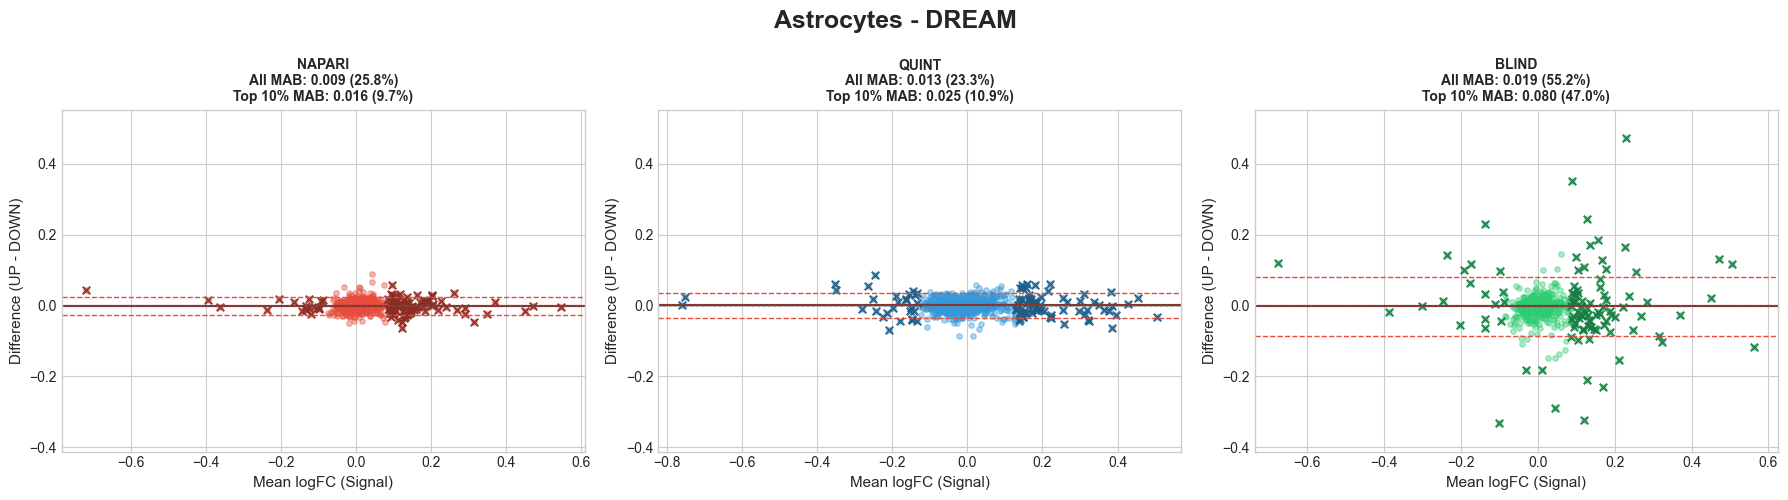


Stats for Astrocytes_cortex_hippo (DREAM):
Annotation           | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
napari               | 0.0124 (40.8%)             | 0.0255 (17.0%)
quint                | 0.0181 (33.8%)             | 0.0327 (14.9%)
blind                | 0.0192 (63.2%)             | 0.0691 (46.6%)
-------------------------------------------------------------------------------------
Saved: bland_altman_Astrocytes_cortex_hippo_dream_mab_pct.png


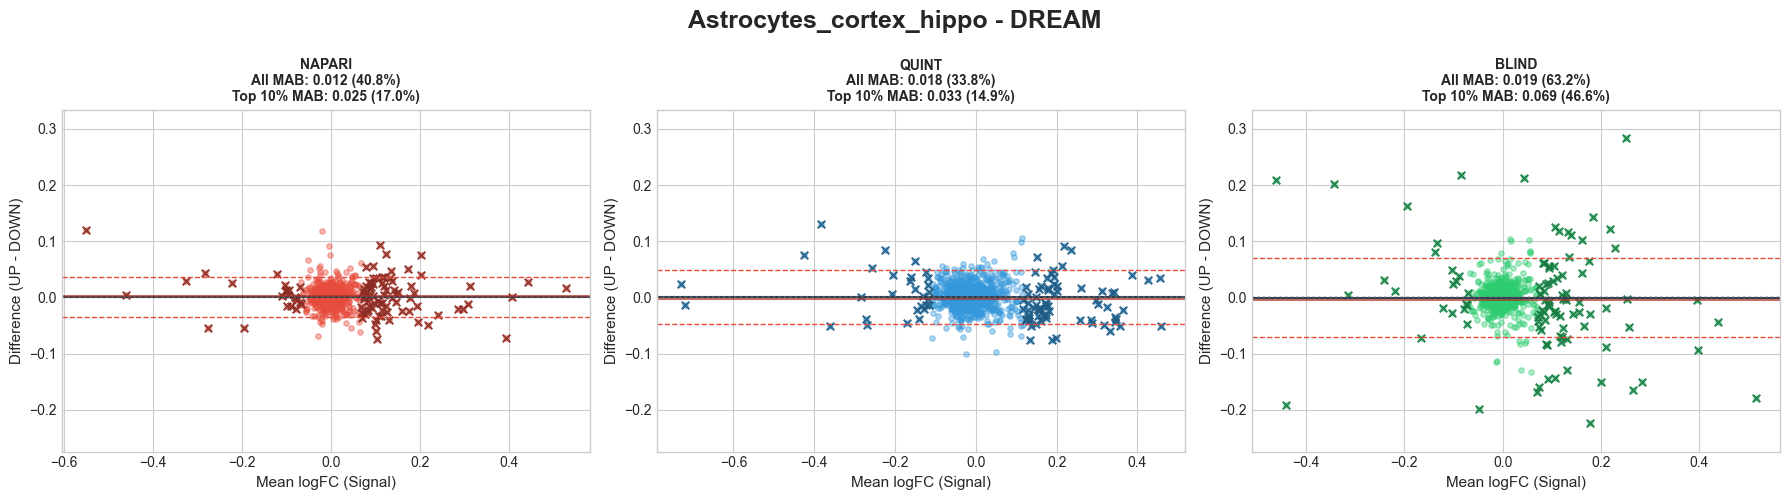


Stats for Microglia (DREAM):
Annotation           | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
napari               | 0.0315 (62.7%)             | 0.0665 (29.0%)
quint                | 0.0427 (53.7%)             | 0.0677 (21.3%)
blind                | 0.0375 (74.6%)             | 0.0919 (39.9%)
-------------------------------------------------------------------------------------
Saved: bland_altman_Microglia_dream_mab_pct.png


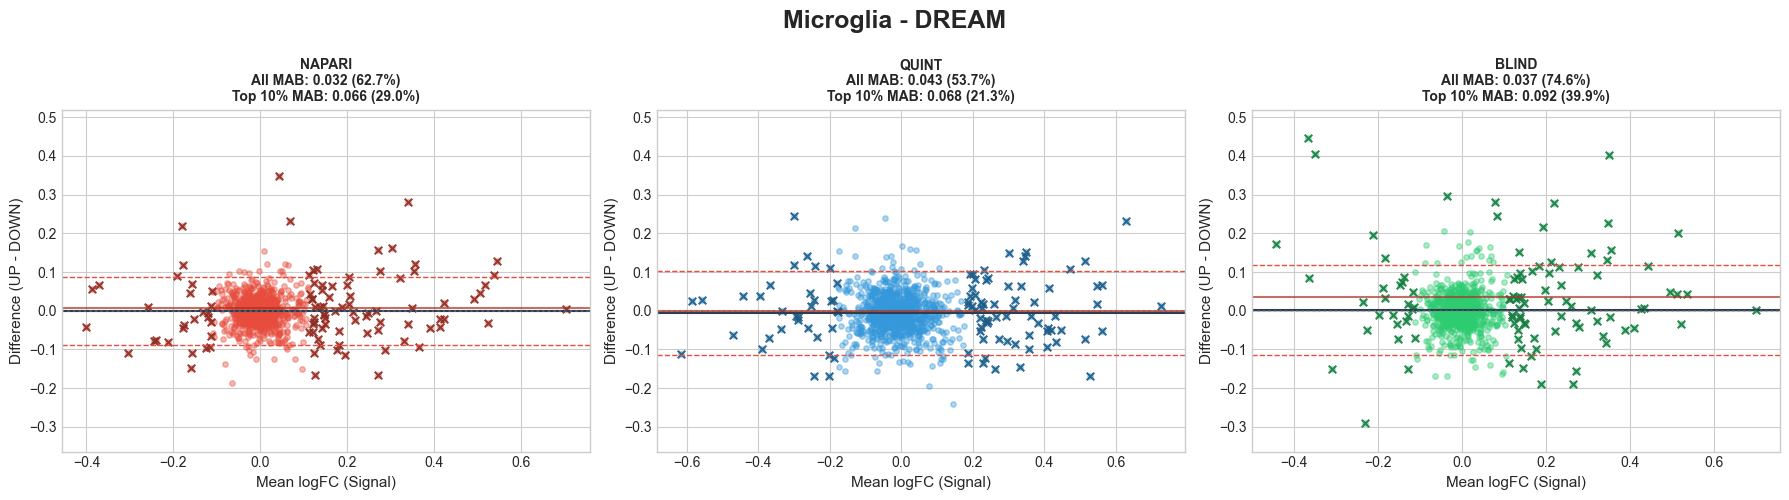


Stats for WHOLE (DREAM):
Annotation           | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
napari               | 0.0031 (9.9%)             | 0.0066 (4.3%)
quint                | 0.0044 (8.2%)             | 0.0066 (3.0%)
blind                | 0.0298 (64.2%)             | 0.1026 (44.0%)
-------------------------------------------------------------------------------------
Saved: bland_altman_WHOLE_dream_mab_pct.png


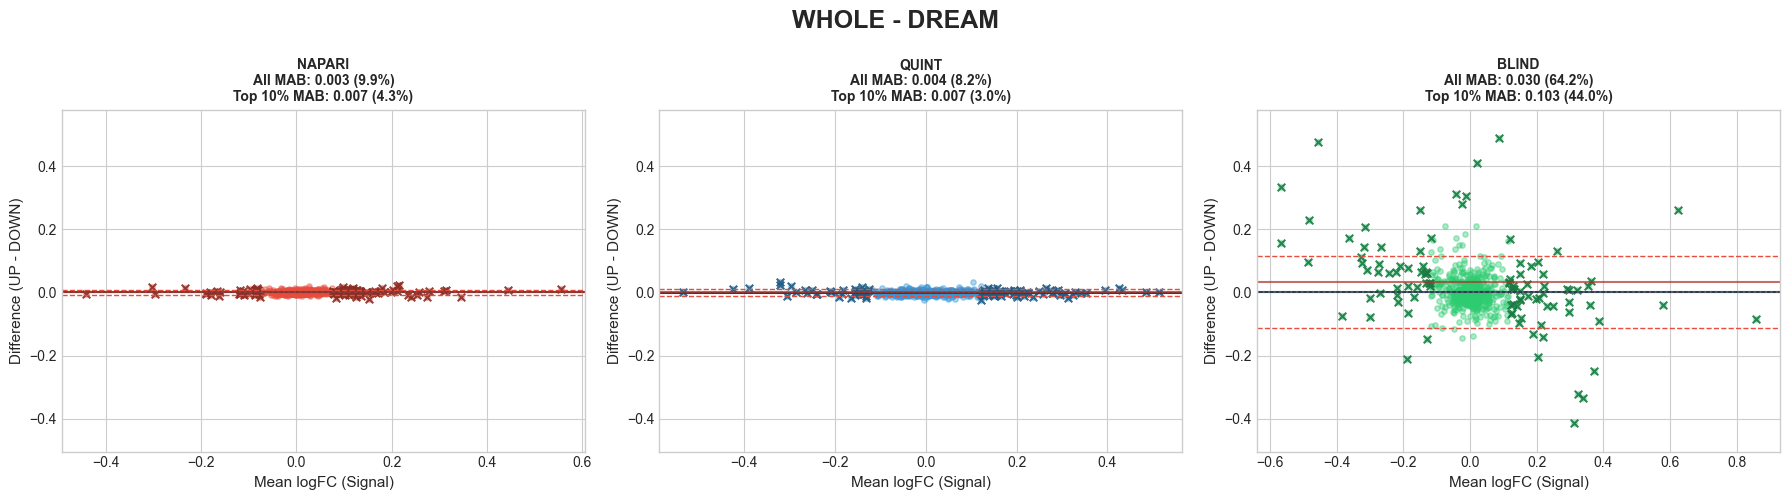

In [ ]:
# Generate Bland-Altman plots for each cell type
# For each cell type and model: side-by-side plots

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        print(f"Skipping {cell_type} - no data")
        continue
    
    for model in ['dream']:

        if model not in data_by_celltype[cell_type]:
            print(f"Skipping {cell_type}/{model} - no data")
            continue
        
        ann_data = data_by_celltype[cell_type][model]
        # Exclude fixed_napari from the plots
        available_annotations = [a for a in ANNOTATIONS if a in ann_data and a != 'fixed_napari']
        if len(available_annotations) < 2:
            print(f"Skipping {cell_type}/{model} - only {len(available_annotations)} annotation(s)")
            continue
        
        # ---------------------------------------------------------
        # PRINT STATISTICS TABLE BEFORE PLOTTING
        # ---------------------------------------------------------
        print(f"\nStats for {cell_type} ({model.upper()}):")
        print(f"{'Annotation':<20} | {'All Genes (MAB / %Signal)':<28} | {'Top 10% (MAB / %Signal)':<28}")
        print("-" * 85)

        for ann_effect in available_annotations:
            stat_df = ann_data[ann_effect].copy()
            
            # 1. Statistics Calculation (All Genes)
            ba_stat = lmm.bland_altman_stats(stat_df)
            mab_all = np.abs(ba_stat['diff']).mean()
            signal_all = np.abs(ba_stat['avg']).mean()
            pct_all = (mab_all / signal_all * 100) if signal_all != 0 else 0
            
            # 2. Statistics Calculation (Top 10%)
            t10_mask, t10_df = get_top10_genes(stat_df, 'logFC_up', 'logFC_down')
            ba_t10 = lmm.bland_altman_stats(t10_df)
            mab_t10 = np.abs(ba_t10['diff']).mean()
            signal_t10 = np.abs(ba_t10['avg']).mean()
            pct_t10 = (mab_t10 / signal_t10 * 100) if signal_t10 != 0 else 0

            print(f"{ann_effect:<20} | {mab_all:.4f} ({pct_all:.1f}%) {'':<11} | {mab_t10:.4f} ({pct_t10:.1f}%)")
        print("-" * 85)

        # ---------------------------------------------------------
        # PLOTTING
        # ---------------------------------------------------------
        y_lim = get_global_diff_range(data_by_celltype, cell_type, model)
        n_annotations = len(available_annotations)
        fig, axes = plt.subplots(1, n_annotations, figsize=(6 * n_annotations, 5))
        
        # Ensure axes is iterable even if only one plot exists
        if n_annotations == 1: axes = [axes]

        for idx, ann_effect in enumerate(available_annotations):
            ax = axes[idx]
            merged_df = ann_data[ann_effect].copy()
            color = ANNOTATION_COLORS[ann_effect]
            top_color = darken_color(color, factor=0.6)
            
            # Recalculate for plot labels
            ba = lmm.bland_altman_stats(merged_df)
            mab_all = np.abs(ba['diff']).mean()
            sig_all = np.abs(ba['avg']).mean()
            pct_all = (mab_all / sig_all * 100) if sig_all != 0 else 0
            
            top10_mask, top10_df = get_top10_genes(merged_df, 'logFC_up', 'logFC_down')
            ba_t10 = lmm.bland_altman_stats(top10_df)
            mab_t10 = np.abs(ba_t10['diff']).mean()
            sig_t10 = np.abs(ba_t10['avg']).mean()
            pct_t10 = (mab_t10 / sig_t10 * 100) if sig_t10 != 0 else 0

            # Scatter plots
            ax.scatter(ba['avg'], ba['diff'], alpha=0.4, s=15, color=color, label=f'All ({ann_effect})')
            ax.scatter(ba['avg'][top10_mask], ba['diff'][top10_mask], alpha=0.9, s=30, color=top_color, 
                       marker='x', linewidths=1.5, label=f'Top 10% (Bias: {mab_t10:.3f} / {pct_t10:.1f}%)')
            
            # Reference lines
            ax.axhline(ba['mean_diff'], color='#2C3E50', linestyle='-', linewidth=1.5)
            ax.axhline(ba['upper_loa'], color='#E74C3C', linestyle='--', linewidth=1)
            ax.axhline(ba['lower_loa'], color='#E74C3C', linestyle='--', linewidth=1)
            ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
            
            # Top 10% reference lines
            top10_dark_red = '#A93226'
            ax.axhline(ba_t10['mean_diff'], color=top10_dark_red, linestyle='-', linewidth=1.5, alpha=0.7)
            
            ax.set_xlabel('Mean logFC (Signal)')
            ax.set_ylabel('Difference (UP - DOWN)')
            
            # Updated Title
            title_str = (f'{ann_effect.upper()}\n'
                         f'All MAB: {mab_all:.3f} ({pct_all:.1f}%)\n'
                         f'Top 10% MAB: {mab_t10:.3f} ({pct_t10:.1f}%)')
            
            ax.set_title(title_str, fontsize=10, fontweight='bold')
            ax.set_ylim(y_lim)
            #ax.legend(loc='upper right', fontsize=7, frameon=True)
        
        plt.suptitle(f'{cell_type} - {model.upper()}', 
                     fontsize=18, fontweight='bold', y=0.99)
        plt.tight_layout()
        
        fig_name = f"bland_altman_{cell_type}_{model}_mab_pct.png"
        plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_name}")
        plt.show()

SEURAT (BLIND) BLAND-ALTMAN PLOTS

Stats for Astrocytes:
Method               | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
Seurat (Blind)       | 0.0834 (41.8%)             | 0.0895 (16.8%)
Saved: bland_altman_Astrocytes_seurat_blind_mab_percentage.png


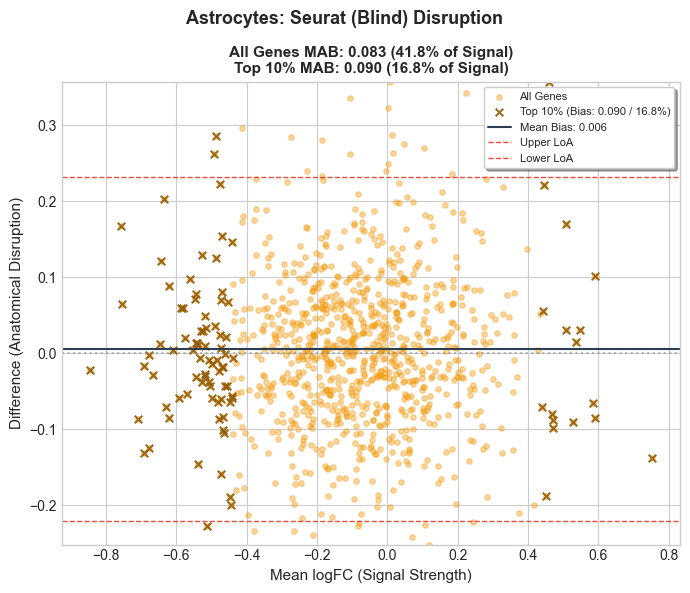

-------------------------------------------------------------------------------------

Stats for Astrocytes_cortex_hippo:
Method               | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
Seurat (Blind)       | 0.1155 (59.3%)             | 0.1478 (27.7%)
Saved: bland_altman_Astrocytes_cortex_hippo_seurat_blind_mab_percentage.png


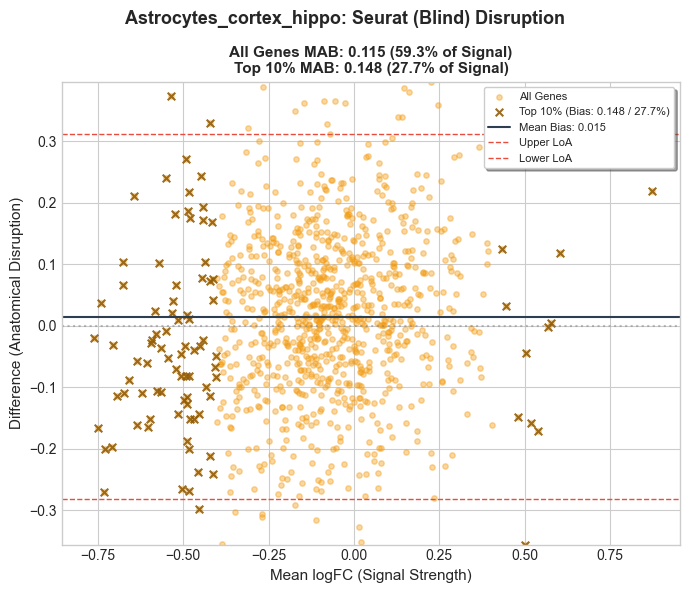

-------------------------------------------------------------------------------------

Stats for Microglia:
Method               | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
Seurat (Blind)       | 0.1614 (81.5%)             | 0.2115 (41.4%)
Saved: bland_altman_Microglia_seurat_blind_mab_percentage.png


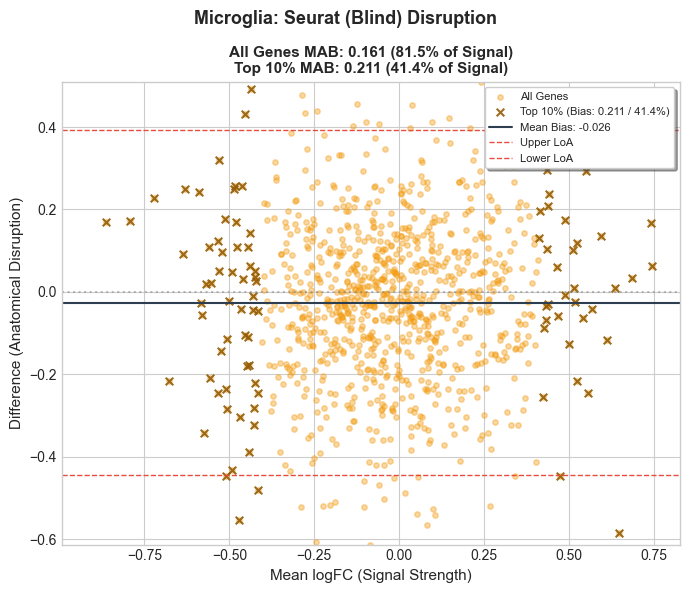

-------------------------------------------------------------------------------------

Stats for WHOLE:
Method               | All Genes (MAB / %Signal)    | Top 10% (MAB / %Signal)     
-------------------------------------------------------------------------------------
Seurat (Blind)       | 0.1072 (62.1%)             | 0.1371 (29.3%)
Saved: bland_altman_WHOLE_seurat_blind_mab_percentage.png


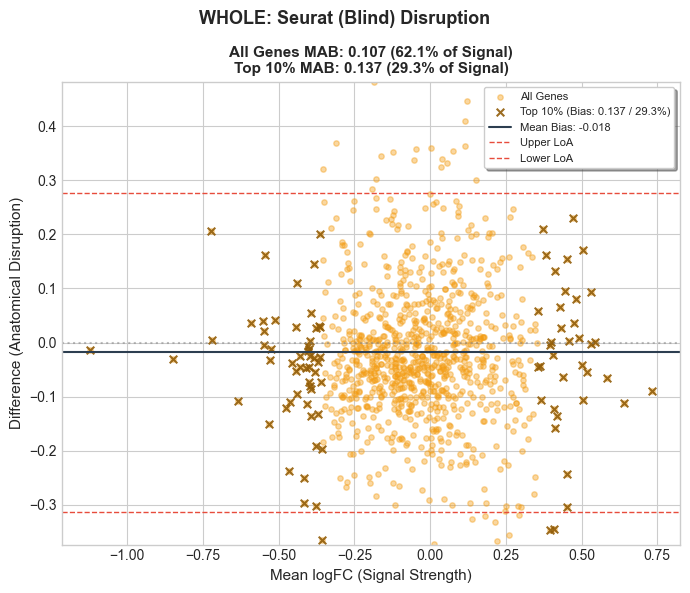

-------------------------------------------------------------------------------------


In [ ]:
# ============================================================================
# SEURAT (BLIND) BLAND-ALTMAN PLOTS (Single Files)
# ============================================================================

# Define ONLY Seurat/Blind for processing
comparison_pairs = [
    ('seurat', 'blind', 'Seurat (Blind)', MODEL_COLORS.get('seurat', '#2E86C1')),
]
def get_y_range(df):
    """
    Calculates the 1st and 99th percentiles of the Bland-Altman difference 
    to capture the middle 98% of the data.
    """
    diff = df['logFC_up'] - df['logFC_down']
    return (diff.quantile(0.01), diff.quantile(0.99))
print("=" * 85)
print("SEURAT (BLIND) BLAND-ALTMAN PLOTS")
print("=" * 85)

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        print(f"Skipping {cell_type} - no data")
        continue
    
    # Check if Seurat/Blind exists for this cell type
    available_models = []
    for model, ann, display_name, color in comparison_pairs:
        if model in data_by_celltype[cell_type] and ann in data_by_celltype[cell_type][model]:
            available_models.append((model, ann, display_name, color))
    
    if len(available_models) == 0:
        continue

    # ---------------------------------------------------------
    # PRINT STATISTICS TABLE
    # ---------------------------------------------------------
    print(f"\nStats for {cell_type}:")
    print(f"{'Method':<20} | {'All Genes (MAB / %Signal)':<28} | {'Top 10% (MAB / %Signal)':<28}")
    print("-" * 85)

    for model, ann, display_name, color in available_models:
        merged_df = data_by_celltype[cell_type][model][ann].copy()
        
        # 1. Statistics Calculation (All Genes)
        avg = (merged_df['logFC_up'] + merged_df['logFC_down']) / 2
        diff = merged_df['logFC_up'] - merged_df['logFC_down']
        
        mean_abs_bias = np.abs(diff).mean()
        mean_abs_signal = np.abs(avg).mean()
        pct_signal_all = (mean_abs_bias / mean_abs_signal * 100) if mean_abs_signal != 0 else 0
        
        # 2. Statistics Calculation (Top 10%)
        mag = (merged_df['logFC_up'].abs() + merged_df['logFC_down'].abs()) / 2
        threshold = mag.quantile(0.90)
        top10_mask = mag >= threshold
        
        top10_diff = diff[top10_mask]
        top10_avg = avg[top10_mask]
        
        mean_abs_bias_top10 = np.abs(top10_diff).mean()
        mean_abs_signal_top10 = np.abs(top10_avg).mean()
        pct_signal_top10 = (mean_abs_bias_top10 / mean_abs_signal_top10 * 100) if mean_abs_signal_top10 != 0 else 0

        # Print formatted row
        print(f"{display_name:<20} | {mean_abs_bias:.4f} ({pct_signal_all:.1f}%) {'':<11} | {mean_abs_bias_top10:.4f} ({pct_signal_top10:.1f}%)")
        
        # ---------------------------------------------------------
        # GENERATE SINGLE PLOT
        # ---------------------------------------------------------
        fig, ax = plt.subplots(figsize=(7, 6))
        
        # Reference lines
        mean_diff = diff.mean()
        std_diff = diff.std()
        upper_loa = mean_diff + 1.96 * std_diff
        lower_loa = mean_diff - 1.96 * std_diff

        # Scatter plot
        ax.scatter(avg, diff, alpha=0.4, s=15, color=color, label='All Genes')
        ax.scatter(top10_avg, top10_diff, alpha=0.9, s=30, color=darken_color(color, 0.6), 
                   marker='x', linewidths=1.5, 
                   label=f'Top 10% (Bias: {mean_abs_bias_top10:.3f} / {pct_signal_top10:.1f}%)')
        
        ax.axhline(mean_diff, color='#2C3E50', linestyle='-', linewidth=1.5, 
                   label=f'Mean Bias: {mean_diff:.3f}')
        ax.axhline(upper_loa, color='#E74C3C', linestyle='--', linewidth=1, label='Upper LoA')
        ax.axhline(lower_loa, color='#E74C3C', linestyle='--', linewidth=1, label='Lower LoA')
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Mean logFC (Signal Strength)', fontsize=11)
        ax.set_ylabel('Difference (Anatomical Disruption)', fontsize=11)
        
        # Title updated with MAB and % Signal (Removed r)
        title_str = (f'All Genes MAB: {mean_abs_bias:.3f} ({pct_signal_all:.1f}% of Signal)\n'
                     f'Top 10% MAB: {mean_abs_bias_top10:.3f} ({pct_signal_top10:.1f}% of Signal)')
        
        ax.set_title(title_str, fontsize=11, fontweight='bold')
        ax.set_ylim(get_y_range(merged_df))
        ax.legend(loc='upper right', fontsize=8, frameon=True, shadow=True)
    
        plt.suptitle(f'{cell_type}: Seurat (Blind) Disruption', fontsize=13, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        fig_name = f"bland_altman_{cell_type}_{model}_{ann}_mab_percentage.png"
        plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
        print(f"Saved: {fig_name}")
        plt.show()
    print("-" * 85)

---
## Section C.2: DESeq2 vs Wilcoxon Bland-Altman Comparison

Compare UP vs DOWN consistency between DESeq2 (pseudobulk) and Wilcoxon methods for each cell type.

DESeq2 vs WILCOXON BLAND-ALTMAN COMPARISON


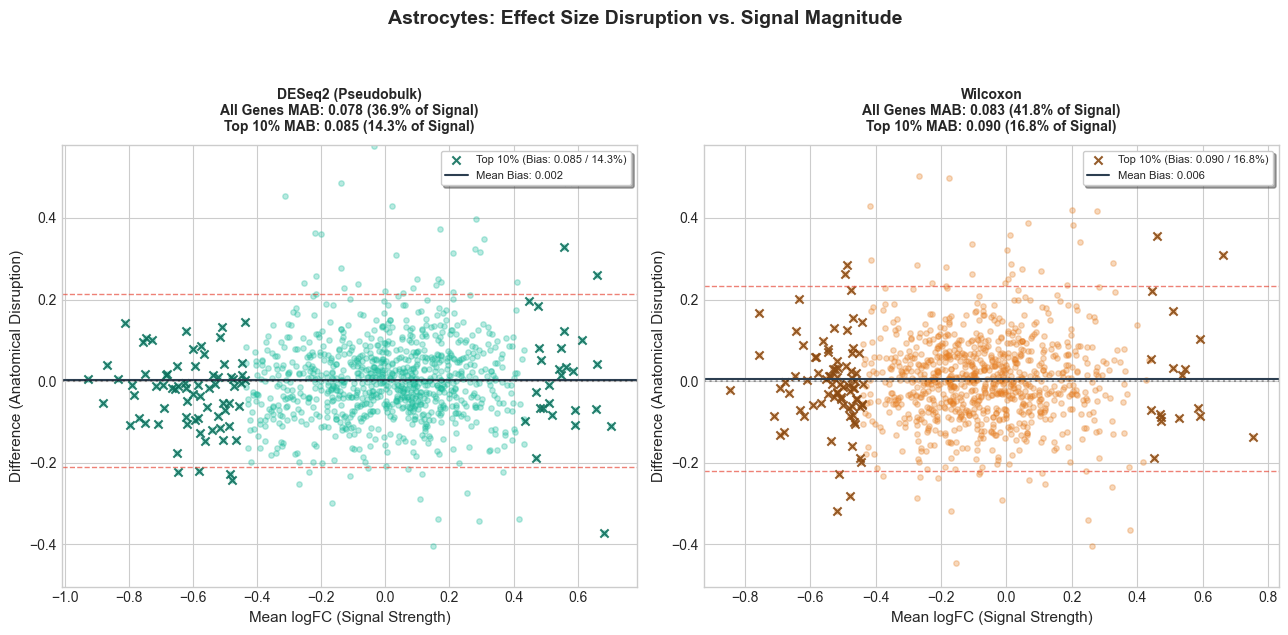

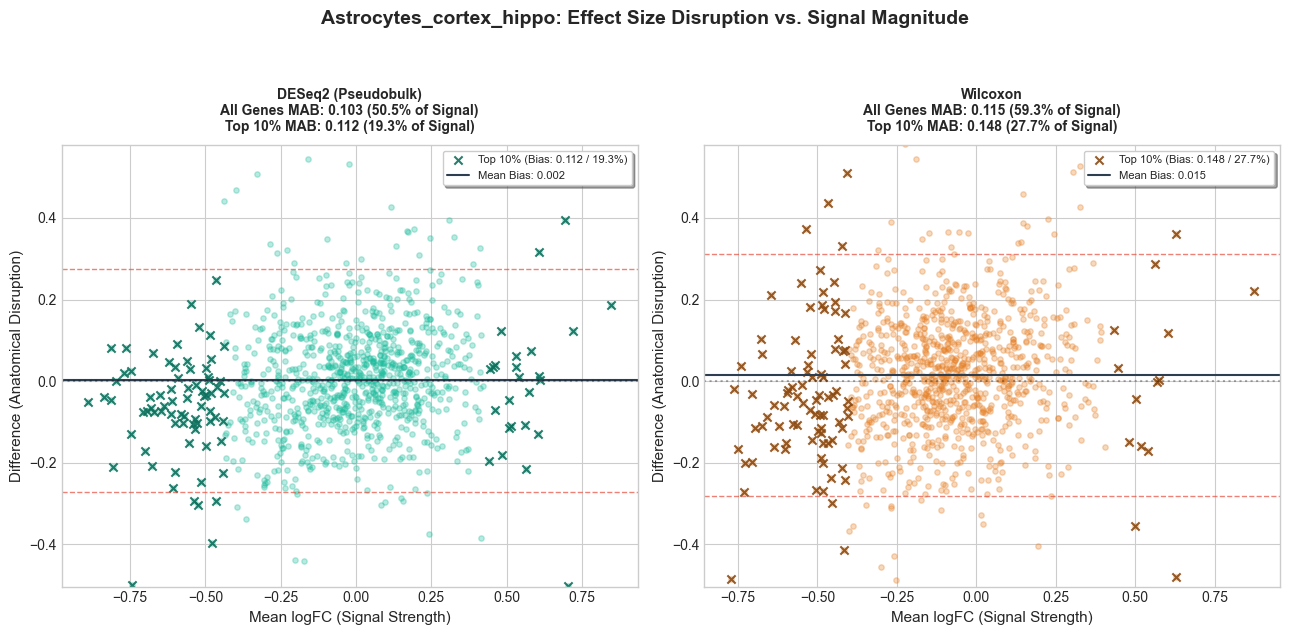

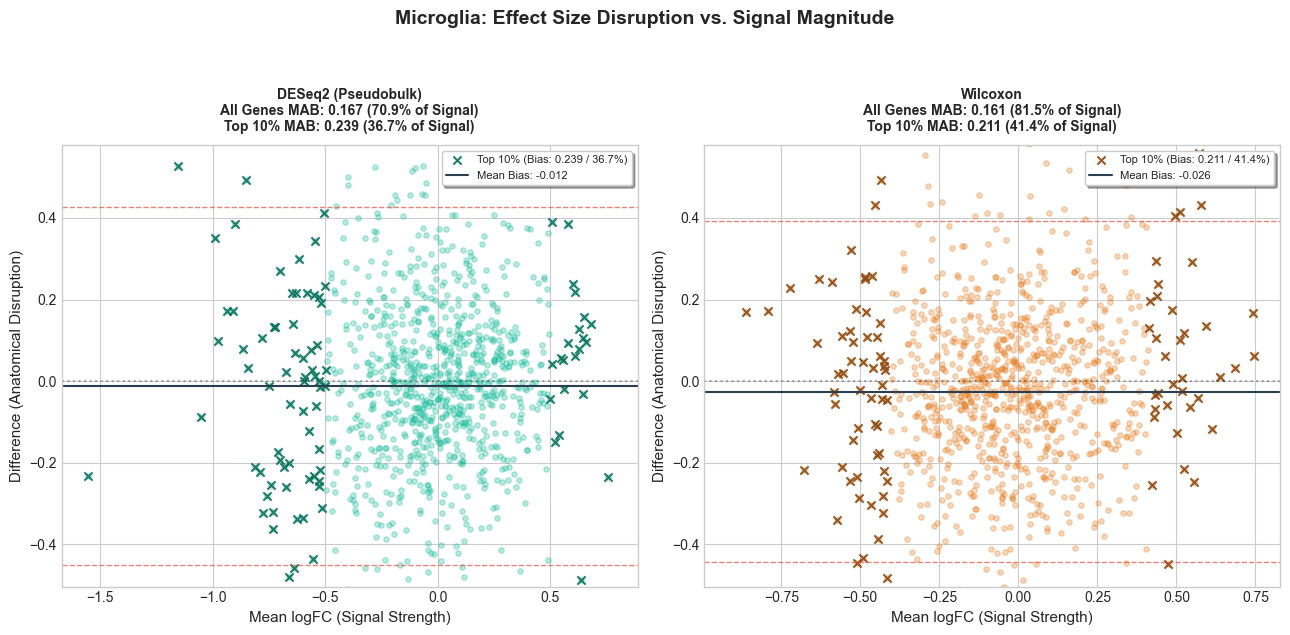

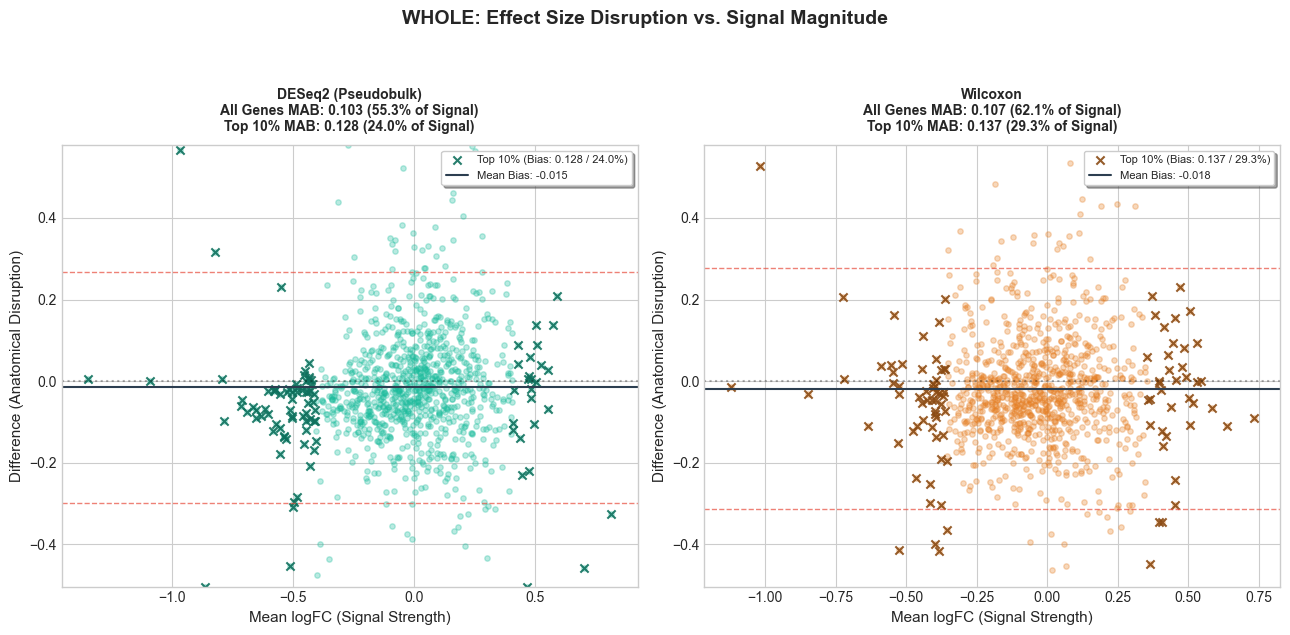


FINAL CONSOLIDATED STATISTICS SUMMARY
                                             All Genes MAB All Genes % Signal  Top 10% MAB Top 10% % Signal
Cell Type               Method                                                                             
Astrocytes              DESeq2 (Pseudobulk)         0.0783             36.92%       0.0846           14.28%
                        Wilcoxon                    0.0834             41.80%       0.0895           16.81%
Astrocytes_cortex_hippo DESeq2 (Pseudobulk)         0.1029             50.47%       0.1118           19.29%
                        Wilcoxon                    0.1155             59.28%       0.1478           27.65%
Microglia               DESeq2 (Pseudobulk)         0.1669             70.88%       0.2387           36.66%
                        Wilcoxon                    0.1614             81.52%       0.2115           41.45%
WHOLE                   DESeq2 (Pseudobulk)         0.1029             55.27%       0.1280       

In [ ]:
# Generate side-by-side Bland-Altman plots: DESeq2 vs Wilcoxon for each cell type
# DESeq2 uses 'pb' annotation, Wilcoxon uses 'blind' annotation

# Helper to get global y-axis range across both models
def get_global_diff_range_across_models(data_by_celltype, cell_type, model_ann_pairs):
    """Get global diff range across specified model/annotation pairs for a cell type."""
    diff_min, diff_max = float('inf'), float('-inf')
    
    for model, ann in model_ann_pairs:
        if cell_type not in data_by_celltype:
            continue
        if model not in data_by_celltype[cell_type]:
            continue
        if ann not in data_by_celltype[cell_type][model]:
            continue
        
        merged_df = data_by_celltype[cell_type][model][ann]
        ba = lmm.bland_altman_stats(merged_df)
        diff_min = min(diff_min, ba['diff'].min())
        diff_max = max(diff_max, ba['diff'].max())
    
    if diff_min == float('inf'):
        return (-1, 1)
    
    # Add padding
    padding = (diff_max - diff_min) * 0.1
    return (diff_min - padding, diff_max + padding)

# Define models to compare: (model_name, annotation, display_name, color)
comparison_pairs = [
    ('deseq2', 'pb', 'DESeq2 (Pseudobulk)', MODEL_COLORS['deseq2']),
    ('wilcoxon', 'blind', 'Wilcoxon', '#E67E22')  # Orange-brown for Wilcoxon
]

print("=" * 85)
print("DESeq2 vs WILCOXON BLAND-ALTMAN COMPARISON")
print("=" * 85)
available_models=[]
for model, ann, display_name, color in comparison_pairs:
    if model in data_by_celltype[cell_type] and ann in data_by_celltype[cell_type][model]:
        available_models.append((model, ann, display_name, color))
all_stats_summary = []
for cell_type in CELL_TYPES:

    fig, axes = plt.subplots(1, 2, figsize=(13, 6)) 
    
    for idx, (model, ann, display_name, color) in enumerate(available_models):
        ax = axes[idx]
        merged_df = data_by_celltype[cell_type][model][ann].copy()
        top_color = darken_color(color, factor=0.6)
        
        # 1. Calculate All Genes Stats
        ba = lmm.bland_altman_stats(merged_df)
        mean_abs_bias = np.abs(ba['diff']).mean()
        mean_abs_signal = np.abs(ba['avg']).mean()
        pct_signal_all = (mean_abs_bias / mean_abs_signal * 100) if mean_abs_signal != 0 else 0
        
        # 2. Calculate Top 10% Stats
        top10_mask, top10_df = get_top10_genes(merged_df, 'logFC_up', 'logFC_down')
        ba_top10 = lmm.bland_altman_stats(top10_df)
        mean_abs_bias_top10 = np.abs(ba_top10['diff']).mean()
        mean_abs_signal_top10 = np.abs(ba_top10['avg']).mean()
        pct_signal_top10 = (mean_abs_bias_top10 / mean_abs_signal_top10 * 100) if mean_abs_signal_top10 != 0 else 0
        all_stats_summary.append({
            'Cell Type': cell_type,
            'Method': display_name,
            'All Genes MAB': round(mean_abs_bias, 4),
            'All Genes % Signal': f"{pct_signal_all:.2f}%",
            'Top 10% MAB': round(mean_abs_bias_top10, 4),
            'Top 10% % Signal': f"{pct_signal_top10:.2f}%"
        })
        # Scatter plots
        ax.scatter(ba['avg'], ba['diff'], alpha=0.3, s=15, color=color)
        ax.scatter(ba['avg'][top10_mask], ba['diff'][top10_mask], alpha=0.9, s=35, 
                   color=top_color, marker='x', linewidths=1.5, 
                   label=f'Top 10% (Bias: {mean_abs_bias_top10:.3f} / {pct_signal_top10:.1f}%)')
        
        # Reference lines
        ax.axhline(ba['mean_diff'], color='#2C3E50', linestyle='-', linewidth=1.5, 
                   label=f'Mean Bias: {ba["mean_diff"]:.3f}')
        ax.axhline(ba['upper_loa'], color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7)
        ax.axhline(ba['lower_loa'], color='#E74C3C', linestyle='--', linewidth=1, alpha=0.7)
        ax.axhline(0, color='black', linestyle=':', alpha=0.3)
        
        # Labels and Title
        ax.set_xlabel('Mean logFC (Signal Strength)', fontsize=11)
        ax.set_ylabel('Difference (Anatomical Disruption)', fontsize=11)
        
        # Updated Title: MAB and % Signal side-by-side
        title_text = (f"{display_name}\n"
                      f"All Genes MAB: {mean_abs_bias:.3f} ({pct_signal_all:.1f}% of Signal)\n"
                      f"Top 10% MAB: {mean_abs_bias_top10:.3f} ({pct_signal_top10:.1f}% of Signal)")
        
        ax.set_title(title_text, fontsize=10, fontweight='bold', pad=10)
        ax.set_ylim(y_lim)
        ax.legend(loc='upper right', fontsize=8, frameon=True, shadow=True)
    
    plt.suptitle(f'{cell_type}: Effect Size Disruption vs. Signal Magnitude', 
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    # Save and Show
    fig_name = f"bland_altman_{cell_type}_mab_percentage.png"
    plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 95)
print("FINAL CONSOLIDATED STATISTICS SUMMARY")
print("=" * 95)
stats_df = pd.DataFrame(all_stats_summary)
# Set index to Cell Type and Method for better readability
stats_df.set_index(['Cell Type', 'Method'], inplace=True)
print(stats_df.to_string())
print("=" * 95)

In [ ]:
data_by_celltype

{'Astrocytes_cortex_hippo': {'dream': {'fixed_napari':      logFC_up   CI.L_up   CI.R_up  AveExpr_up      t_up    P.Value_up  \
   0   -0.071011 -0.094975 -0.047046   10.490572 -5.808325  6.468243e-09   
   1    0.055621  0.032786  0.078456   10.416804  4.774489  1.822667e-06   
   2   -0.024574 -0.036100 -0.013048   10.212530 -4.179266  2.944988e-05   
   3   -0.097599 -0.128637 -0.066560   10.446888 -6.163603  4.656689e-05   
   4    0.095786  0.053572  0.138001   10.336752  4.447693  6.014078e-04   
   ..        ...       ...       ...         ...       ...           ...   
   995  0.000432 -0.321009  0.321873   11.915789  0.002633  9.979367e-01   
   996 -0.000172 -0.133720  0.133376   10.583902 -0.002523  9.980231e-01   
   997 -0.000021 -0.021058  0.021016   10.232851 -0.001955  9.984679e-01   
   998 -0.000683 -0.716110  0.714744   12.314641 -0.001872  9.985329e-01   
   999 -0.000353 -0.464770  0.464063   13.161968 -0.001493  9.988298e-01   
   
        adj.P.Val_up       B_up 

DESeq2 vs WILCOXON BLAND-ALTMAN COMPARISON (-log10 p-value)
Saved: LMM_analysis_data\figures\bland_altman_Astrocytes_deseq2_vs_wilcoxon_neglog10p.png


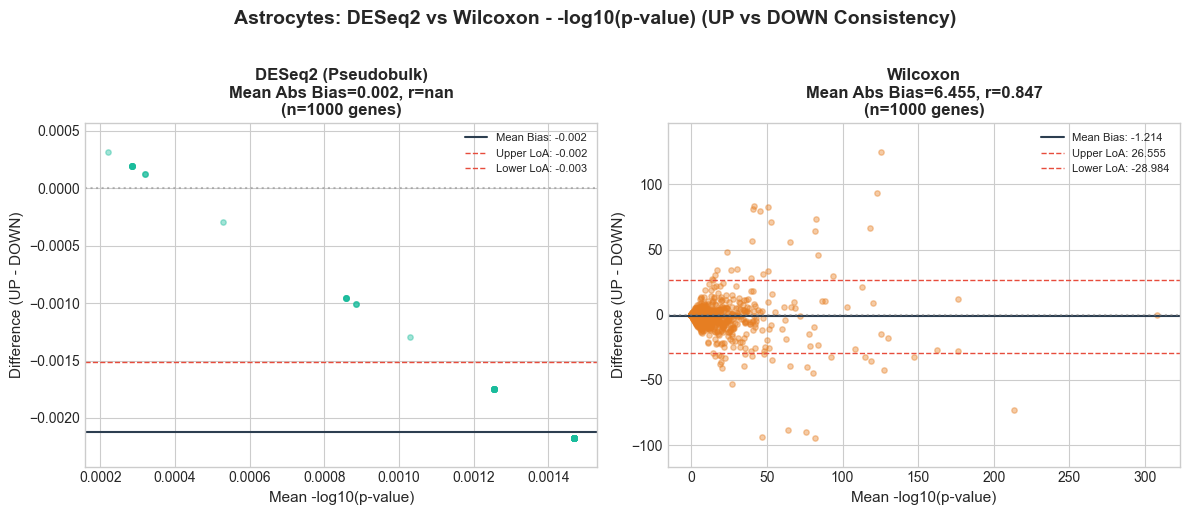

Saved: LMM_analysis_data\figures\bland_altman_Astrocytes_cortex_hippo_deseq2_vs_wilcoxon_neglog10p.png


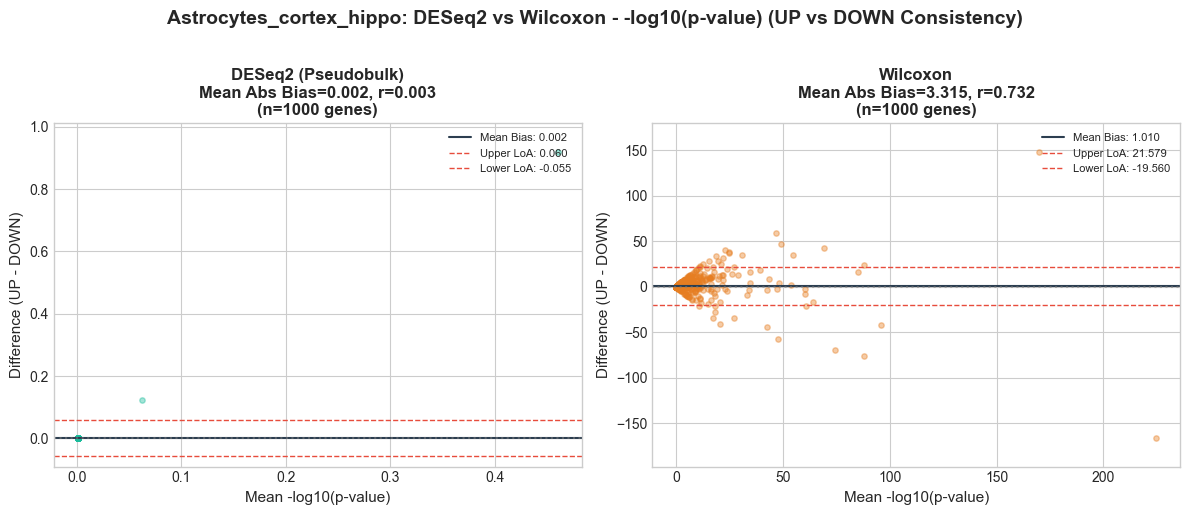

Saved: LMM_analysis_data\figures\bland_altman_Microglia_deseq2_vs_wilcoxon_neglog10p.png


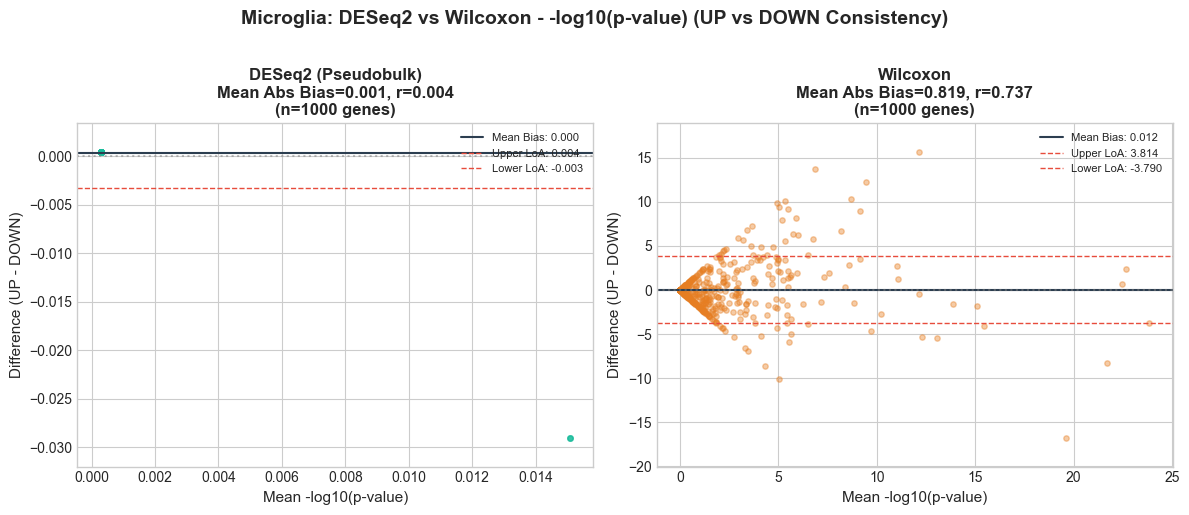

Saved: LMM_analysis_data\figures\bland_altman_WHOLE_deseq2_vs_wilcoxon_neglog10p.png


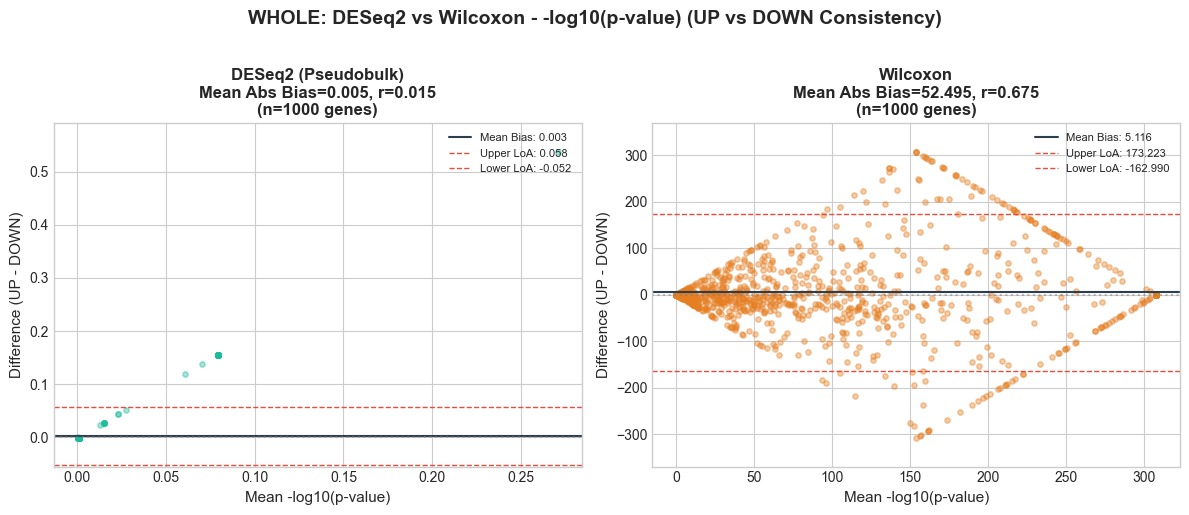

In [ ]:
# ============================================================================
# PART 2: -log10(pvalue) Bland-Altman Plots for DESeq2 vs Wilcoxon
# ============================================================================

# Helper to calculate -log10(pvalue) columns
def add_neglog10_pval(df):
    """Add -log10(pvalue) columns to dataframe."""
    df = df.copy()
    # Handle zeros by replacing with smallest non-zero value
    for suffix in ['_up', '_down']:
        pval_col = f'adj.P.Val{suffix}'
        if pval_col in df.columns:
            pvals = df[pval_col].replace(0, np.finfo(float).tiny)
            df[f'neglog10p{suffix}'] = -np.log10(pvals)
    return df

# Helper to get global y-axis range for -log10(pvalue) across models
def get_neglog10_diff_range_across_models(data_by_celltype, cell_type, model_ann_pairs):
    """Get global diff range for -log10(pvalue) across specified model/annotation pairs."""
    diff_min, diff_max = float('inf'), float('-inf')
    
    for model, ann in model_ann_pairs:
        if cell_type not in data_by_celltype:
            continue
        if model not in data_by_celltype[cell_type]:
            continue
        if ann not in data_by_celltype[cell_type][model]:
            continue
        
        merged_df = add_neglog10_pval(data_by_celltype[cell_type][model][ann])
        if 'neglog10p_up' in merged_df.columns and 'neglog10p_down' in merged_df.columns:
            diff = merged_df['neglog10p_up'] - merged_df['neglog10p_down']
            diff_min = min(diff_min, diff.min())
            diff_max = max(diff_max, diff.max())
    
    if diff_min == float('inf'):
        return (-1, 1)
    
    # Add padding
    padding = (diff_max - diff_min) * 0.1
    return (diff_min - padding, diff_max + padding)

print("=" * 70)
print("DESeq2 vs WILCOXON BLAND-ALTMAN COMPARISON (-log10 p-value)")
print("=" * 70)

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        print(f"Skipping {cell_type} - no data")
        continue
    
    # Check if both models have data for this cell type
    available_models = []
    for model, ann, display_name, color in comparison_pairs:
        if model in data_by_celltype[cell_type] and ann in data_by_celltype[cell_type][model]:
            available_models.append((model, ann, display_name, color))
    
    if len(available_models) < 2:
        print(f"Skipping {cell_type} - need both DESeq2 and Wilcoxon data")
        continue
    
    # Create figure with side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, (model, ann, display_name, color) in enumerate(available_models):
        ax = axes[idx]
        merged_df = add_neglog10_pval(data_by_celltype[cell_type][model][ann])
        
        # Calculate Bland-Altman stats for -log10(pvalue)
        avg = (merged_df['neglog10p_up'] + merged_df['neglog10p_down']) / 2
        diff = merged_df['neglog10p_up'] - merged_df['neglog10p_down']
        mean_diff = diff.mean()
        std_diff = diff.std()
        upper_loa = mean_diff + 1.96 * std_diff
        lower_loa = mean_diff - 1.96 * std_diff
        
        # Get independent y-axis range for THIS model only
        y_min = diff.min()
        y_max = diff.max()
        y_padding = (y_max - y_min) * 0.1
        y_lim = (y_min - y_padding, y_max + y_padding)
        
        # Calculate mean absolute bias
        mean_abs_bias = np.abs(diff).mean()
        
        # Correlation
        corr_r, _ = pearsonr(merged_df['neglog10p_up'], merged_df['neglog10p_down'])
        
        # Scatter plot
        ax.scatter(avg, diff, alpha=0.4, s=15, color=color)
        
        # Reference lines
        ax.axhline(mean_diff, color='#2C3E50', linestyle='-', linewidth=1.5, 
                   label=f'Mean Bias: {mean_diff:.3f}')
        ax.axhline(upper_loa, color='#E74C3C', linestyle='--', linewidth=1,
                   label=f'Upper LoA: {upper_loa:.3f}')
        ax.axhline(lower_loa, color='#E74C3C', linestyle='--', linewidth=1,
                   label=f'Lower LoA: {lower_loa:.3f}')
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Mean -log10(p-value)', fontsize=11)
        ax.set_ylabel('Difference (UP - DOWN)', fontsize=11)
        ax.set_title(f'{display_name}\nMean Abs Bias={mean_abs_bias:.3f}, r={corr_r:.3f}\n(n={len(merged_df)} genes)', 
                    fontsize=12, fontweight='bold')
        ax.set_ylim(y_lim)
        ax.legend(loc='upper right', fontsize=8)
    
    plt.suptitle(f'{cell_type}: DESeq2 vs Wilcoxon - -log10(p-value) (UP vs DOWN Consistency)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_name = f"bland_altman_{cell_type}_deseq2_vs_wilcoxon_neglog10p.png"
    plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / fig_name}")
    plt.show()

---
## Section C.3: DESeq2 vs Wilcoxon Scatter Plots

Direct comparison of UP vs DOWN values for DESeq2 and Wilcoxon:
1. **logFC Scatter Plots**: logFC_up vs logFC_down
2. **-log10(p-value) Scatter Plots**: neglog10p_up vs neglog10p_down


DESeq2 vs WILCOXON SCATTER PLOTS (-log10 p-value)
Saved: LMM_analysis_data\figures\scatter_Astrocytes_deseq2_vs_wilcoxon_neglog10p.png


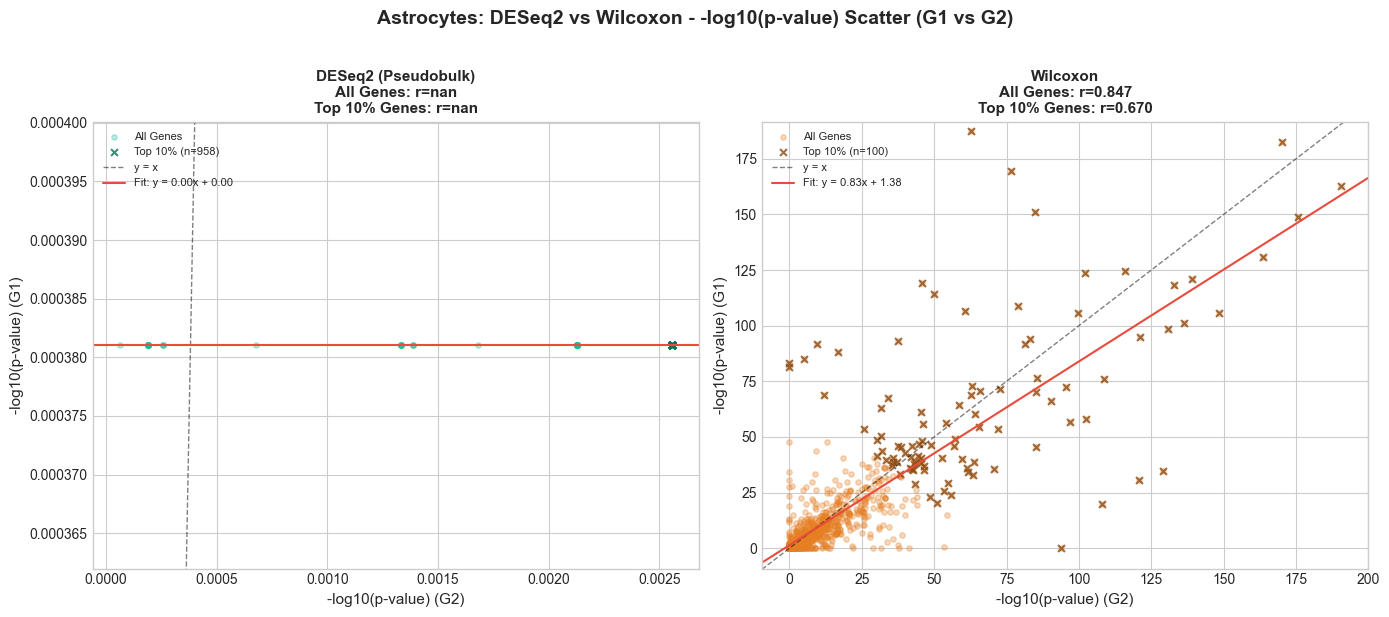

Saved: LMM_analysis_data\figures\scatter_Astrocytes_cortex_hippo_deseq2_vs_wilcoxon_neglog10p.png


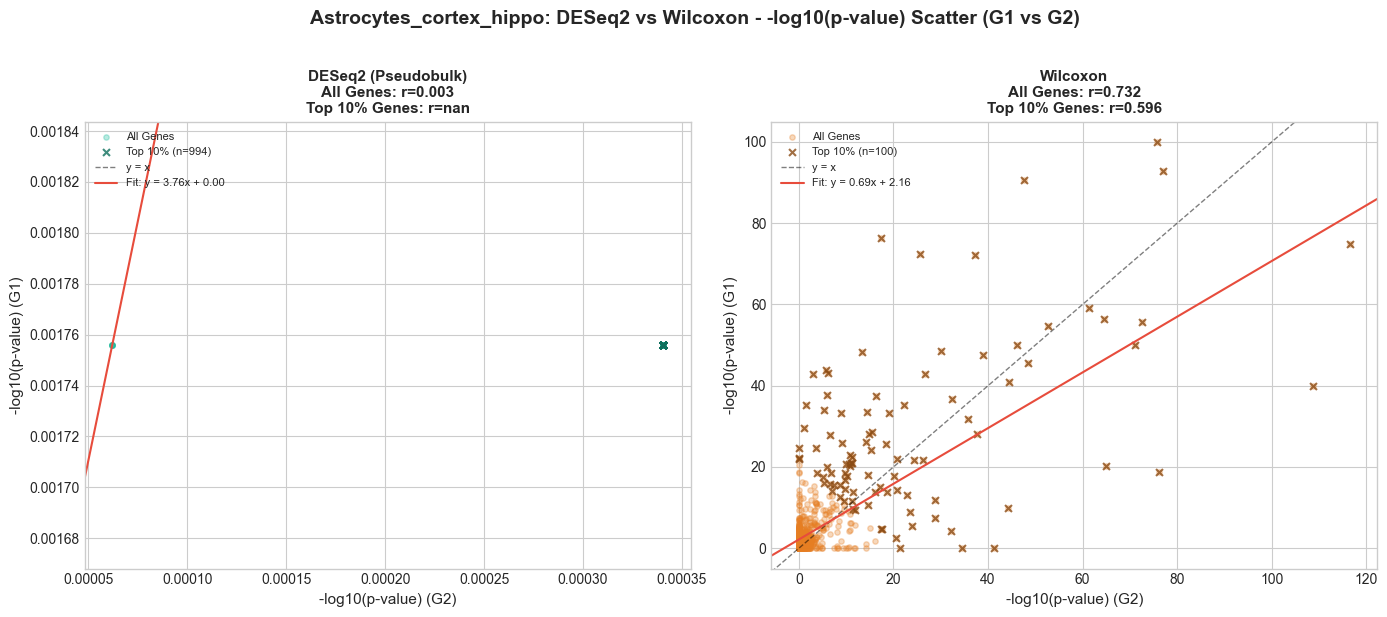

Saved: LMM_analysis_data\figures\scatter_Microglia_deseq2_vs_wilcoxon_neglog10p.png


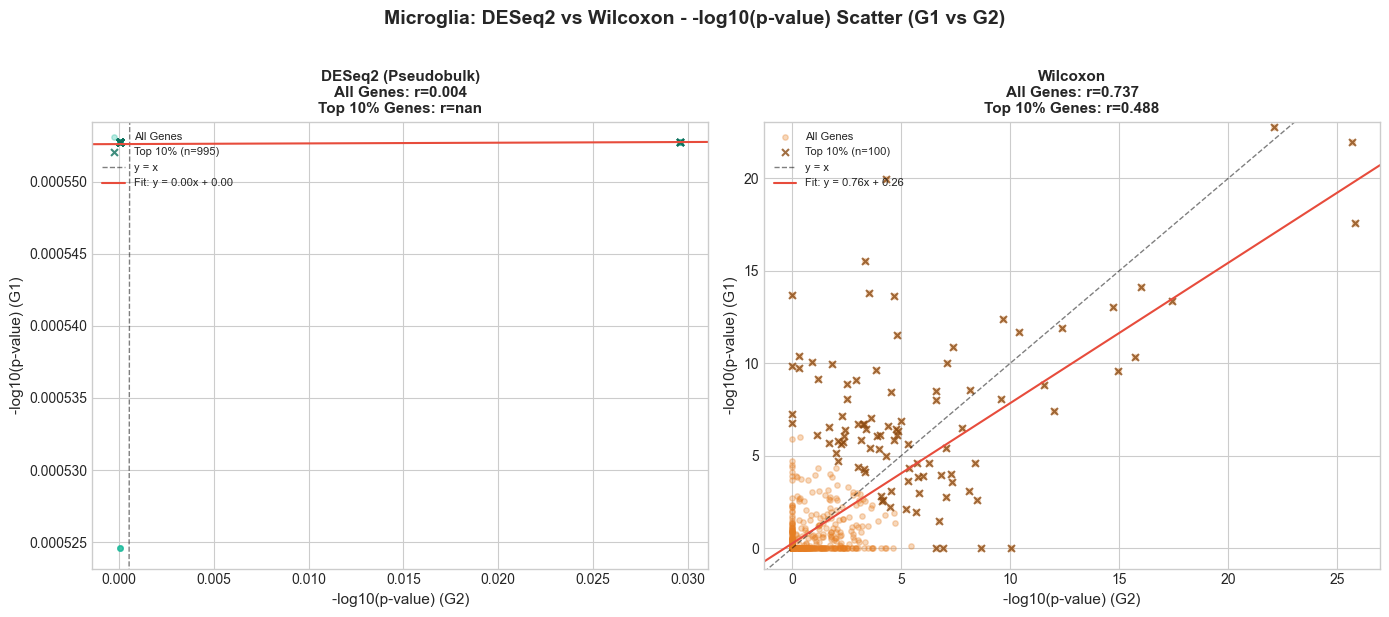

Saved: LMM_analysis_data\figures\scatter_WHOLE_deseq2_vs_wilcoxon_neglog10p.png


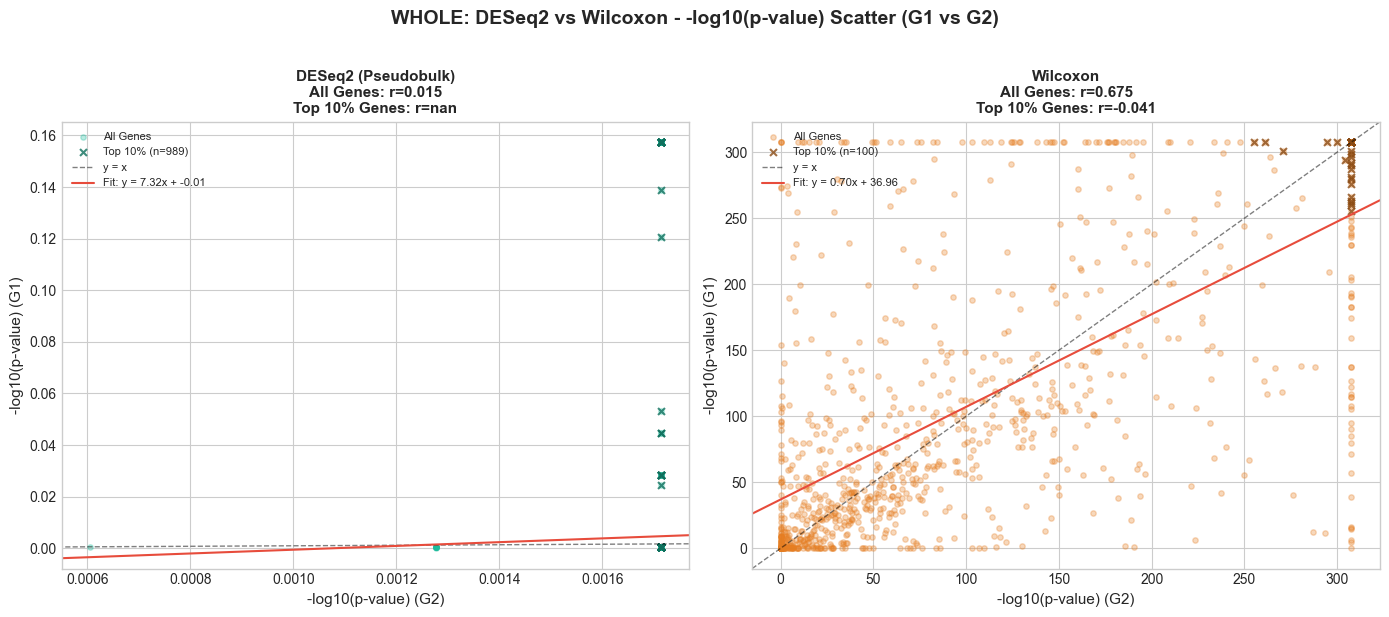

In [ ]:
# ============================================================================
# DESeq2 vs WILCOXON SCATTER PLOTS (-log10 p-value)
# ============================================================================
print("\n" + "=" * 70)
print("DESeq2 vs WILCOXON SCATTER PLOTS (-log10 p-value)")
print("=" * 70)

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        print(f"Skipping {cell_type} - no data")
        continue
    
    # Check if both models have data for this cell type
    available_models = []
    for model, ann, display_name, color in comparison_pairs:
        if model in data_by_celltype[cell_type] and ann in data_by_celltype[cell_type][model]:
            available_models.append((model, ann, display_name, color))
    
    if len(available_models) < 2:
        print(f"Skipping {cell_type} - need both DESeq2 and Wilcoxon data")
        continue
    
    # Create figure with side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for idx, (model, ann, display_name, color) in enumerate(available_models):
        ax = axes[idx]
        merged_df = add_neglog10_pval(data_by_celltype[cell_type][model][ann].copy())
        
        x_col = 'neglog10p_down'
        y_col = 'neglog10p_up'
        
        # --- AXIS RANGE LOGIC (3rd Largest to avoid outliers) ---
        x_min = merged_df[x_col].min()
        y_min = merged_df[y_col].min()
        
        if len(merged_df) >= 3:
            x_max = merged_df[x_col].nlargest(3).iloc[-1]
            y_max = merged_df[y_col].nlargest(3).iloc[-1]
        else:
            x_max = merged_df[x_col].max()
            y_max = merged_df[y_col].max()
            
        x_padding = (x_max - x_min) * 0.05
        y_padding = (y_max - y_min) * 0.05
        x_range = (x_min - x_padding, x_max + x_padding)
        y_range = (y_min - y_padding, y_max + y_padding)
        
        # 1. STATISTICS (ALL GENES)
        corr_r_all, _ = pearsonr(merged_df[y_col], merged_df[x_col])
        abs_bias_all = np.abs(merged_df[y_col] - merged_df[x_col]).mean()

        top10_mask, top10_df = get_top10_genes(merged_df, y_col, x_col)

        if len(top10_df) > 1:
            corr_r_top10, _ = pearsonr(top10_df[y_col], top10_df[x_col])
            abs_bias_top10 = np.abs(top10_df[y_col] - top10_df[x_col]).mean()
        else:
            corr_r_top10, abs_bias_top10 = np.nan, np.nan
        
        # Plotting Colors
        top_color = darken_color(color, factor=0.6)
        
        # Scatter plot (All Genes - Lighter)
        ax.scatter(merged_df[x_col], merged_df[y_col], alpha=0.3, s=15, 
                   color=color, label='All Genes')
        
        # Scatter plot (Top 10% Genes - Darker with 'x')
        ax.scatter(top10_df[x_col], top10_df[y_col], alpha=0.8, s=25, 
                   color=top_color, marker='x', label=f'Top 10% (n={len(top10_df)})')
        
        # Identity line
        id_range = (min(x_range[0], y_range[0]), max(x_range[1], y_range[1]))
        ax.plot(id_range, id_range, 'k--', alpha=0.5, linewidth=1, label='y = x')
        
        # Regression line
        if len(merged_df) > 1:
            slope, intercept = np.polyfit(merged_df[x_col], merged_df[y_col], 1)
            x_line = np.array(x_range)
            ax.plot(x_line, slope * x_line + intercept, color='#E74C3C', linewidth=1.5,
                   label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')
        
        ax.set_xlabel('-log10(p-value) (G2)', fontsize=11)
        ax.set_ylabel('-log10(p-value) (G1)', fontsize=11)
        
        # Dynamic Title with Dual Stats
        title_str = (f'{display_name}\n'
                     f'All Genes: r={corr_r_all:.3f}\n'
                     f'Top 10% Genes: r={corr_r_top10:.3f}')
        
        ax.set_title(title_str, fontsize=11, fontweight='bold')
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        ax.legend(loc='upper left', fontsize=8)
    
    plt.suptitle(f'{cell_type}: DESeq2 vs Wilcoxon - -log10(p-value) Scatter (G1 vs G2)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_name = f"scatter_{cell_type}_deseq2_vs_wilcoxon_neglog10p.png"
    plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / fig_name}")
    plt.show()

---
## Section C.4: Summary Statistics - logFC Differences (UP vs DOWN)

In [ ]:
# Summary statistics for logFC differences between UP and DOWN groups
# Comparing DESeq2 vs Wilcoxon across cell types with 95% Confidence Intervals

from scipy.stats import t as t_dist

summary_rows = []

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        continue
    
    for model, ann, display_name, _ in comparison_pairs:
        if model not in data_by_celltype[cell_type]:
            continue
        if ann not in data_by_celltype[cell_type][model]:
            continue
        
        merged_df = data_by_celltype[cell_type][model][ann]
        diff = merged_df['logFC_up'] - merged_df['logFC_down']
        
        # Calculate 95% CI for mean difference
        n = len(diff)
        mean_diff = diff.mean()
        std_diff = diff.std()
        se = std_diff / np.sqrt(n)
        t_crit = t_dist.ppf(0.975, df=n-1)  # 95% CI
        ci_lower = mean_diff - t_crit * se
        ci_upper = mean_diff + t_crit * se
        
        # Calculate correlation
        corr_r, corr_p = pearsonr(merged_df['logFC_up'], merged_df['logFC_down'])
        
        # Calculate mean absolute bias
        mean_abs_bias = np.abs(diff).mean()
        
        summary_rows.append({
            'Cell Type': cell_type,
            'Model': display_name,
            'N Genes': n,
            'Mean Bias': mean_diff,
            'Mean Abs Bias': mean_abs_bias,
            '95% CI Lower': ci_lower,
            '95% CI Upper': ci_upper,
            'Std Diff': std_diff,
            'Pearson r': corr_r
        })

summary_df = pd.DataFrame(summary_rows)

print("=" * 90)
print("SUMMARY: logFC Differences (UP - DOWN) with 95% Confidence Intervals")
print("=" * 90)
print(summary_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
summary_df.to_csv(OUTPUT_PATH / "tables" / "logFC_summary_deseq2_vs_wilcoxon.csv", index=False)
print(f"\nSaved: {OUTPUT_PATH / 'tables' / 'logFC_summary_deseq2_vs_wilcoxon.csv'}")

SUMMARY: logFC Differences (UP - DOWN) with 95% Confidence Intervals
              Cell Type               Model  N Genes  Mean Bias  Mean Abs Bias  95% CI Lower  95% CI Upper  Std Diff  Pearson r
             Astrocytes DESeq2 (Pseudobulk)     1000     0.0023         0.0783       -0.0044        0.0090    0.1081     0.9244
             Astrocytes            Wilcoxon     1000     0.0059         0.0834       -0.0013        0.0131    0.1155     0.8854
Astrocytes_cortex_hippo DESeq2 (Pseudobulk)     1000     0.0023         0.1029       -0.0064        0.0109    0.1393     0.8712
Astrocytes_cortex_hippo            Wilcoxon     1000     0.0146         0.1155        0.0052        0.0240    0.1514     0.8052
              Microglia DESeq2 (Pseudobulk)     1000    -0.0124         0.1669       -0.0263        0.0016    0.2243     0.7582
              Microglia            Wilcoxon     1000    -0.0258         0.1614       -0.0390       -0.0125    0.2135     0.6863
                  WHOLE DESeq2 (Pse

In [ ]:
# Helper functions for scatter plot axis ranges
def get_global_axis_range(data_by_celltype, cell_type, model, col_up, col_down):
    """Get global axis range across all annotations for consistent scatter plots."""
    val_min, val_max = float('inf'), float('-inf')
    
    if cell_type not in data_by_celltype:
        return (-1, 1)
    if model not in data_by_celltype[cell_type]:
        return (-1, 1)
    
    for ann, merged_df in data_by_celltype[cell_type][model].items():
        if col_up in merged_df.columns and col_down in merged_df.columns:
            val_min = min(val_min, merged_df[col_up].min(), merged_df[col_down].min())
            val_max = max(val_max, merged_df[col_up].max(), merged_df[col_down].max())
    
    # Add padding
    padding = (val_max - val_min) * 0.05
    return (val_min - padding, val_max + padding)

print("Helper functions for scatter plots defined")

Helper functions for scatter plots defined



LR MODELS SCATTER PLOTS (-log10 p-value)
Saved: LMM_analysis_data\figures\scatter_Astrocytes_lmm_models_neglog10p.png


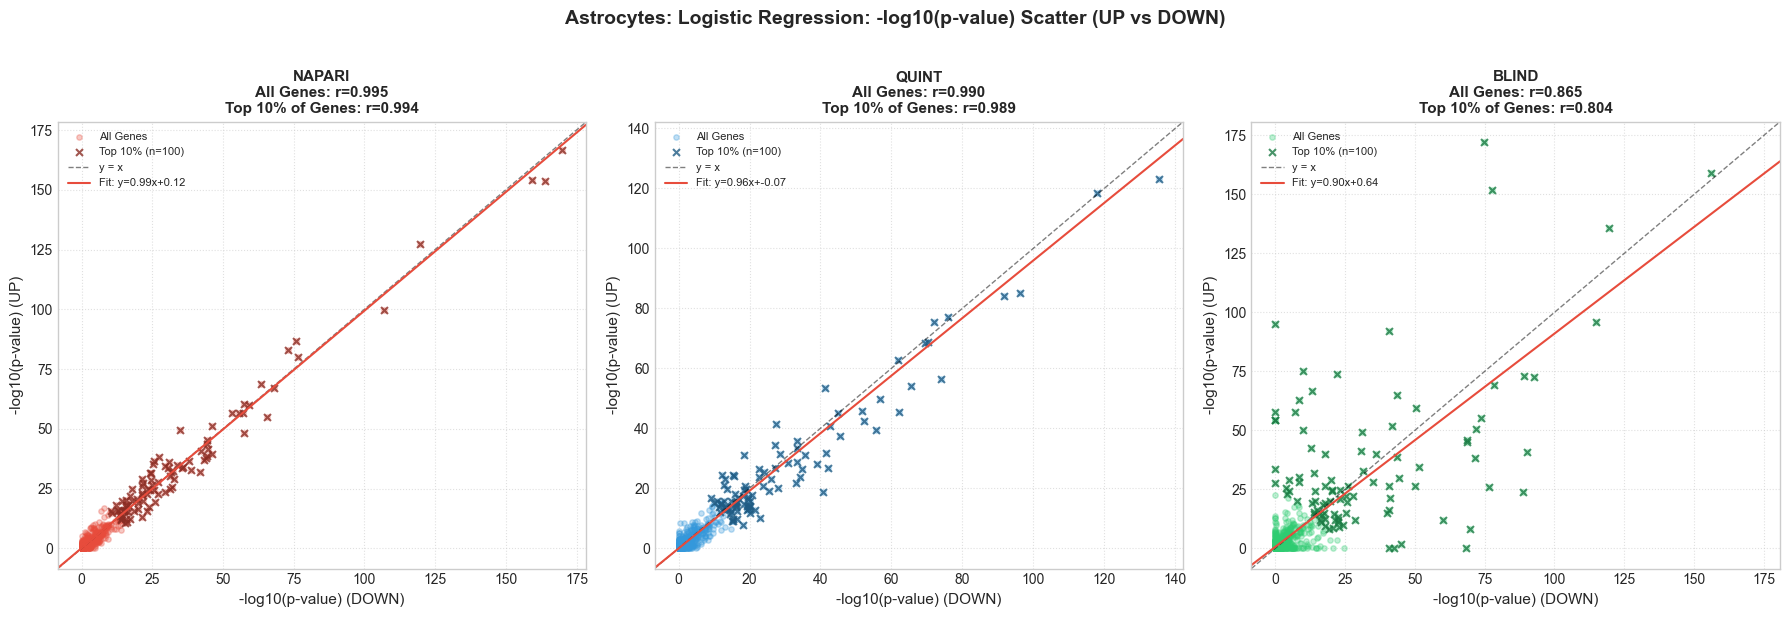

Saved: LMM_analysis_data\figures\scatter_Astrocytes_cortex_hippo_lmm_models_neglog10p.png


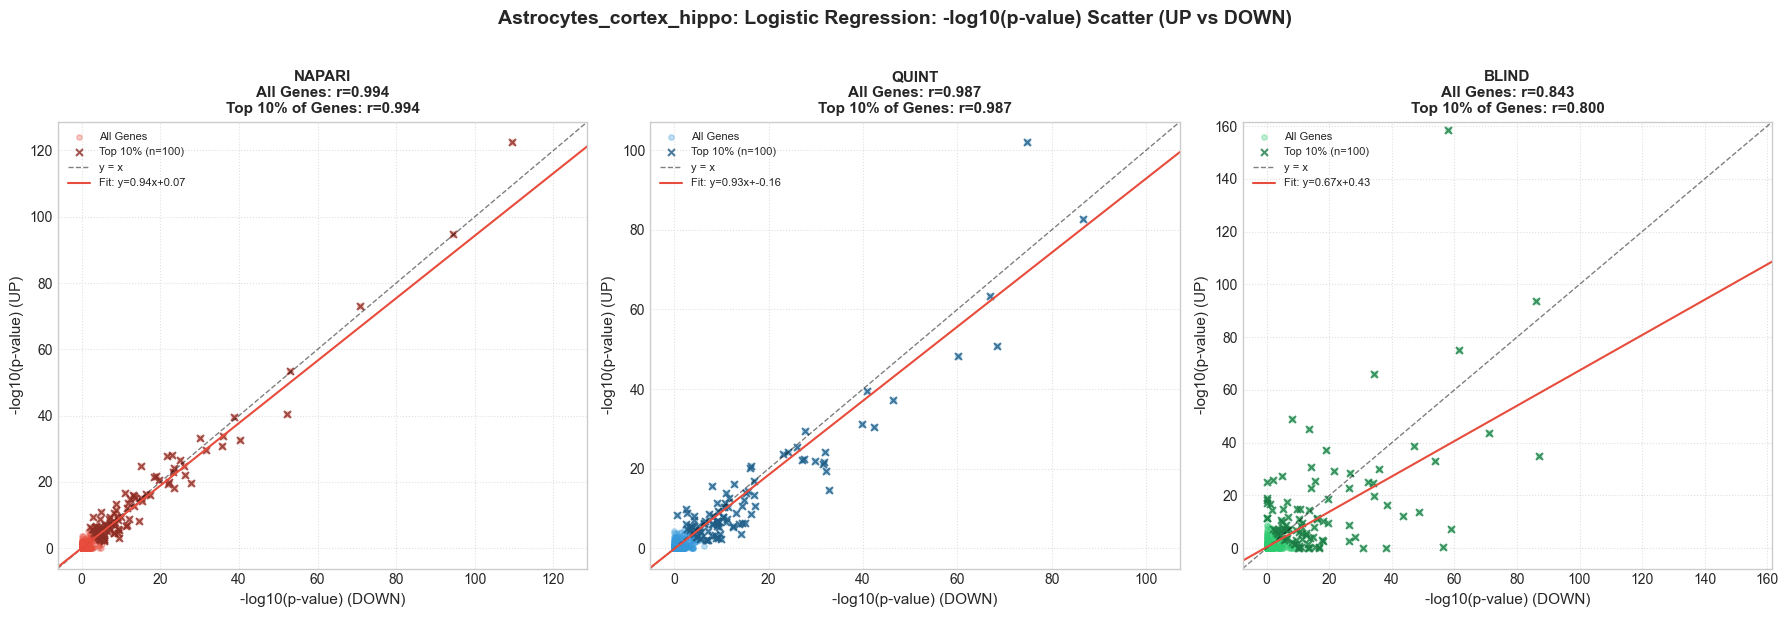

Saved: LMM_analysis_data\figures\scatter_Microglia_lmm_models_neglog10p.png


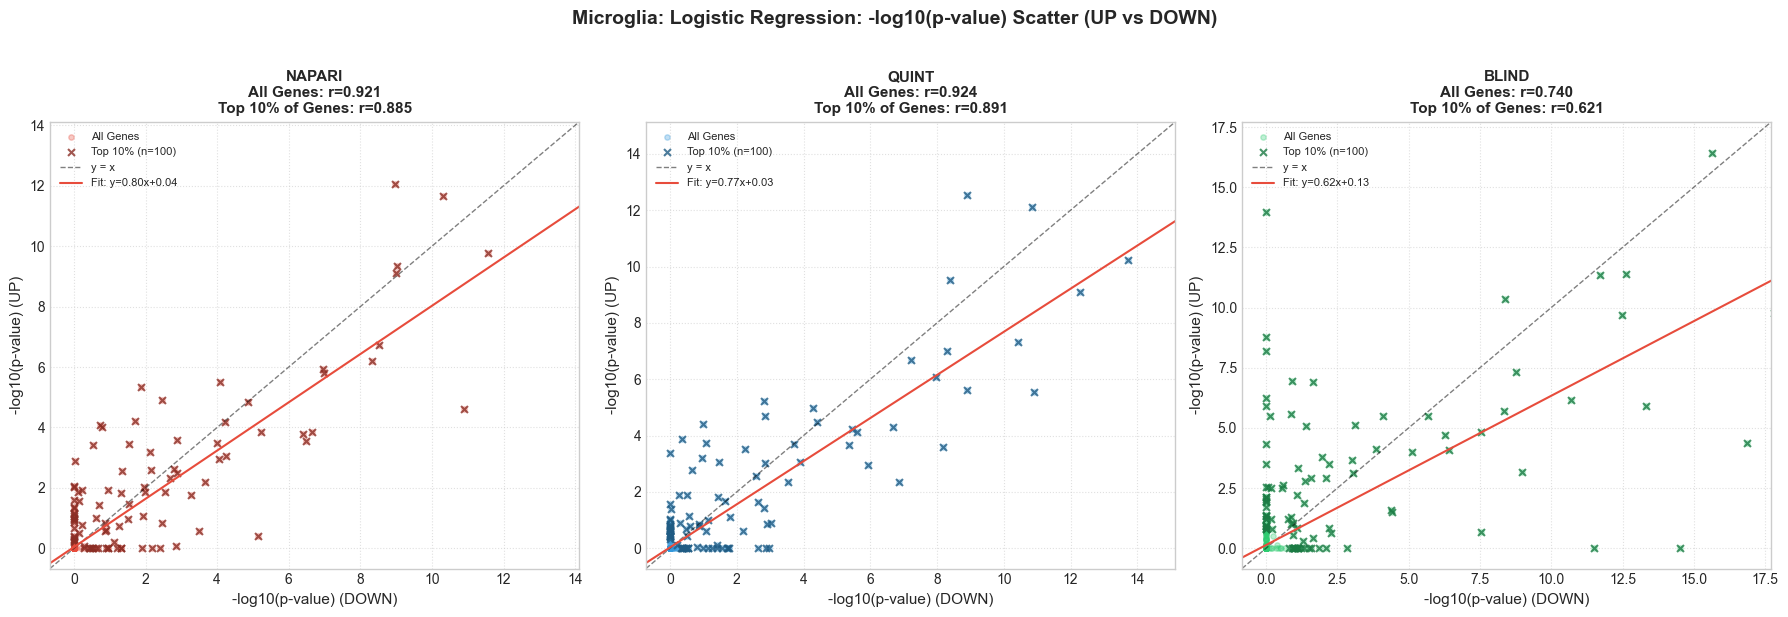

Saved: LMM_analysis_data\figures\scatter_WHOLE_lmm_models_neglog10p.png


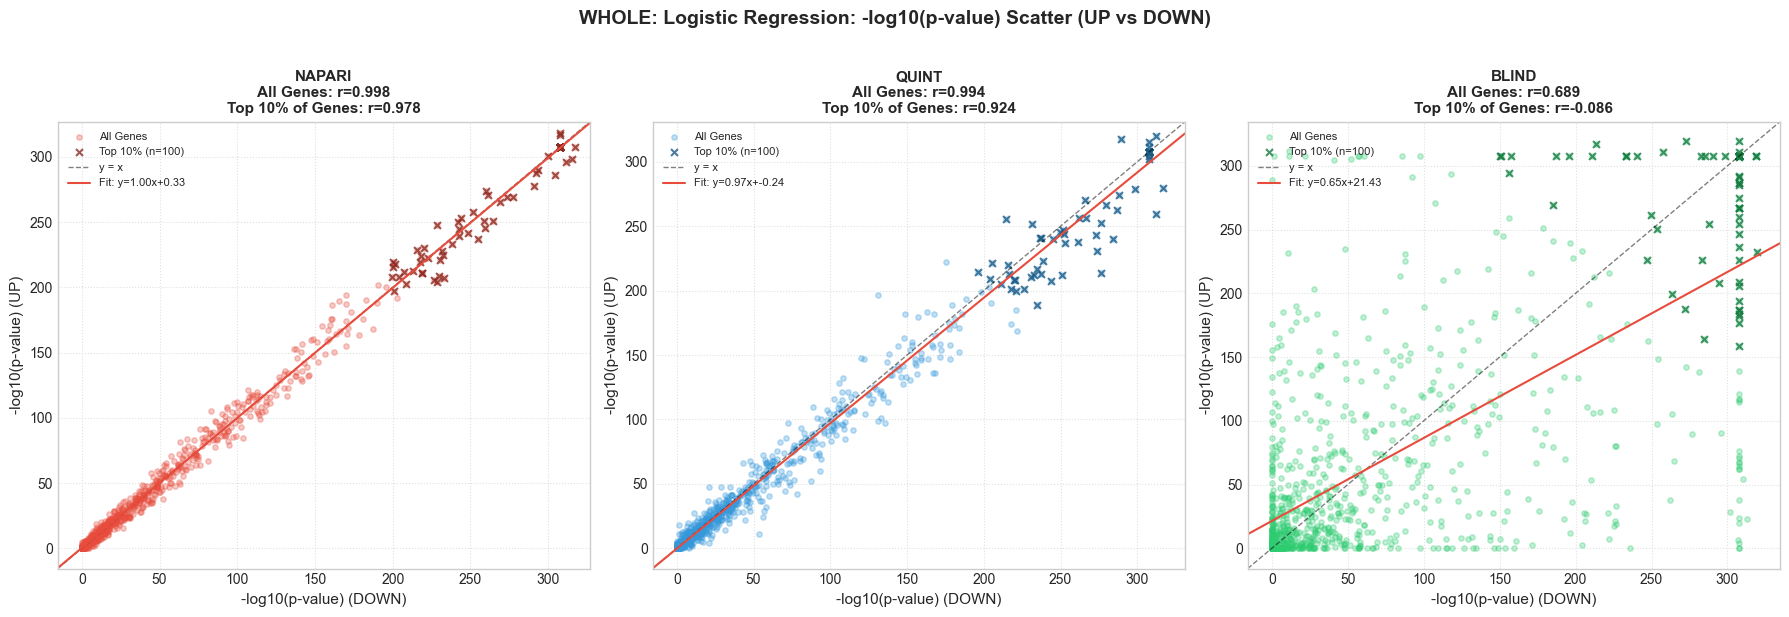

In [ ]:
# ============================================================================
# Logistic Regression (-log10 p-value)
# ============================================================================
# Compare all LMM (dream) annotations (napari, quint, blind) using Scatter plots

print("\n" + "=" * 70)
print("LR MODELS SCATTER PLOTS (-log10 p-value)")
print("=" * 70)

# Define LR annotations to compare
lmm_annotations = ['napari', 'quint', 'blind']
lmm_model = 'seurat'

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        print(f"Skipping {cell_type} - no data")
        continue
    
    if lmm_model not in data_by_celltype[cell_type]:
        print(f"Skipping {cell_type} - no LMM (dream) data")
        continue
    
    # Check which annotations are available
    available_annotations = []
    for ann in lmm_annotations:
        if ann in data_by_celltype[cell_type][lmm_model]:
            available_annotations.append(ann)
    
    if len(available_annotations) == 0:
        print(f"Skipping {cell_type} - no valid LMM annotations found")
        continue
    
    # Create figure with side-by-side plots
    n_annotations = len(available_annotations)
    fig, axes = plt.subplots(1, n_annotations, figsize=(6*n_annotations, 6))
    if n_annotations == 1:
        axes = [axes]
    
    for idx, ann_effect in enumerate(available_annotations):
        ax = axes[idx]
        # Add neglog10 p-values
        merged_df = add_neglog10_pval(data_by_celltype[cell_type][lmm_model][ann_effect].copy())
        
        # Define X and Y columns
        x_col = 'neglog10p_down'
        y_col = 'neglog10p_up'
        
        # Color setup
        color = ANNOTATION_COLORS.get(ann_effect, '#9B59B6')
        top_color = darken_color(color, factor=0.6)

        # --- AXIS RANGE LOGIC (3rd Largest to avoid outliers) ---
        x_min = merged_df[x_col].min()
        y_min = merged_df[y_col].min()
        
        if len(merged_df) >= 3:
            x_max = merged_df[x_col].nlargest(3).iloc[-1]
            y_max = merged_df[y_col].nlargest(3).iloc[-1]
        else:
            x_max = merged_df[x_col].max()
            y_max = merged_df[y_col].max()
            
        # Add 5% padding
        x_padding = (x_max - x_min) * 0.05
        y_padding = (y_max - y_min) * 0.05
        
        # Determine common limits for square plot aspect
        common_min = min(x_min, y_min) - max(x_padding, y_padding)
        common_max = max(x_max, y_max) + max(x_padding, y_padding)
        plot_range = (common_min, common_max)
        
        # 1. STATISTICS (ALL GENES)
        corr_r_all, _ = pearsonr(merged_df[y_col], merged_df[x_col])
        abs_bias_all = np.abs(merged_df[y_col] - merged_df[x_col]).mean()
        
        # 2. STATISTICS (TOP 10% GENES)
        # FIX: Unpack tuple here (mask, df)
        top10_mask, top10_df = get_top10_genes(merged_df, y_col, x_col)
        
        if len(top10_df) > 1:
            corr_r_top10, _ = pearsonr(top10_df[y_col], top10_df[x_col])
            abs_bias_top10 = np.abs(top10_df[y_col] - top10_df[x_col]).mean()
        else:
            corr_r_top10, abs_bias_top10 = np.nan, np.nan

        # Scatter plot (All Genes - Lighter)
        ax.scatter(merged_df[x_col], merged_df[y_col], alpha=0.3, s=15, 
                   color=color, label='All Genes')
        
        # Scatter plot (Top 10% Genes - Darker with 'x')
        ax.scatter(top10_df[x_col], top10_df[y_col], alpha=0.8, s=25, 
                   color=top_color, marker='x', label=f'Top 10% (n={len(top10_df)})')
        
        # Identity line (y=x)
        ax.plot(plot_range, plot_range, 'k--', alpha=0.5, linewidth=1, label='y = x')
        
        # Regression line (All data)
        if len(merged_df) > 1:
            slope, intercept = np.polyfit(merged_df[x_col], merged_df[y_col], 1)
            x_line = np.array(plot_range)
            ax.plot(x_line, slope * x_line + intercept, color='#E74C3C', linewidth=1.5,
                    label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        
        # Labels and Title
        ax.set_xlabel('-log10(p-value) (DOWN)', fontsize=11)
        ax.set_ylabel('-log10(p-value) (UP)', fontsize=11)
        
        title_str = (f'{ann_effect.upper()}\n'
                     f'All Genes: r={corr_r_all:.3f}\n'
                     f'Top 10% of Genes: r={corr_r_top10:.3f}')
        
        ax.set_title(title_str, fontsize=11, fontweight='bold')
        ax.set_xlim(plot_range)
        ax.set_ylim(plot_range)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper left', fontsize=8)

    plt.suptitle(f'{cell_type}: Logistic Regression: -log10(p-value) Scatter (UP vs DOWN)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_name = f"scatter_{cell_type}_lmm_models_neglog10p.png"
    plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / fig_name}")
    plt.show()


LMM MODELS SCATTER PLOTS (-log10 p-value)
Saved: LMM_analysis_data\figures\scatter_Astrocytes_lmm_models_neglog10p.png


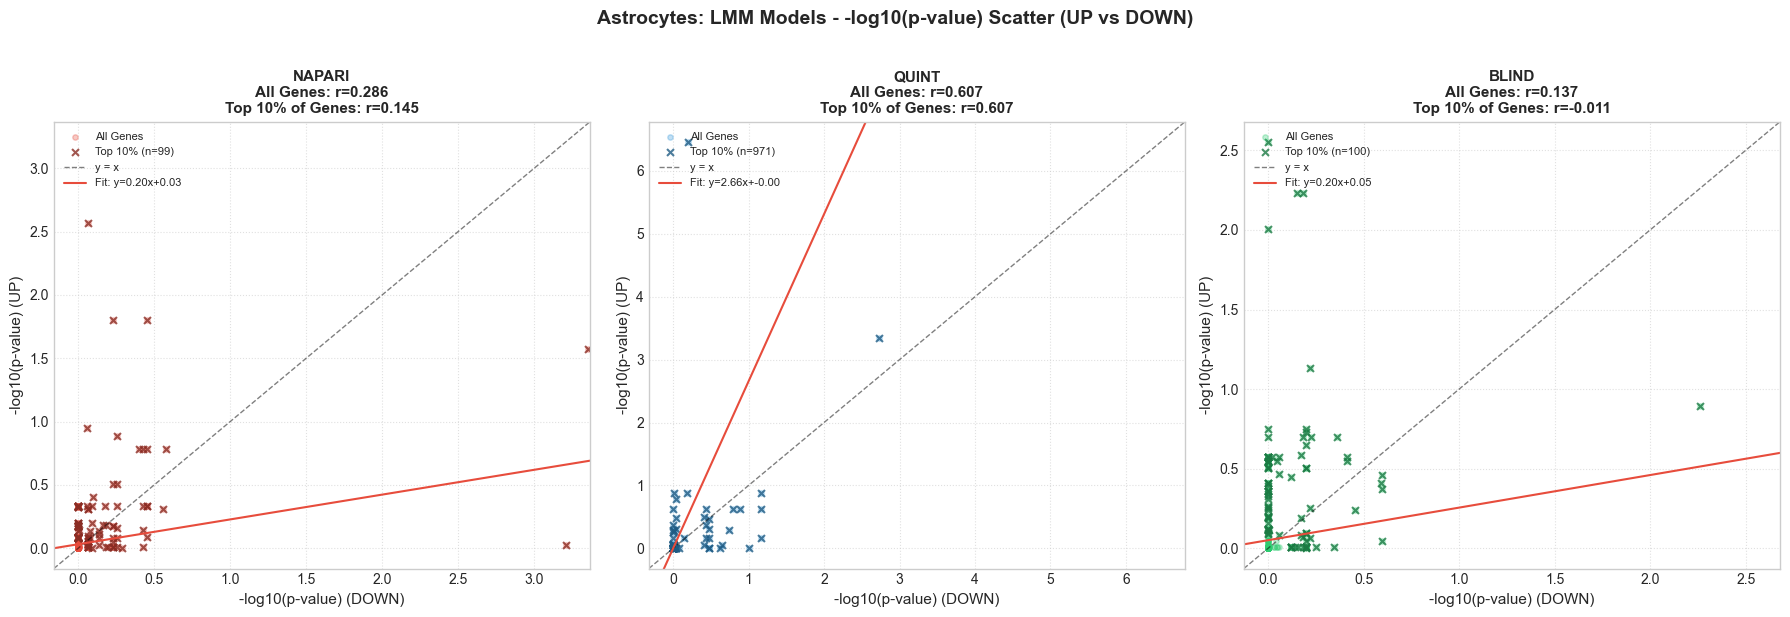

Saved: LMM_analysis_data\figures\scatter_Astrocytes_cortex_hippo_lmm_models_neglog10p.png


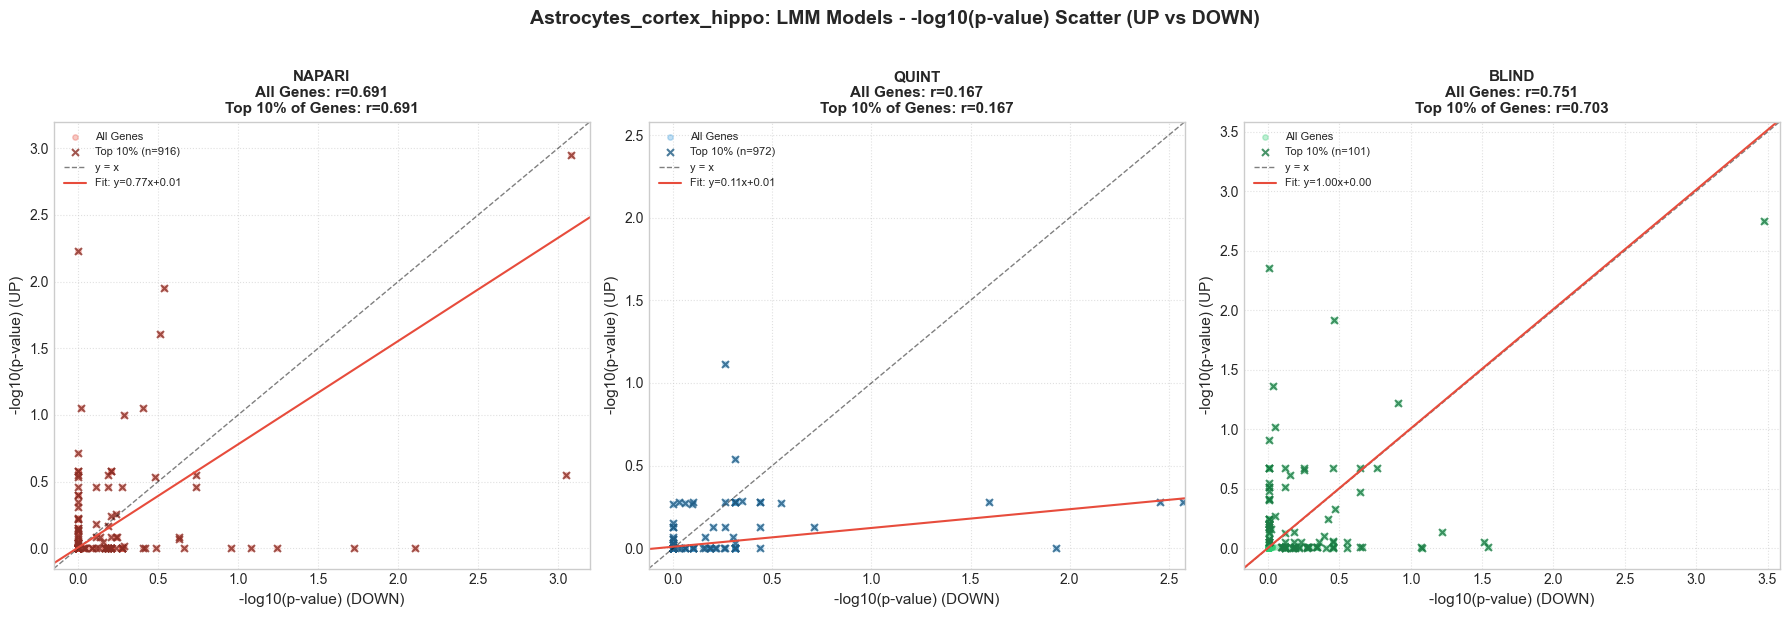

Saved: LMM_analysis_data\figures\scatter_Microglia_lmm_models_neglog10p.png


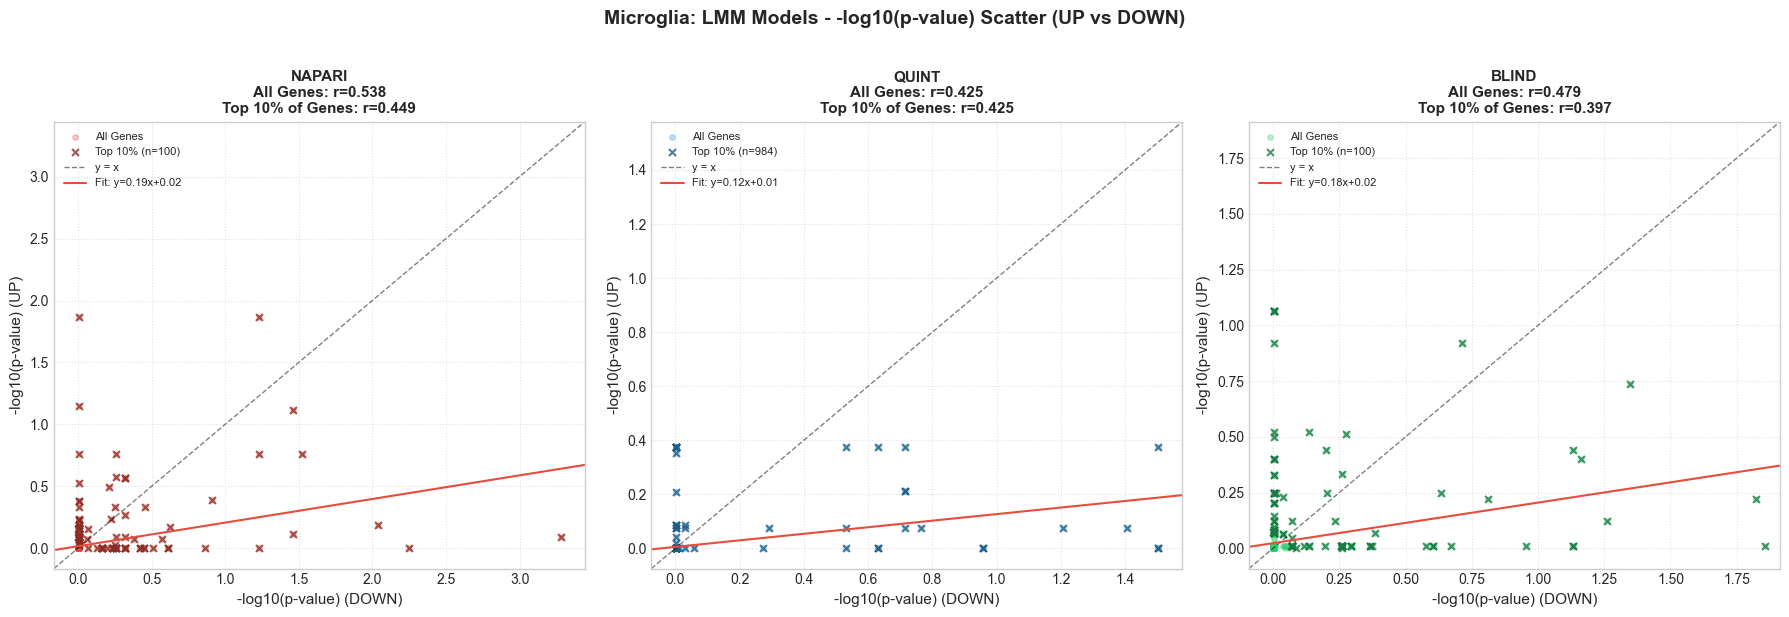

Saved: LMM_analysis_data\figures\scatter_WHOLE_lmm_models_neglog10p.png


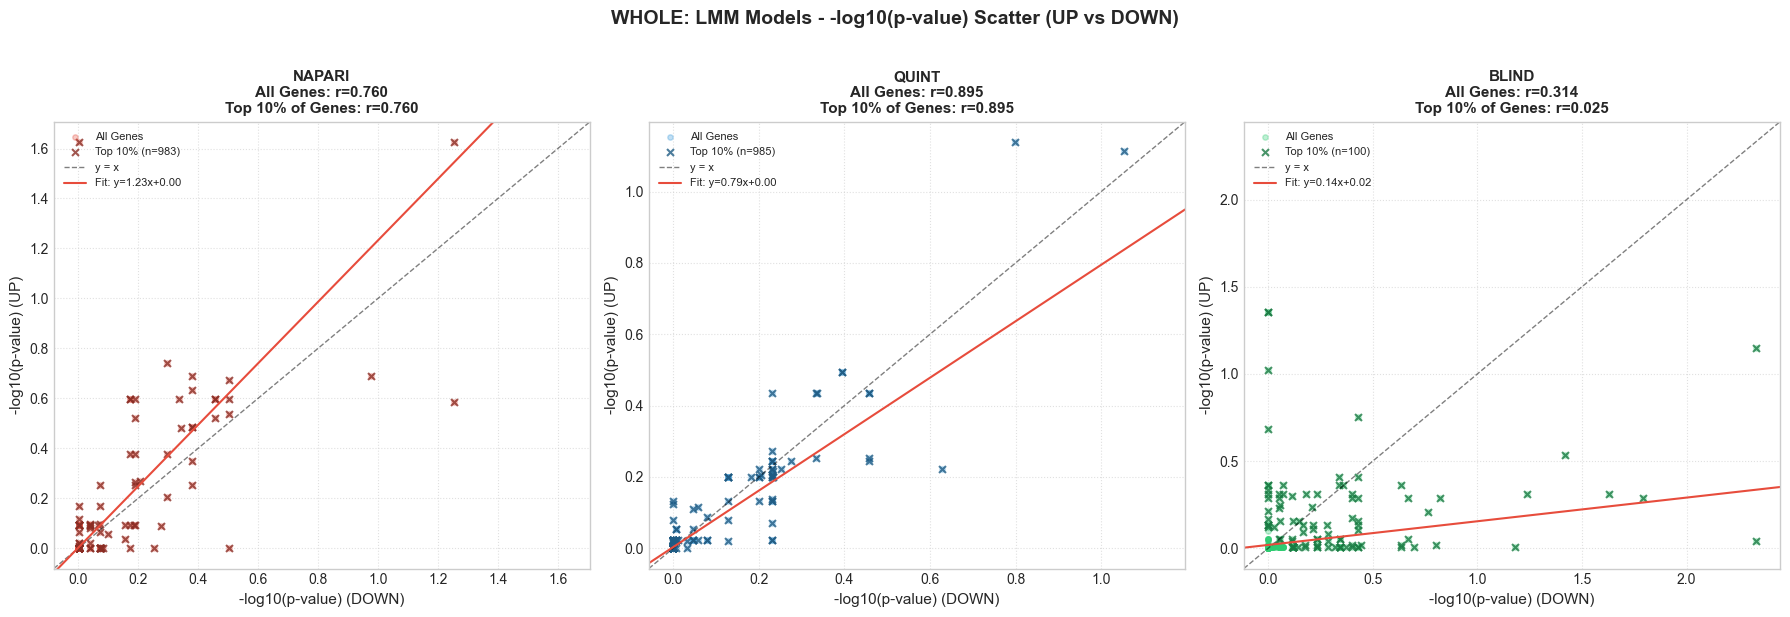

In [ ]:
# ============================================================================
# LMM MODELS SCATTER PLOTS (-log10 p-value)
# ============================================================================
# Compare all LMM (dream) annotations (napari, quint, blind) using Scatter plots

print("\n" + "=" * 70)
print("LMM MODELS SCATTER PLOTS (-log10 p-value)")
print("=" * 70)

# Define LMM annotations to compare
lmm_annotations = ['napari', 'quint', 'blind']
lmm_model = 'dream'

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        print(f"Skipping {cell_type} - no data")
        continue
    
    if lmm_model not in data_by_celltype[cell_type]:
        print(f"Skipping {cell_type} - no LMM (dream) data")
        continue
    
    # Check which annotations are available
    available_annotations = []
    for ann in lmm_annotations:
        if ann in data_by_celltype[cell_type][lmm_model]:
            available_annotations.append(ann)
    
    if len(available_annotations) == 0:
        print(f"Skipping {cell_type} - no valid LMM annotations found")
        continue
    
    # Create figure with side-by-side plots
    n_annotations = len(available_annotations)
    fig, axes = plt.subplots(1, n_annotations, figsize=(6*n_annotations, 6))
    if n_annotations == 1:
        axes = [axes]
    
    for idx, ann_effect in enumerate(available_annotations):
        ax = axes[idx]
        # Add neglog10 p-values
        merged_df = add_neglog10_pval(data_by_celltype[cell_type][lmm_model][ann_effect].copy())
        
        # Define X and Y columns
        x_col = 'neglog10p_down'
        y_col = 'neglog10p_up'
        
        # Color setup
        color = ANNOTATION_COLORS.get(ann_effect, '#9B59B6')
        top_color = darken_color(color, factor=0.6)

        # --- AXIS RANGE LOGIC (3rd Largest to avoid outliers) ---
        x_min = merged_df[x_col].min()
        y_min = merged_df[y_col].min()
        
        if len(merged_df) >= 3:
            x_max = merged_df[x_col].nlargest(3).iloc[-1]
            y_max = merged_df[y_col].nlargest(3).iloc[-1]
        else:
            x_max = merged_df[x_col].max()
            y_max = merged_df[y_col].max()
            
        # Add 5% padding
        x_padding = (x_max - x_min) * 0.05
        y_padding = (y_max - y_min) * 0.05
        
        # Determine common limits for square plot aspect
        common_min = min(x_min, y_min) - max(x_padding, y_padding)
        common_max = max(x_max, y_max) + max(x_padding, y_padding)
        plot_range = (common_min, common_max)
        
        # 1. STATISTICS (ALL GENES)
        corr_r_all, _ = pearsonr(merged_df[y_col], merged_df[x_col])
        abs_bias_all = np.abs(merged_df[y_col] - merged_df[x_col]).mean()
        
        # 2. STATISTICS (TOP 10% GENES)
        # FIX: Unpack tuple here (mask, df)
        top10_mask, top10_df = get_top10_genes(merged_df, y_col, x_col)
        
        if len(top10_df) > 1:
            corr_r_top10, _ = pearsonr(top10_df[y_col], top10_df[x_col])
            abs_bias_top10 = np.abs(top10_df[y_col] - top10_df[x_col]).mean()
        else:
            corr_r_top10, abs_bias_top10 = np.nan, np.nan

        # Scatter plot (All Genes - Lighter)
        ax.scatter(merged_df[x_col], merged_df[y_col], alpha=0.3, s=15, 
                   color=color, label='All Genes')
        
        # Scatter plot (Top 10% Genes - Darker with 'x')
        ax.scatter(top10_df[x_col], top10_df[y_col], alpha=0.8, s=25, 
                   color=top_color, marker='x', label=f'Top 10% (n={len(top10_df)})')
        
        # Identity line (y=x)
        ax.plot(plot_range, plot_range, 'k--', alpha=0.5, linewidth=1, label='y = x')
        
        # Regression line (All data)
        if len(merged_df) > 1:
            slope, intercept = np.polyfit(merged_df[x_col], merged_df[y_col], 1)
            x_line = np.array(plot_range)
            ax.plot(x_line, slope * x_line + intercept, color='#E74C3C', linewidth=1.5,
                    label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
        
        # Labels and Title
        ax.set_xlabel('-log10(p-value) (DOWN)', fontsize=11)
        ax.set_ylabel('-log10(p-value) (UP)', fontsize=11)
        
        title_str = (f'{ann_effect.upper()}\n'
                     f'All Genes: r={corr_r_all:.3f}\n'
                     f'Top 10% of Genes: r={corr_r_top10:.3f}')
        
        ax.set_title(title_str, fontsize=11, fontweight='bold')
        ax.set_xlim(plot_range)
        ax.set_ylim(plot_range)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper left', fontsize=8)

    plt.suptitle(f'{cell_type}: LMM Models - -log10(p-value) Scatter (UP vs DOWN)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    fig_name = f"scatter_{cell_type}_lmm_models_neglog10p.png"
    plt.savefig(OUTPUT_PATH / "figures" / fig_name, dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / fig_name}")
    plt.show()

In [ ]:
data_by_celltype['WHOLE']['seurat'].keys()

dict_keys(['blind', 'napari', 'quint'])

---
## Section D.2: logFC Bland-Altman Plots by Cell Type (All Models)

Bland-Altman plots comparing UP vs DOWN logFC values for each cell type and model.
Shows agreement between UP and DOWN conditions across all annotation methods.

---
## Section D.3: Seurat Bland-Altman Plots by Cell Type

Bland-Altman plots comparing UP vs DOWN logFC values specifically for Seurat model.
Seurat does not provide t-statistics, so we use logFC for Bland-Altman analysis.

In [ ]:
# Compare different Seurat annotation conditions
# Compare all pairs of Seurat annotations for each cell type

# First, print count of each cell type/model/annotation
print("=" * 70)
print("DATA SUMMARY: Number of genes per cell type/model/annotation")
print("=" * 70)
for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        continue
    print(f"\n{cell_type}:")
    for model in MODELS:
        if model not in data_by_celltype[cell_type]:
            continue
        ann_data = data_by_celltype[cell_type][model]
        ann_counts = {ann: len(df) for ann, df in ann_data.items()}
        print(f"  {model}: {ann_counts}")

print("\n" + "=" * 70)
print("COMPARING SEURAT ANNOTATION CONDITIONS")
print("=" * 70)

from itertools import combinations

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        continue
    
    # Focus only on Seurat model
    model = 'seurat'
    if model not in data_by_celltype[cell_type]:
        print(f"Skipping {cell_type} - no Seurat data")
        continue
    
    ann_data = data_by_celltype[cell_type][model]
    available_annotations = list(ann_data.keys())
    
    if len(available_annotations) < 2:
        print(f"Skipping {cell_type} - only {len(available_annotations)} Seurat annotation(s)")
        continue
    
    print(f"\n{cell_type} (Seurat):")
    
    # Compare all pairs of annotations
    for ann1, ann2 in combinations(available_annotations, 2):
        df1 = ann_data[ann1]
        df2 = ann_data[ann2]
        
        # Check if identical
        same_genes = set(df1['Gene']) == set(df2['Gene'])
        
        if same_genes:
            # Merge on Gene to compare values
            merged = pd.merge(df1, df2, on='Gene', suffixes=(f'_{ann1}', f'_{ann2}'))
            
            # Compare logFC columns
            logfc_up_same = np.allclose(merged[f'logFC_up_{ann1}'], merged[f'logFC_up_{ann2}'], equal_nan=True)
            logfc_down_same = np.allclose(merged[f'logFC_down_{ann1}'], merged[f'logFC_down_{ann2}'], equal_nan=True)
            
            if logfc_up_same and logfc_down_same:
                print(f"  ✓ {ann1} vs {ann2}: IDENTICAL (same genes, same logFC values)")
            else:
                # Calculate differences
                diff_up = (merged[f'logFC_up_{ann1}'] - merged[f'logFC_up_{ann2}']).abs()
                diff_down = (merged[f'logFC_down_{ann1}'] - merged[f'logFC_down_{ann2}']).abs()
                print(f"  ✗ {ann1} vs {ann2}: DIFFERENT logFC values")
                print(f"      logFC_up  max diff: {diff_up.max():.6f}, mean diff: {diff_up.mean():.6f}")
                print(f"      logFC_down max diff: {diff_down.max():.6f}, mean diff: {diff_down.mean():.6f}")
        else:
            print(f"  ✗ {ann1} vs {ann2}: DIFFERENT gene sets")
            print(f"      {ann1}: {len(df1)} genes, {ann2}: {len(df2)} genes")

DATA SUMMARY: Number of genes per cell type/model/annotation

Astrocytes:
  dream: {'fixed_napari': 1000, 'napari': 993, 'quint': 999, 'blind': 1000}
  seurat: {'blind': 1000, 'napari': 1000, 'quint': 1000}
  wilcoxon: {'blind': 1000}
  deseq2: {'pb': 1000}

Astrocytes_cortex_hippo:
  dream: {'fixed_napari': 1000, 'napari': 1000, 'quint': 1000, 'blind': 1000}
  seurat: {'blind': 1000, 'napari': 1000, 'quint': 1000}
  wilcoxon: {'blind': 1000}
  deseq2: {'pb': 1000}

Microglia:
  dream: {'fixed_napari': 1000, 'napari': 1000, 'quint': 1000, 'blind': 1000}
  seurat: {'blind': 1000, 'napari': 1000, 'quint': 1000}
  wilcoxon: {'blind': 1000}
  deseq2: {'pb': 1000}

WHOLE:
  dream: {'fixed_napari': 1000, 'napari': 1000, 'quint': 1000, 'blind': 1000}
  seurat: {'blind': 1000, 'napari': 1000, 'quint': 1000}
  wilcoxon: {'blind': 1000}
  deseq2: {'pb': 1000}

COMPARING SEURAT ANNOTATION CONDITIONS

Astrocytes (Seurat):
  ✓ blind vs napari: IDENTICAL (same genes, same logFC values)
  ✓ blind vs 

In [ ]:
# Summary Statistics Table for Scatter Plots
scatter_summary_rows = []

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        continue
    
    for model in MODELS:
        if model not in data_by_celltype[cell_type]:
            continue
        
        for ann_effect, merged_df in data_by_celltype[cell_type][model].items():
            # logFC correlations
            corr_logfc = lmm.calculate_correlations(merged_df, col1='logFC_up', col2='logFC_down')
            
            # t-statistic correlations (if available)
            if 't_up' in merged_df.columns and 't_down' in merged_df.columns:
                corr_t = lmm.calculate_correlations(merged_df, col1='t_up', col2='t_down')
                t_pearson = corr_t['pearson_r']
                t_spearman = corr_t['spearman_r']
            else:
                t_pearson = np.nan
                t_spearman = np.nan
            
            scatter_summary_rows.append({
                'Cell Type': cell_type,
                'Model': model.upper(),
                'Annotation': ann_effect,
                'N Genes': len(merged_df),
                'logFC Pearson R': corr_logfc['pearson_r'],
                'logFC Spearman ρ': corr_logfc['spearman_r'],
                't Pearson R': t_pearson,
                't Spearman ρ': t_spearman
            })

scatter_summary_df = pd.DataFrame(scatter_summary_rows)

print("=" * 100)
print("SUMMARY: Scatter Plot Correlations by Cell Type, Model, and Annotation")
print("=" * 100)
display(scatter_summary_df.round(4))

# Save summary
scatter_summary_df.to_csv(OUTPUT_PATH / "tables" / "scatter_correlation_summary.csv", index=False)
print(f"\nSaved: {OUTPUT_PATH / 'tables' / 'scatter_correlation_summary.csv'}")

SUMMARY: Scatter Plot Correlations by Cell Type, Model, and Annotation


,Cell Type,Model,Annotation,N Genes,logFC Pearson R,logFC Spearman ρ,t Pearson R,t Spearman ρ
0,Astrocytes,DREAM,fixed_napari,1000,0.9813,0.9200,0.8845,0.9097
1,Astrocytes,DREAM,napari,993,0.9813,0.9209,0.8850,0.9109
2,Astrocytes,DREAM,quint,999,0.9806,0.9545,0.9334,0.9479
3,Astrocytes,DREAM,blind,1000,0.8247,0.8058,0.8140,0.8492
4,Astrocytes,SEURAT,blind,1000,0.8854,0.8840,NaN,NaN
5,Astrocytes,SEURAT,napari,1000,0.8854,0.8840,NaN,NaN
6,Astrocytes,SEURAT,quint,1000,0.8854,0.8840,NaN,NaN
7,Astrocytes,WILCOXON,blind,1000,0.8854,0.8840,NaN,NaN
8,Astrocytes,DESEQ2,pb,1000,0.9244,0.9162,NaN,NaN
9,Astrocytes_cortex_hippo,DREAM,fixed_napari,1000,0.9554,0.8410,0.8212,0.8293



Saved: LMM_analysis_data\tables\scatter_correlation_summary.csv


In [ ]:
# Summary Statistics Table
summary_rows = []

for cell_type in CELL_TYPES:
    if cell_type not in data_by_celltype:
        continue
    
    for model in MODELS:
        if model not in data_by_celltype[cell_type]:
            continue
        
        for ann_effect, merged_df in data_by_celltype[cell_type][model].items():
            ba = lmm.bland_altman_stats(merged_df)
            corr = lmm.calculate_correlations(merged_df)
            
            summary_rows.append({
                'Cell Type': cell_type,
                'Model': model.upper(),
                'Annotation': ann_effect,
                'N Genes': len(merged_df),
                'Pearson R': corr['pearson_r'],
                'Mean Bias': ba['mean_diff'],
                'Lower LoA': ba['lower_loa'],
                'Upper LoA': ba['upper_loa'],
                'LoA Width': ba['upper_loa'] - ba['lower_loa']
            })

summary_df = pd.DataFrame(summary_rows)

print("=" * 90)
print("SUMMARY: UP vs DOWN Consistency by Cell Type, Model, and Annotation")
print("=" * 90)
display(summary_df.round(4))

# Save summary
summary_df.to_csv(OUTPUT_PATH / "tables" / "annotation_comparison_summary.csv", index=False)
print(f"\nSaved: {OUTPUT_PATH / 'tables' / 'annotation_comparison_summary.csv'}")

SUMMARY: UP vs DOWN Consistency by Cell Type, Model, and Annotation


,Cell Type,Model,Annotation,N Genes,Pearson R,Mean Bias,Lower LoA,Upper LoA,LoA Width
0,Astrocytes,DREAM,fixed_napari,1000,0.9813,0.0002,-0.0251,0.0256,0.0506
1,Astrocytes,DREAM,napari,993,0.9813,-0.0000,-0.0254,0.0253,0.0507
2,Astrocytes,DREAM,quint,999,0.9806,0.0005,-0.0353,0.0363,0.0716
3,Astrocytes,DREAM,blind,1000,0.8247,-0.0023,-0.0852,0.0805,0.1657
4,Astrocytes,SEURAT,blind,1000,0.8854,0.0059,-0.2204,0.2322,0.4526
5,Astrocytes,SEURAT,napari,1000,0.8854,0.0059,-0.2204,0.2322,0.4526
6,Astrocytes,SEURAT,quint,1000,0.8854,0.0059,-0.2204,0.2322,0.4526
7,Astrocytes,WILCOXON,blind,1000,0.8854,0.0059,-0.2204,0.2322,0.4526
8,Astrocytes,DESEQ2,pb,1000,0.9244,0.0023,-0.2094,0.2140,0.4234
9,Astrocytes_cortex_hippo,DREAM,fixed_napari,1000,0.9554,0.0017,-0.0343,0.0377,0.0720



Saved: LMM_analysis_data\tables\annotation_comparison_summary.csv


In [ ]:
# Compare LoA Width across annotations for each cell type
print("=" * 70)
print("COMPARISON: LoA Width by Annotation (lower = more consistent)")
print("=" * 70)

for cell_type in CELL_TYPES:
    ct_data = summary_df[summary_df['Cell Type'] == cell_type]
    if len(ct_data) > 0:
        print(f"\n{cell_type}:")
        for _, row in ct_data.iterrows():
            print(f"  {row['Model']}/{row['Annotation']}: LoA Width = {row['LoA Width']:.4f}")

COMPARISON: LoA Width by Annotation (lower = more consistent)

Astrocytes:
  DREAM/fixed_napari: LoA Width = 0.0506
  DREAM/napari: LoA Width = 0.0507
  DREAM/quint: LoA Width = 0.0716
  DREAM/blind: LoA Width = 0.1657
  SEURAT/blind: LoA Width = 0.4526
  SEURAT/napari: LoA Width = 0.4526
  SEURAT/quint: LoA Width = 0.4526
  WILCOXON/blind: LoA Width = 0.4526
  DESEQ2/pb: LoA Width = 0.4234

Astrocytes_cortex_hippo:
  DREAM/fixed_napari: LoA Width = 0.0720
  DREAM/napari: LoA Width = 0.0717
  DREAM/quint: LoA Width = 0.0964
  DREAM/blind: LoA Width = 0.1411
  SEURAT/blind: LoA Width = 0.5933
  SEURAT/napari: LoA Width = 0.5933
  SEURAT/quint: LoA Width = 0.5933
  WILCOXON/blind: LoA Width = 0.5933
  DESEQ2/pb: LoA Width = 0.5459

Microglia:
  DREAM/fixed_napari: LoA Width = 0.1775
  DREAM/napari: LoA Width = 0.1765
  DREAM/quint: LoA Width = 0.2187
  DREAM/blind: LoA Width = 0.2308
  SEURAT/blind: LoA Width = 0.8365
  SEURAT/napari: LoA Width = 0.8365
  SEURAT/quint: LoA Width = 0.8365

---
## Summary

This analysis compared UP vs DOWN consistency across annotation methods for each cell type.

**Key metrics**:
- **Pearson R**: Correlation between UP and DOWN logFC values  
- **Mean Bias**: Average difference (UP - DOWN)
- **LoA Width**: Width of 95% Limits of Agreement (narrower = more consistent)

**Output files**:
- `figures/bland_altman_{celltype}_{model}.png` - Side-by-side + overlaid Bland-Altman plots
- `tables/annotation_comparison_summary.csv` - Summary statistics

Saved: LMM_analysis_data\figures\bland_altman_seurat.png


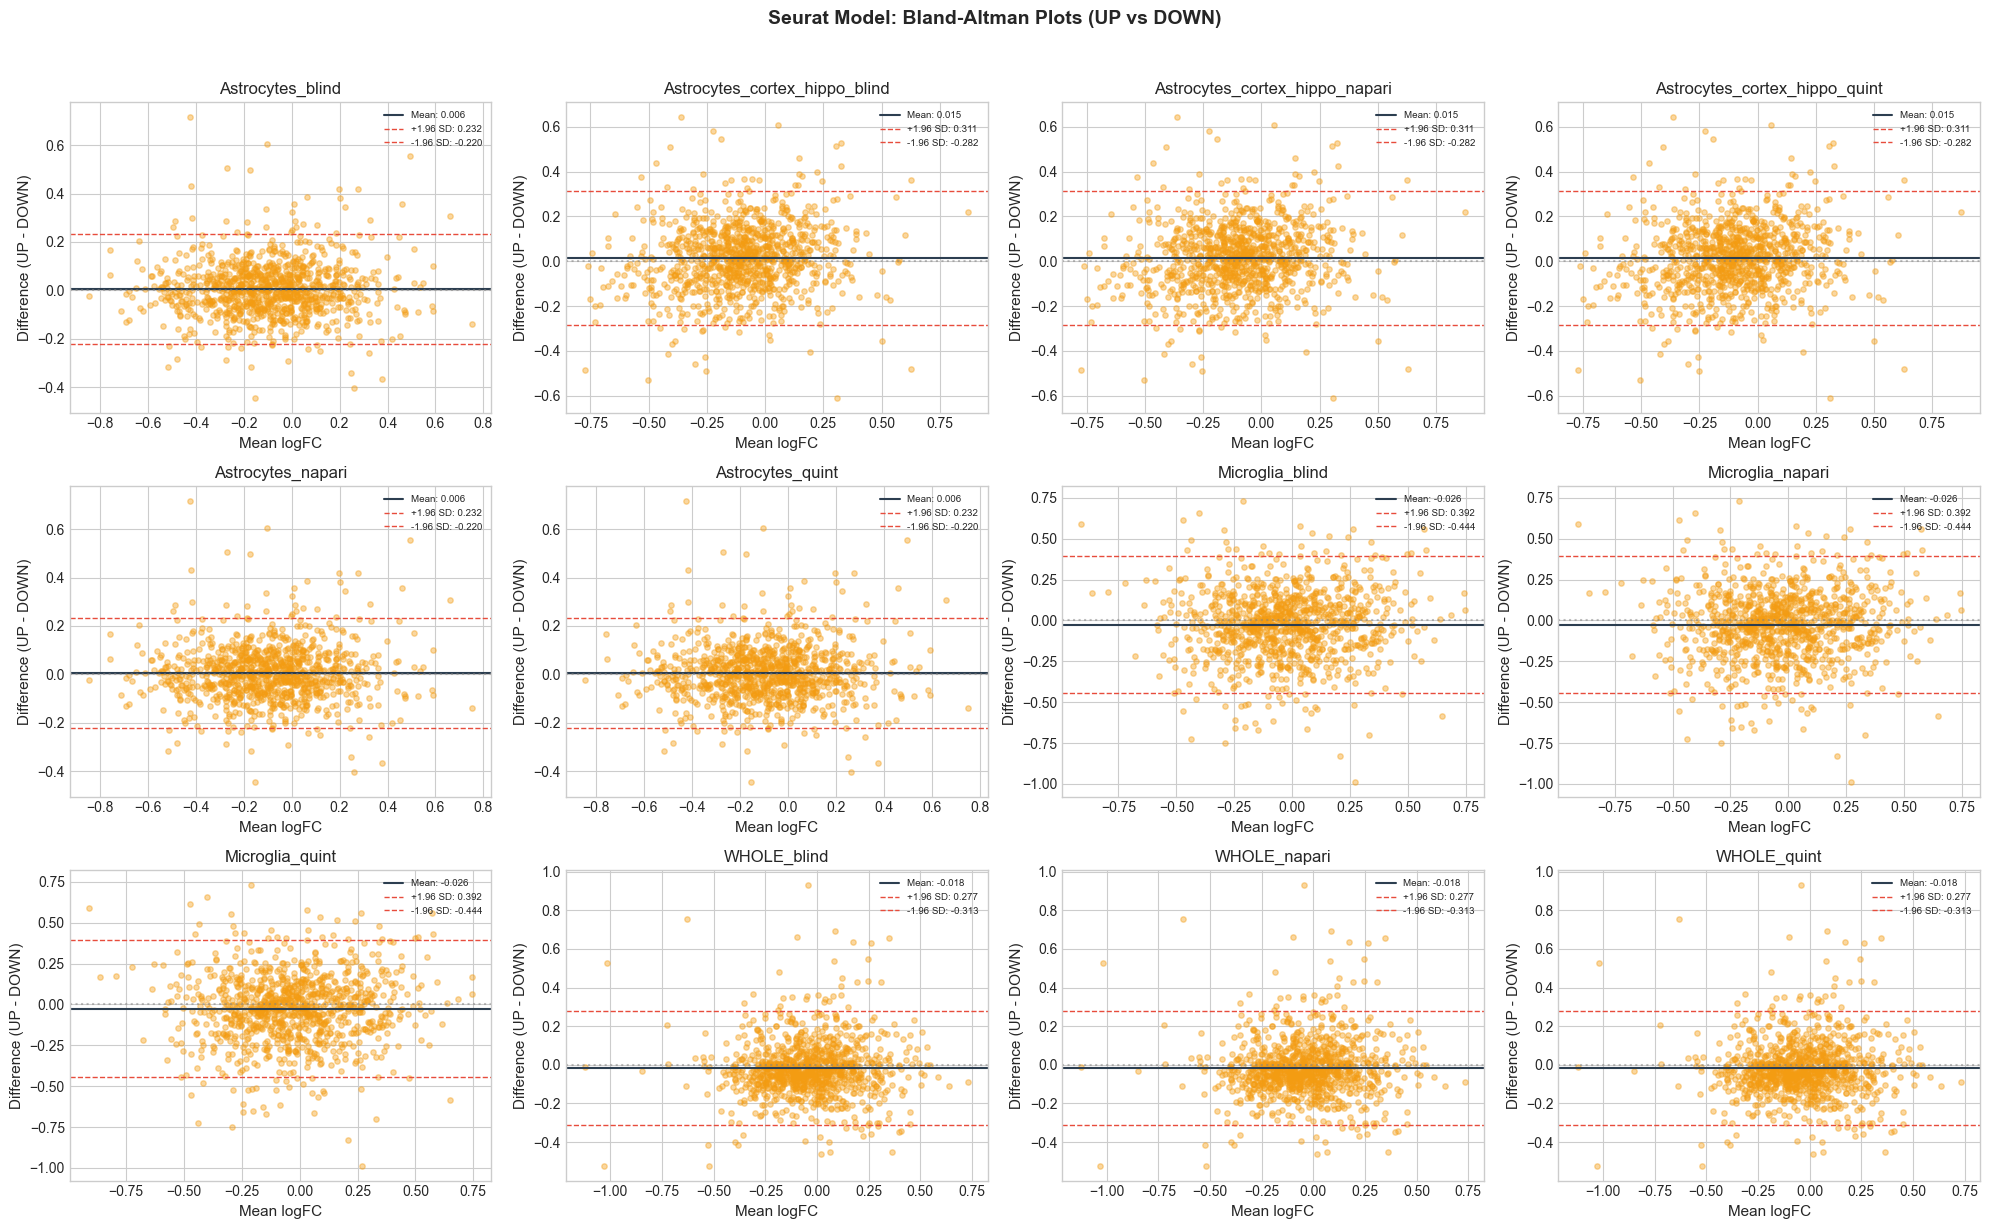

In [ ]:
# Seurat: Bland-Altman Plots
seurat_data = all_data.get("seurat", {})
if seurat_data:
    n_plots = len(seurat_data)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (name, merged_df) in enumerate(sorted(seurat_data.items())):
        ax = axes[idx]
        
        # Calculate Bland-Altman stats
        ba_stats = lmm.bland_altman_stats(merged_df)
        
        # Scatter plot
        ax.scatter(ba_stats['avg'], ba_stats['diff'], alpha=0.4, s=15, color=MODEL_COLORS['seurat'])
        
        # Reference lines
        ax.axhline(ba_stats['mean_diff'], color='#2C3E50', linestyle='-', linewidth=1.5, label=f'Mean: {ba_stats["mean_diff"]:.3f}')
        ax.axhline(ba_stats['upper_loa'], color='#E74C3C', linestyle='--', linewidth=1, label=f'+1.96 SD: {ba_stats["upper_loa"]:.3f}')
        ax.axhline(ba_stats['lower_loa'], color='#E74C3C', linestyle='--', linewidth=1, label=f'-1.96 SD: {ba_stats["lower_loa"]:.3f}')
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Mean logFC')
        ax.set_ylabel('Difference (UP - DOWN)')
        ax.set_title(f'{name}')
        ax.legend(loc='upper right', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(seurat_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Seurat Model: Bland-Altman Plots (UP vs DOWN)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "figures" / "bland_altman_seurat.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / 'bland_altman_seurat.png'}")
    plt.show()

Saved: LMM_analysis_data\figures\scatter_seurat.png


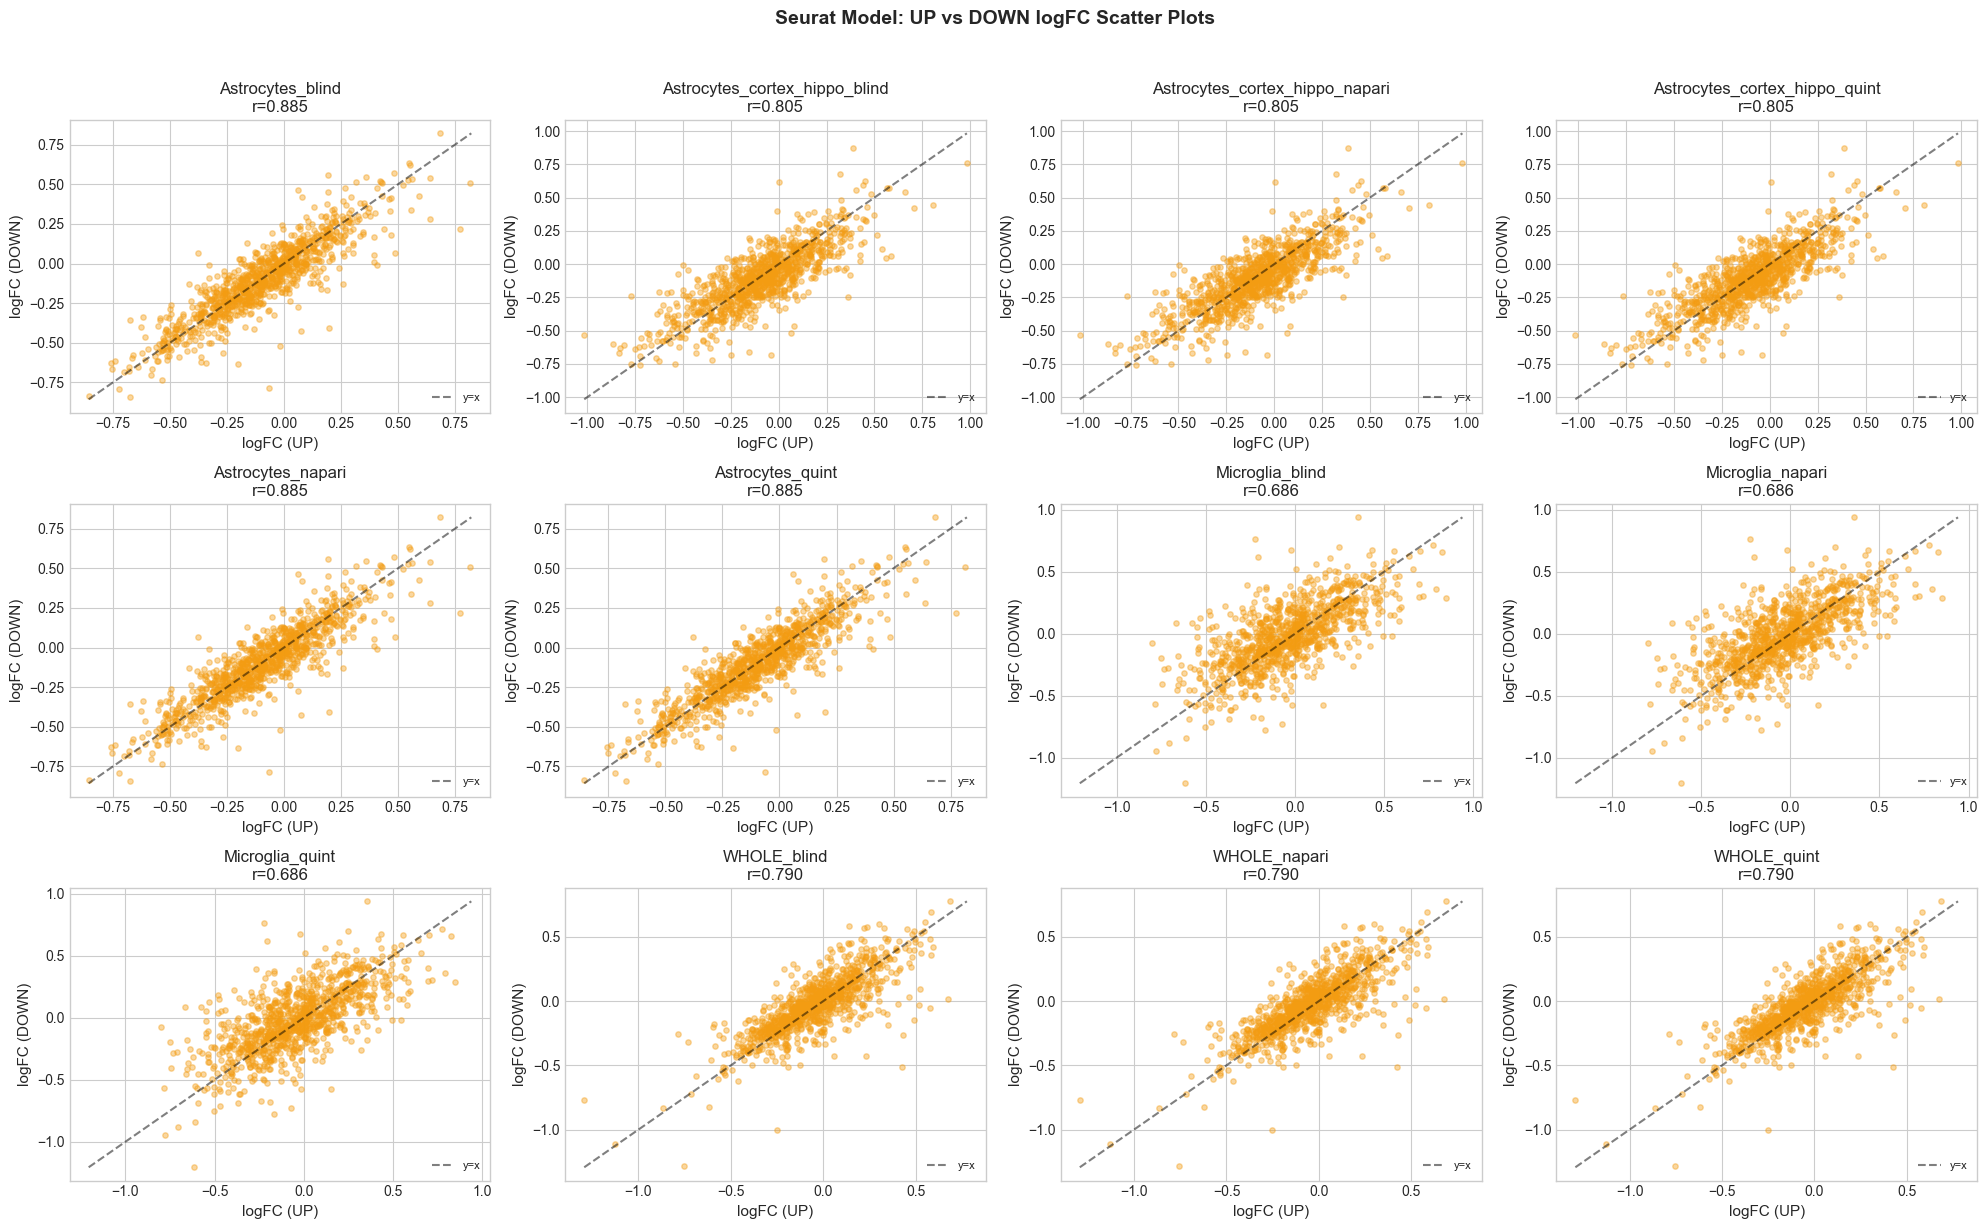

In [ ]:
# Seurat: Scatter Plots
seurat_data = all_data.get("seurat", {})
if seurat_data:
    n_plots = len(seurat_data)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (name, merged_df) in enumerate(sorted(seurat_data.items())):
        ax = axes[idx]
        
        # Get correlation
        corr_stats = lmm.calculate_correlations(merged_df)
        
        # Scatter plot
        ax.scatter(merged_df['logFC_up'], merged_df['logFC_down'], 
                  alpha=0.4, s=15, color=MODEL_COLORS['seurat'])
        
        # Identity line
        lims = [min(merged_df['logFC_up'].min(), merged_df['logFC_down'].min()),
               max(merged_df['logFC_up'].max(), merged_df['logFC_down'].max())]
        ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
        
        ax.set_xlabel('logFC (UP)')
        ax.set_ylabel('logFC (DOWN)')
        ax.set_title(f'{name}\nr={corr_stats["pearson_r"]:.3f}')
        ax.legend(loc='lower right', fontsize=8)
    
    # Hide empty subplots
    for idx in range(len(seurat_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Seurat Model: UP vs DOWN logFC Scatter Plots', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "figures" / "scatter_seurat.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / 'scatter_seurat.png'}")
    plt.show()

---
## Section E: Pseudobulk (DESeq2) Model - UP vs DOWN Comparison

Compare logFC values between UP and DOWN conditions for **Pseudobulk (DESeq2)** validation models.

In [ ]:
# Generate summary statistics for Pseudobulk comparisons
pseudobulk_data = all_data.get("pseudobulk", {})
if pseudobulk_data:
    pseudobulk_summary = lmm.create_summary_table(pseudobulk_data)
    
    # Display key correlation metrics
    display_cols = [
        'name', 'n_genes', 
        'corr_pearson_r', 'corr_spearman_r', 
        'conc_concordance_rate'
    ]
    print("=" * 80)
    print("CORRELATION SUMMARY: Pseudobulk (DESeq2) Model - UP vs DOWN")
    print("=" * 80)
    display(pseudobulk_summary[display_cols].round(4))
    
    # Overall statistics
    print(f"\n" + "=" * 60)
    print("OVERALL STATISTICS - PSEUDOBULK")
    print("=" * 60)
    print(f"Mean Pearson R:       {pseudobulk_summary['corr_pearson_r'].mean():.4f} +/- {pseudobulk_summary['corr_pearson_r'].std():.4f}")
    print(f"Mean Spearman R:      {pseudobulk_summary['corr_spearman_r'].mean():.4f} +/- {pseudobulk_summary['corr_spearman_r'].std():.4f}")
    print(f"Mean Concordance:     {pseudobulk_summary['conc_concordance_rate'].mean():.2f}% +/- {pseudobulk_summary['conc_concordance_rate'].std():.2f}%")
else:
    print("No Pseudobulk data available")

No Pseudobulk data available


In [ ]:
# Pseudobulk: Bland-Altman Plots
pseudobulk_data = all_data.get("pseudobulk", {})
if pseudobulk_data:
    n_plots = len(pseudobulk_data)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (name, merged_df) in enumerate(sorted(pseudobulk_data.items())):
        ax = axes[idx]
        
        # Calculate Bland-Altman stats
        ba_stats = lmm.bland_altman_stats(merged_df)
        
        # Scatter plot
        ax.scatter(ba_stats['avg'], ba_stats['diff'], alpha=0.4, s=15, color=MODEL_COLORS['pseudobulk'])
        
        # Reference lines
        ax.axhline(ba_stats['mean_diff'], color='#2C3E50', linestyle='-', linewidth=1.5, label=f'Mean: {ba_stats["mean_diff"]:.3f}')
        ax.axhline(ba_stats['upper_loa'], color='#E74C3C', linestyle='--', linewidth=1, label=f'+1.96 SD: {ba_stats["upper_loa"]:.3f}')
        ax.axhline(ba_stats['lower_loa'], color='#E74C3C', linestyle='--', linewidth=1, label=f'-1.96 SD: {ba_stats["lower_loa"]:.3f}')
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        
        ax.set_xlabel('Mean logFC')
        ax.set_ylabel('Difference (UP - DOWN)')
        ax.set_title(f'{name}')
        ax.legend(loc='upper right', fontsize=7)
    
    # Hide empty subplots
    for idx in range(len(pseudobulk_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Pseudobulk (DESeq2): Bland-Altman Plots (UP vs DOWN)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "figures" / "bland_altman_pseudobulk.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / 'bland_altman_pseudobulk.png'}")
    plt.show()

In [ ]:
# Pseudobulk: Scatter Plots
pseudobulk_data = all_data.get("pseudobulk", {})
if pseudobulk_data:
    n_plots = len(pseudobulk_data)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (name, merged_df) in enumerate(sorted(pseudobulk_data.items())):
        ax = axes[idx]
        
        # Get correlation
        corr_stats = lmm.calculate_correlations(merged_df)
        
        # Scatter plot
        ax.scatter(merged_df['logFC_up'], merged_df['logFC_down'], 
                  alpha=0.4, s=15, color=MODEL_COLORS['pseudobulk'])
        
        # Identity line
        lims = [min(merged_df['logFC_up'].min(), merged_df['logFC_down'].min()),
               max(merged_df['logFC_up'].max(), merged_df['logFC_down'].max())]
        ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
        
        ax.set_xlabel('logFC (UP)')
        ax.set_ylabel('logFC (DOWN)')
        ax.set_title(f'{name}\nr={corr_stats["pearson_r"]:.3f}')
        ax.legend(loc='lower right', fontsize=8)
    
    # Hide empty subplots
    for idx in range(len(pseudobulk_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Pseudobulk (DESeq2): UP vs DOWN logFC Scatter Plots', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "figures" / "scatter_pseudobulk.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / 'scatter_pseudobulk.png'}")
    plt.show()

---
## Section F: Cross-Model Comparison Summary

Compare the UP vs DOWN consistency across all three model types (DREAM, Seurat, Pseudobulk).

In [ ]:
# Create cross-model comparison summary
print("=" * 100)
print("CROSS-MODEL COMPARISON: UP vs DOWN Consistency")
print("=" * 100)

summary_rows = []
for model_type in ["dream", "seurat", "pseudobulk"]:
    data = all_data.get(model_type, {})
    if data:
        summary = lmm.create_summary_table(data)
        summary_rows.append({
            "Model": lmm.get_model_display_name(model_type),
            "N Comparisons": len(data),
            "Mean Pearson R": f"{summary['corr_pearson_r'].mean():.4f} ± {summary['corr_pearson_r'].std():.4f}",
            "Mean Spearman R": f"{summary['corr_spearman_r'].mean():.4f} ± {summary['corr_spearman_r'].std():.4f}",
            "Mean Concordance %": f"{summary['conc_concordance_rate'].mean():.2f} ± {summary['conc_concordance_rate'].std():.2f}"
        })

cross_summary = pd.DataFrame(summary_rows)
display(cross_summary)

CROSS-MODEL COMPARISON: UP vs DOWN Consistency


,Model,N Comparisons,Mean Pearson R,Mean Spearman R,Mean Concordance %
0,DREAM,16,0.9240 ± 0.0694,0.8482 ± 0.1095,85.43 ± 7.03
1,Seurat,12,0.7918 ± 0.0740,0.7924 ± 0.0711,81.52 ± 3.48


Saved: LMM_analysis_data\figures\cross_model_comparison.png


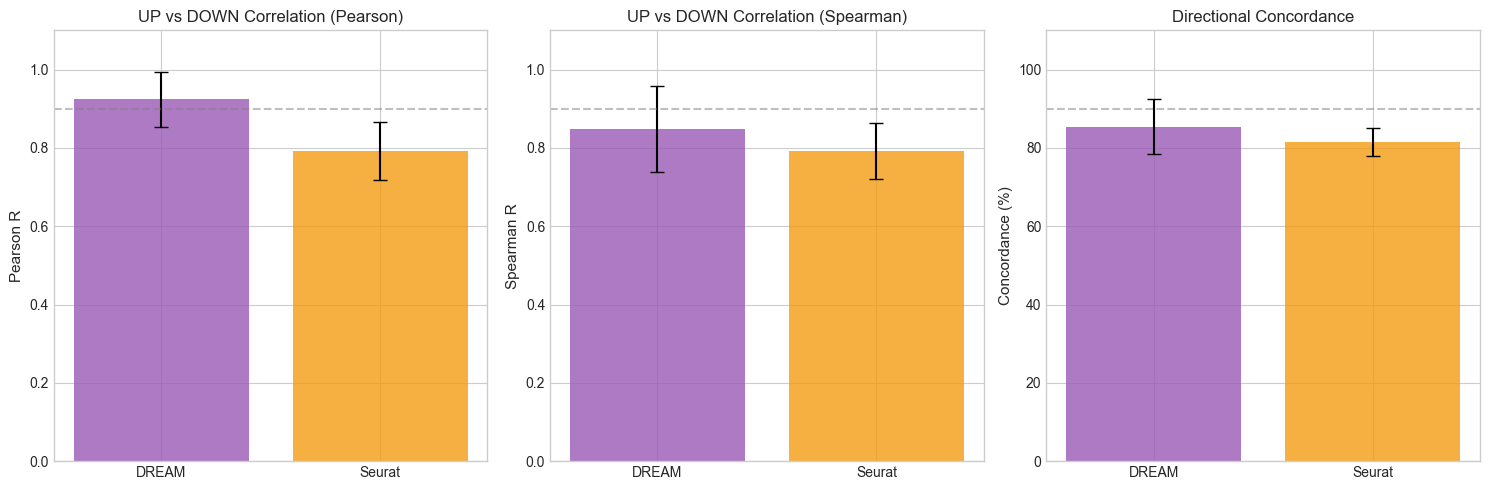

In [ ]:
# Create visualization comparing models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_types = ["dream", "seurat", "pseudobulk"]
model_names = []
pearson_means = []
pearson_stds = []
spearman_means = []
spearman_stds = []
concordance_means = []
concordance_stds = []

for model_type in model_types:
    data = all_data.get(model_type, {})
    if data:
        summary = lmm.create_summary_table(data)
        model_names.append(lmm.get_model_display_name(model_type).replace(" ", "\n"))
        pearson_means.append(summary['corr_pearson_r'].mean())
        pearson_stds.append(summary['corr_pearson_r'].std())
        spearman_means.append(summary['corr_spearman_r'].mean())
        spearman_stds.append(summary['corr_spearman_r'].std())
        concordance_means.append(summary['conc_concordance_rate'].mean())
        concordance_stds.append(summary['conc_concordance_rate'].std())

colors = [MODEL_COLORS[m] for m in model_types if all_data.get(m)]

# Pearson R
axes[0].bar(model_names, pearson_means, yerr=pearson_stds, color=colors, capsize=5, alpha=0.8)
axes[0].set_ylabel('Pearson R')
axes[0].set_title('UP vs DOWN Correlation (Pearson)')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='r=0.9')

# Spearman R
axes[1].bar(model_names, spearman_means, yerr=spearman_stds, color=colors, capsize=5, alpha=0.8)
axes[1].set_ylabel('Spearman R')
axes[1].set_title('UP vs DOWN Correlation (Spearman)')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='r=0.9')

# Concordance
axes[2].bar(model_names, concordance_means, yerr=concordance_stds, color=colors, capsize=5, alpha=0.8)
axes[2].set_ylabel('Concordance (%)')
axes[2].set_title('Directional Concordance')
axes[2].set_ylim(0, 110)
axes[2].axhline(90, color='gray', linestyle='--', alpha=0.5, label='90%')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "figures" / "cross_model_comparison.png", dpi=150, bbox_inches='tight')
print(f"Saved: {OUTPUT_PATH / 'figures' / 'cross_model_comparison.png'}")
plt.show()

In [ ]:
# Overlap analysis for each model type
for model_type in ["dream", "seurat", "pseudobulk"]:
    data = all_data.get(model_type, {})
    if data:
        summary = lmm.create_summary_table(data)
        
        # Display overlap metrics
        overlap_cols = [
            'name', 
            'overlap_n_sig_up', 'overlap_n_sig_down',
            'overlap_both_significant', 'overlap_jaccard_index'
        ]
        print("=" * 100)
        print(f"OVERLAP ANALYSIS: {lmm.get_model_display_name(model_type)} - UP vs DOWN (adj.P.Val < 0.05)")
        print("=" * 100)
        display(summary[overlap_cols].round(4))
        
        print(f"\nMean Jaccard Index: {summary['overlap_jaccard_index'].mean():.4f} +/- {summary['overlap_jaccard_index'].std():.4f}")
        print()

OVERLAP ANALYSIS: DREAM - UP vs DOWN (adj.P.Val < 0.05)


,name,overlap_n_sig_up,overlap_n_sig_down,overlap_both_significant,overlap_jaccard_index
0,Astrocytes_cortex_hippo_fixed_napari,4,5,2,0.2857
1,Astrocytes_cortex_hippo_napari,5,5,2,0.2500
2,Astrocytes_cortex_hippo_quint,1,5,0,0.0000
3,Astrocytes_fixed_napari,4,3,1,0.1667
4,Astrocytes_napari,4,3,1,0.1667
5,Astrocytes_quint,4,2,2,0.5000
6,Microglia_fixed_napari,3,6,1,0.1250
7,Microglia_napari,3,8,1,0.1000
8,Microglia_quint,0,5,0,0.0000
9,WHOLE_fixed_napari,4,0,0,0.0000



Mean Jaccard Index: 0.1356 +/- 0.1553

OVERLAP ANALYSIS: Seurat - UP vs DOWN (adj.P.Val < 0.05)


,name,overlap_n_sig_up,overlap_n_sig_down,overlap_both_significant,overlap_jaccard_index
0,Astrocytes_cortex_hippo_blind,172,190,114,0.4597
1,Astrocytes_cortex_hippo_napari,164,172,135,0.6716
2,Astrocytes_cortex_hippo_quint,159,177,132,0.6471
3,Astrocytes_blind,318,334,248,0.6139
4,Astrocytes_napari,327,313,284,0.7978
5,Astrocytes_quint,295,308,261,0.7632
6,Microglia_blind,60,45,33,0.4583
7,Microglia_napari,55,52,41,0.6212
8,Microglia_quint,46,49,36,0.6102
9,WHOLE_blind,794,793,684,0.7575



Mean Jaccard Index: 0.6918 +/- 0.1604



In [ ]:
# Save summary tables for each model
for model_type in ["dream", "seurat", "pseudobulk"]:
    data = all_data.get(model_type, {})
    if data:
        summary = lmm.create_summary_table(data)
        output_file = OUTPUT_PATH / "tables" / f"up_down_comparison_{model_type}.csv"
        summary.to_csv(output_file, index=False)
        print(f"Saved: {output_file}")

Saved: LMM_analysis_data\tables\up_down_comparison_dream.csv
Saved: LMM_analysis_data\tables\up_down_comparison_seurat.csv


In [ ]:
# Create combined summary table
all_summaries = []
for model_type in ["dream", "seurat", "pseudobulk"]:
    data = all_data.get(model_type, {})
    if data:
        summary = lmm.create_summary_table(data)
        summary['model'] = model_type
        all_summaries.append(summary)

if all_summaries:
    combined_summary = pd.concat(all_summaries, ignore_index=True)
    output_file = OUTPUT_PATH / "tables" / "combined_model_summary.csv"
    combined_summary.to_csv(output_file, index=False)
    print(f"Saved: {output_file}")
    print(f"\nCombined summary shape: {combined_summary.shape}")

Saved: LMM_analysis_data\tables\combined_model_summary.csv

Combined summary shape: (28, 22)


---
## Section G: Detailed Side-by-Side Comparison

Compare performance across cell types within each model.

Saved: LMM_analysis_data\figures\correlation_heatmap.png


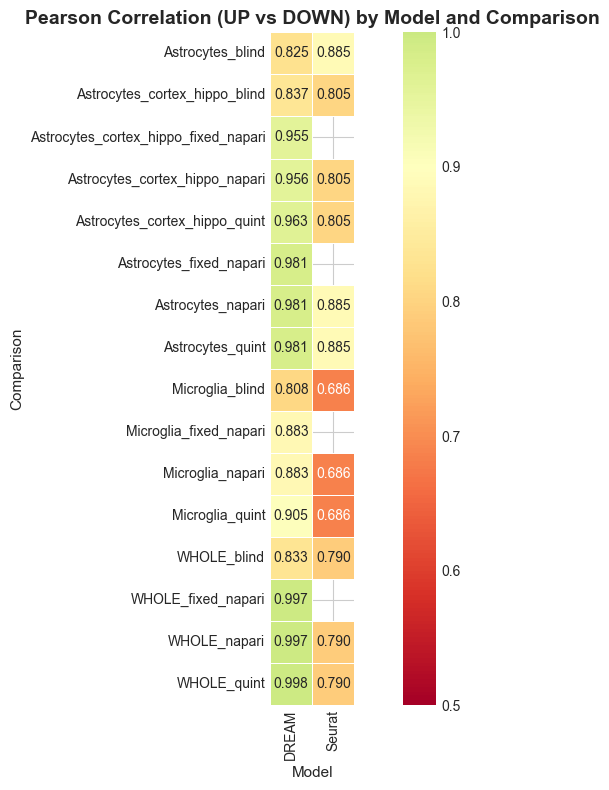

In [ ]:
# Create heatmap of correlations by model and cell type/annotation
pivot_data = []

for model_type in ["dream", "seurat", "pseudobulk"]:
    data = all_data.get(model_type, {})
    if data:
        for name, merged_df in data.items():
            corr_stats = lmm.calculate_correlations(merged_df)
            pivot_data.append({
                'Model': lmm.get_model_display_name(model_type),
                'Comparison': name,
                'Pearson R': corr_stats['pearson_r']
            })

if pivot_data:
    pivot_df = pd.DataFrame(pivot_data)
    pivot_table = pivot_df.pivot(index='Comparison', columns='Model', values='Pearson R')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0.9, vmin=0.5, vmax=1.0,
                linewidths=0.5, square=True)
    plt.title('Pearson Correlation (UP vs DOWN) by Model and Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "figures" / "correlation_heatmap.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / 'correlation_heatmap.png'}")
    plt.show()

In [ ]:
# Bland-Altman summary: Mean bias and limits of agreement
ba_summary = []

for model_type in ["dream", "seurat", "pseudobulk"]:
    data = all_data.get(model_type, {})
    if data:
        for name, merged_df in data.items():
            ba_stats = lmm.bland_altman_stats(merged_df)
            ba_summary.append({
                'Model': lmm.get_model_display_name(model_type),
                'Comparison': name,
                'Mean Bias': ba_stats['mean_diff'],
                'Upper LoA': ba_stats['upper_loa'],
                'Lower LoA': ba_stats['lower_loa'],
                'Width of LoA': ba_stats['upper_loa'] - ba_stats['lower_loa']
            })

if ba_summary:
    ba_df = pd.DataFrame(ba_summary)
    print("=" * 100)
    print("BLAND-ALTMAN SUMMARY: Mean Bias and Limits of Agreement")
    print("=" * 100)
    display(ba_df.round(4))
    
    # Summary by model
    print("\n" + "=" * 60)
    print("SUMMARY BY MODEL")
    print("=" * 60)
    model_ba_summary = ba_df.groupby('Model').agg({
        'Mean Bias': ['mean', 'std'],
        'Width of LoA': ['mean', 'std']
    }).round(4)
    display(model_ba_summary)
    
    ba_df.to_csv(OUTPUT_PATH / "tables" / "bland_altman_summary.csv", index=False)
    print(f"\nSaved: {OUTPUT_PATH / 'tables' / 'bland_altman_summary.csv'}")

BLAND-ALTMAN SUMMARY: Mean Bias and Limits of Agreement


,Model,Comparison,Mean Bias,Upper LoA,Lower LoA,Width of LoA
0,DREAM,Astrocytes_cortex_hippo_fixed_napari,0.0017,0.0377,-0.0343,0.0720
1,DREAM,Astrocytes_cortex_hippo_napari,0.0013,0.0372,-0.0345,0.0717
2,DREAM,Astrocytes_cortex_hippo_quint,0.0005,0.0487,-0.0477,0.0964
3,DREAM,Astrocytes_fixed_napari,0.0002,0.0256,-0.0251,0.0506
4,DREAM,Astrocytes_napari,-0.0000,0.0253,-0.0254,0.0507
5,DREAM,Astrocytes_quint,0.0005,0.0363,-0.0353,0.0716
6,DREAM,Microglia_fixed_napari,-0.0003,0.0884,-0.0890,0.1775
7,DREAM,Microglia_napari,-0.0002,0.0881,-0.0885,0.1765
8,DREAM,Microglia_quint,-0.0061,0.1033,-0.1154,0.2187
9,DREAM,WHOLE_fixed_napari,0.0007,0.0093,-0.0080,0.0173



SUMMARY BY MODEL


Mean Bias         Width of LoA        
            mean     std         mean     std
Model                                        
DREAM    -0.0000  0.0020       0.1131  0.0772
Seurat   -0.0058  0.0173       0.6179  0.1445


Saved: LMM_analysis_data\tables\bland_altman_summary.csv


---
# Part 2: Cross-Annotation Comparison

Compare annotation methods (napari, quint, blind) against each other for the same cell type and model.

This analysis answers: **How consistent are DE results across different annotation methods?**

In [ ]:
# Load cross-annotation comparison data (using UP condition)
annotation_comparisons = lmm.load_all_annotation_comparisons(DATA_PATH, direction="UP")


Loading annotation comparisons (UP condition):

DREAM:
  Astrocytes_cortex_hippo:
    - fixed_napari_vs_napari: 1000 genes
    - fixed_napari_vs_quint: 1000 genes
    - napari_vs_quint: 1000 genes
  Astrocytes:
    - fixed_napari_vs_napari: 996 genes
    - fixed_napari_vs_quint: 1000 genes
    - napari_vs_quint: 996 genes
  Microglia:
    - fixed_napari_vs_napari: 1000 genes
    - fixed_napari_vs_quint: 1000 genes
    - napari_vs_quint: 1000 genes
  WHOLE:
    - fixed_napari_vs_fixed_quint: 1000 genes
    - fixed_napari_vs_napari: 1000 genes
    - fixed_napari_vs_quint: 1000 genes
    - fixed_quint_vs_napari: 1000 genes
    - fixed_quint_vs_quint: 1000 genes
    - napari_vs_quint: 1000 genes

Seurat:
  Astrocytes_cortex_hippo:
    - blind_vs_napari: 1000 genes
    - blind_vs_quint: 1000 genes
    - napari_vs_quint: 1000 genes
  Astrocytes:
    - blind_vs_napari: 1000 genes
    - blind_vs_quint: 1000 genes
    - napari_vs_quint: 1000 genes
  Microglia:
    - blind_vs_napari: 1000 genes

In [ ]:
# Create summary table for annotation comparisons
ann_summary = lmm.create_annotation_summary_table(annotation_comparisons)

print("=" * 100)
print("CROSS-ANNOTATION COMPARISON SUMMARY")
print("=" * 100)
display(ann_summary.round(4))

# Save to CSV
ann_summary.to_csv(OUTPUT_PATH / "tables" / "annotation_comparison_summary.csv", index=False)
print(f"\nSaved: {OUTPUT_PATH / 'tables' / 'annotation_comparison_summary.csv'}")

CROSS-ANNOTATION COMPARISON SUMMARY


,Model,Cell Type,Comparison,N Genes,Pearson R,Spearman R,Concordance %,Mean Bias,Lower LoA,Upper LoA
0,DREAM,Astrocytes_cortex_hippo,fixed_napari_vs_napari,1000,0.9996,0.9975,97.6000,0.0001,-0.0031,0.0033
1,DREAM,Astrocytes_cortex_hippo,fixed_napari_vs_quint,1000,0.8961,0.8691,86.4000,0.0061,-0.0789,0.0911
2,DREAM,Astrocytes_cortex_hippo,napari_vs_quint,1000,0.8967,0.8723,86.8000,0.0060,-0.0789,0.0909
3,DREAM,Astrocytes,fixed_napari_vs_napari,996,0.9999,0.9992,99.2972,0.0001,-0.0018,0.0020
4,DREAM,Astrocytes,fixed_napari_vs_quint,1000,0.9044,0.8939,87.7000,0.0105,-0.0738,0.0948
5,DREAM,Astrocytes,napari_vs_quint,996,0.9043,0.8942,87.7510,0.0105,-0.0740,0.0949
6,DREAM,Microglia,fixed_napari_vs_napari,1000,0.9985,0.9943,96.5000,-0.0003,-0.0106,0.0100
7,DREAM,Microglia,fixed_napari_vs_quint,1000,0.8989,0.8349,81.8000,0.0105,-0.1063,0.1274
8,DREAM,Microglia,napari_vs_quint,1000,0.9004,0.8427,82.5000,0.0108,-0.1056,0.1272
9,DREAM,WHOLE,fixed_napari_vs_fixed_quint,1000,0.9543,0.9506,89.7000,0.0060,-0.0619,0.0738



Saved: LMM_analysis_data\tables\annotation_comparison_summary.csv


## Section H: Cross-Annotation Scatter Plots

Compare logFC values between annotation methods for each cell type and model.

Saved: LMM_analysis_data\figures\annotation_scatter_{model}.png


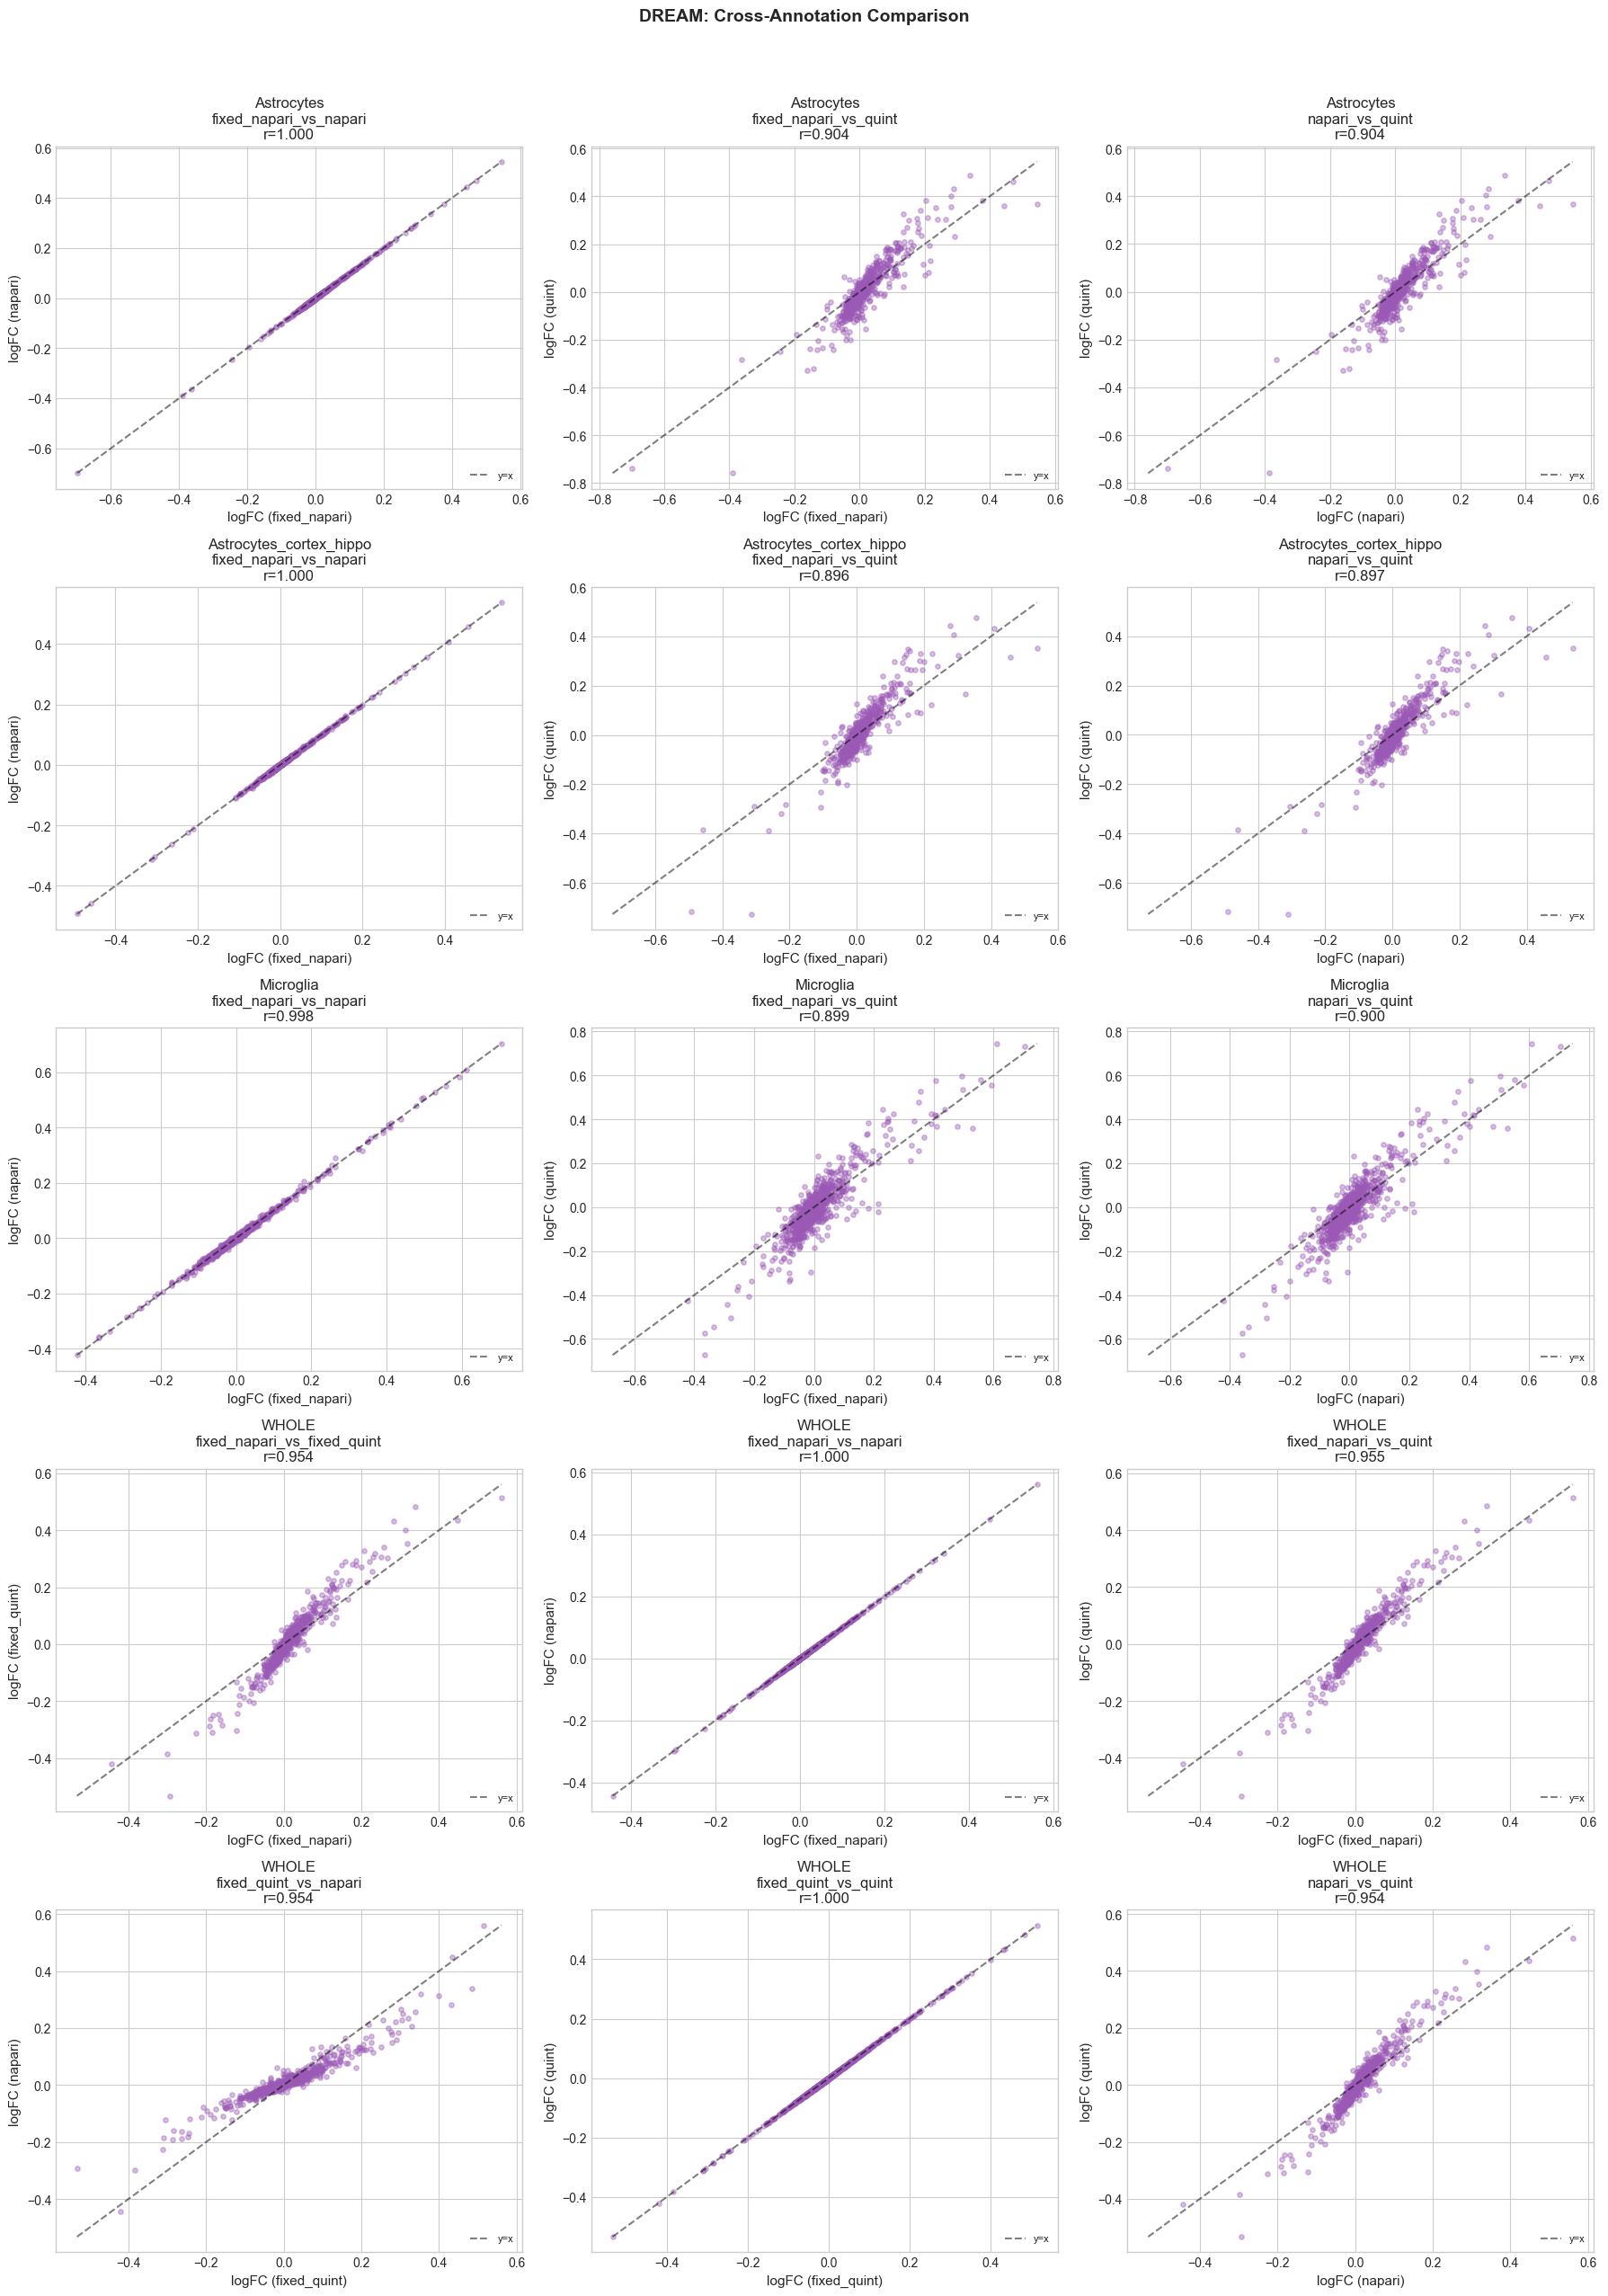

Saved: LMM_analysis_data\figures\annotation_scatter_{model}.png


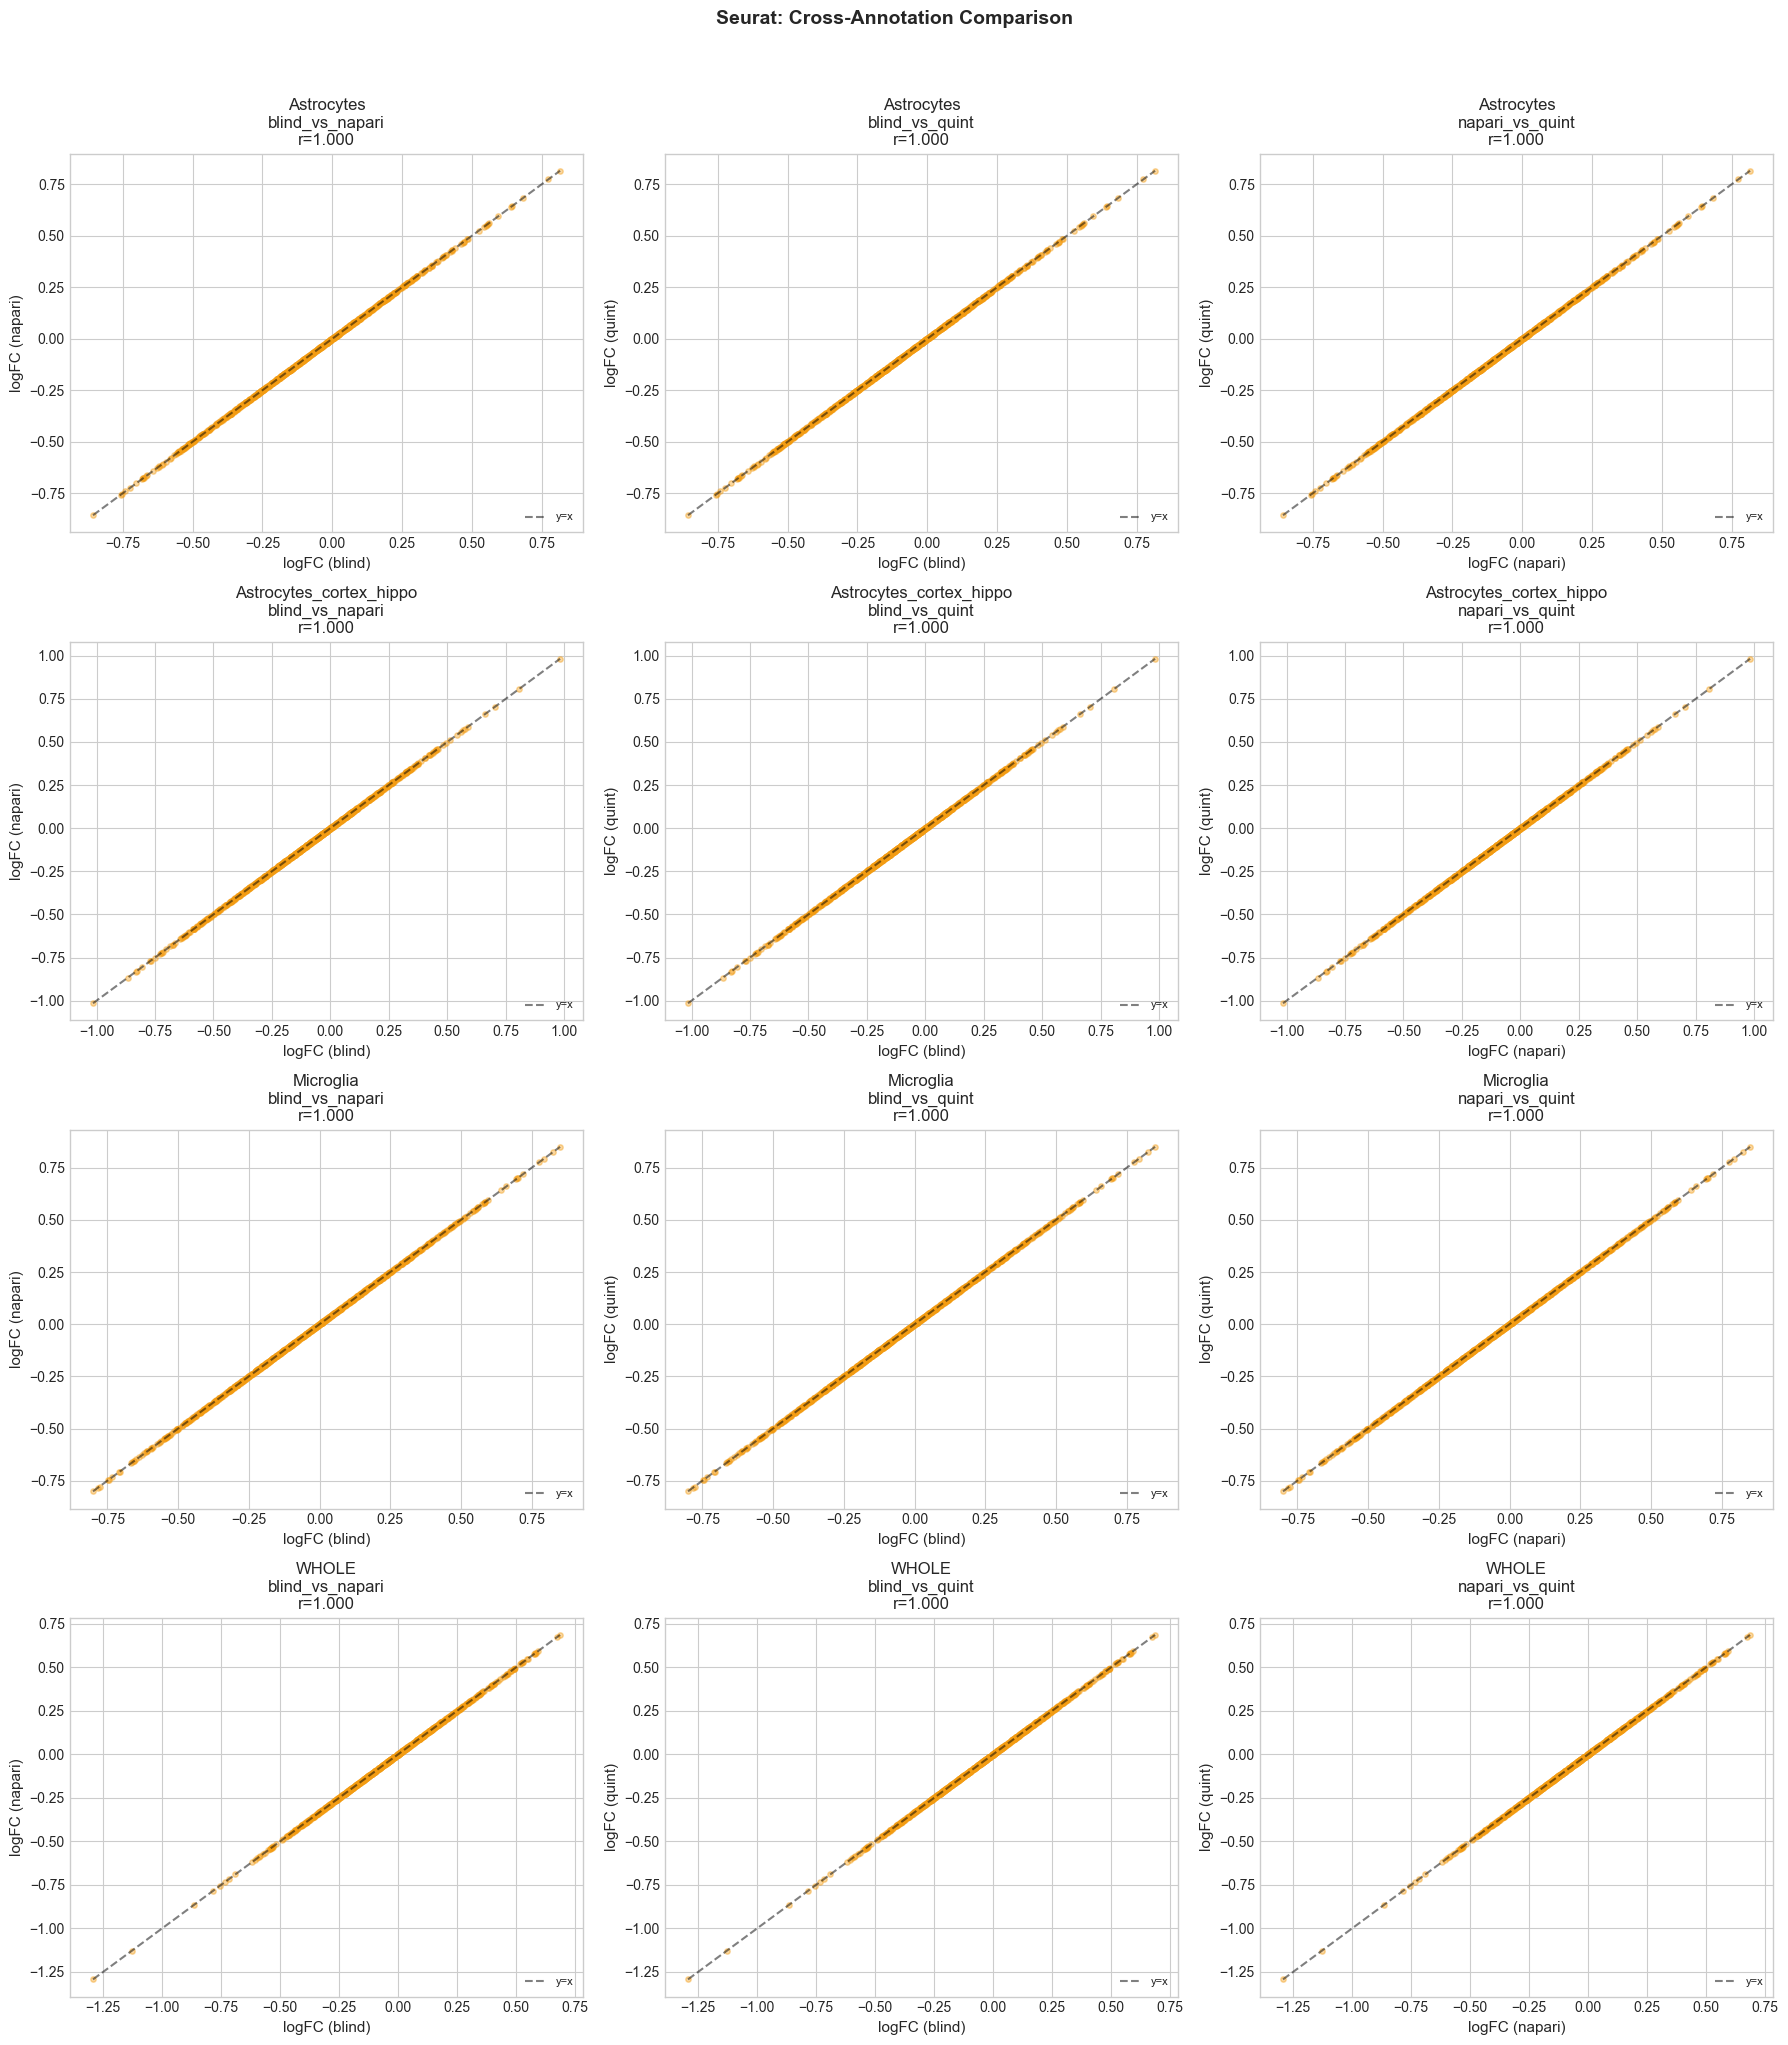

In [ ]:
# Cross-Annotation Scatter Plots
for model, model_data in annotation_comparisons.items():
    if not model_data:
        continue
    
    # Count total plots needed
    total_plots = sum(len(pairs) for pairs in model_data.values())
    if total_plots == 0:
        continue
    
    n_cols = min(3, total_plots)
    n_rows = (total_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if total_plots == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()
    
    plot_idx = 0
    for cell_type, pairs in sorted(model_data.items()):
        for pair_name, merged_df in sorted(pairs.items()):
            ax = axes[plot_idx]
            
            # Parse annotations from pair name
            ann1, ann2 = pair_name.split("_vs_")
            col1, col2 = f"logFC_{ann1}", f"logFC_{ann2}"
            
            # Calculate correlation
            corr = lmm.calculate_annotation_correlation(merged_df, ann1, ann2)
            
            # Scatter plot
            ax.scatter(merged_df[col1], merged_df[col2], 
                      alpha=0.4, s=15, color=MODEL_COLORS[model])
            
            # Identity line
            lims = [min(merged_df[col1].min(), merged_df[col2].min()),
                   max(merged_df[col1].max(), merged_df[col2].max())]
            ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
            
            ax.set_xlabel(f'logFC ({ann1})')
            ax.set_ylabel(f'logFC ({ann2})')
            ax.set_title(f'{cell_type}\n{pair_name}\nr={corr["pearson_r"]:.3f}')
            ax.legend(loc='lower right', fontsize=8)
            
            plot_idx += 1
    
    # Hide empty subplots
    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'{lmm.get_model_display_name(model)}: Cross-Annotation Comparison', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / "figures" / f"annotation_scatter_{model}.png", dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_PATH / 'figures' / 'annotation_scatter_{model}.png'}")
    plt.show()

---
## Summary

This analysis compared UP vs DOWN conditions across three model types:
- **DREAM** - Mixed linear model approach for repeated measures
- **Seurat** - Standard single-cell differential expression
- **Pseudobulk (DESeq2)** - Aggregated pseudobulk analysis

### Key Metrics Compared:
1. **Bland-Altman Plots** (prioritized) - Systematic bias and limits of agreement
2. **Scatter Plots** - logFC UP vs DOWN with identity line
3. **Pearson and Spearman correlations** - Agreement of logFC values
4. **Directional concordance** - Proportion of genes with matching direction of effect
5. **Overlap of significant genes** - Jaccard index of significant gene sets

### Output Files:
- `figures/` - Bland-Altman plots, scatter plots, summary visualizations
- `tables/` - Summary statistics for each model and combined results